# Analyse complète — Galatasaray vs Liverpool & Multi-Match


Ce notebook unifié rassemble

1. **Partie Analyse des données** — Galatasaray vs Liverpool (enriched + V2) et analyse multi-match multi-plateforme
2. **Partie Sentiment Analysis avancée** — Pipeline RoBERTa + Classifieur d'événements
3. **Partie TAL (NLP)** — Parties 1, 2 et 3 : règles lexicales, TF-IDF, classification, sentiment
4. **Conclusion générale**



# PARTIE 1 — ANALYSE DES DONNÉES

## 1 Galatasaray vs Liverpool — Analyse enrichie

In [586]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [587]:
from pathlib import Path
import json
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook")


PROJECT_DIR = Path("/content/drive/MyDrive/Project_Master")
DATA_DIR = PROJECT_DIR / "data"
TAL_DIR = PROJECT_DIR / "external" / "projet_tal"
OUTPUT_DIR = PROJECT_DIR / "outputs_enriched"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

print("Dossier du projet :", PROJECT_DIR)
print("Dossier des sorties :", OUTPUT_DIR)

Dossier du projet : /content/drive/MyDrive/Project_Master
Dossier des sorties : /content/drive/MyDrive/Project_Master/outputs_enriched


### 1.2 Chargement des données




In [588]:
def read_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


match_info = read_json(DATA_DIR / "matches.json")[0]
reddit_raw = read_json(DATA_DIR / "period_debug_galata_liverpool_20260310_1779694004.json")
news_raw = read_json(DATA_DIR / "news_galata_liverpool_20260310_ALL.json")

tal_path = TAL_DIR / "resultats_tal_galata_liverpool.csv"
tal_df = pd.read_csv(tal_path) if tal_path.exists() else pd.DataFrame()

match_name = match_info["name"]
match_date = pd.to_datetime(match_info["date"], utc=True)
kickoff = pd.to_datetime(match_info["reddit_time_windows"]["match_start_utc"], utc=True)
period_order = match_info["reddit_time_windows"]["periods"]
period_minutes = {p: int(p.split(":")[0]) for p in period_order}

print("Match :", match_name)
print("Compétition :", match_info["competition"])
print("Date :", match_info["date"])
print("Commentaires Reddit dans les fenêtres :", len(reddit_raw["matched_comments"]))
print("Articles news :", len(news_raw))
print("Lignes TAL :", len(tal_df))


Match : Galatasaray vs Liverpool
Compétition : Champions League Round of 16
Date : 2026-03-10
Commentaires Reddit dans les fenêtres : 1228
Articles news : 100
Lignes TAL : 90


### 1.3. Nettoyage et transformation


In [589]:
def clean_html(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"&nbsp;|&amp;|&quot;|&#39;", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def clean_text(text):
    text = clean_html(text)
    text = re.sub(r"https?://\S+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def parse_period_match(value):
    # Exemple : "90:00 (after: 1171s)"
    if not isinstance(value, str):
        return None
    match = re.match(r"(?P<period>\d{2}:\d{2})\s+\((?P<side>before|after):\s+(?P<seconds>\d+)s\)", value)
    if not match:
        return None
    sign = -1 if match.group("side") == "before" else 1
    seconds = sign * int(match.group("seconds"))
    period = match.group("period")
    minute = period_minutes.get(period, 0) + seconds / 60
    return {
        "period": period,
        "offset_seconds": seconds,
        "abs_offset_seconds": abs(seconds),
        "minute_context": minute,
    }


comment_rows = []
period_rows = []
for item in reddit_raw["matched_comments"]:
    parsed_periods = [parse_period_match(x) for x in item.get("period_matches", [])]
    parsed_periods = [x for x in parsed_periods if x]
    if parsed_periods:
        primary = sorted(parsed_periods, key=lambda x: x["abs_offset_seconds"])[0]
    else:
        primary = {"period": None, "offset_seconds": np.nan, "abs_offset_seconds": np.nan, "minute_context": np.nan}

    body = clean_text(item.get("body", ""))
    row = {
        "comment_id": item.get("comment_id"),
        "author": item.get("author"),
        "post_title": clean_text(item.get("post_title", "")),
        "body": body,
        "score": item.get("score", 0),
        "created_at": pd.to_datetime(item.get("created_time"), utc=True, errors="coerce"),
        "primary_period": primary["period"],
        "primary_offset_seconds": primary["offset_seconds"],
        "minute_context": primary["minute_context"],
        "text": clean_text(item.get("post_title", "") + " " + body),
    }
    comment_rows.append(row)

    for parsed in parsed_periods:
        period_rows.append({
            "comment_id": item.get("comment_id"),
            "period": parsed["period"],
            "period_minute": period_minutes.get(parsed["period"], np.nan),
            "offset_seconds": parsed["offset_seconds"],
            "minute_context": parsed["minute_context"],
            "body": body,
            "text": row["text"],
            "score": row["score"],
        })

reddit_df = pd.DataFrame(comment_rows)
reddit_period_df = pd.DataFrame(period_rows)


def useful_news_text(row):
    parts = [
        row.get("title", ""),
        row.get("description", ""),
        row.get("content", ""),
    ]
    text = clean_text(" ".join(str(x) for x in parts if pd.notna(x)))
    bad_markers = ["cookie", "javascript", "google news", "enable js", "consent"]
    if sum(marker in text.lower() for marker in bad_markers) >= 2:
        text = clean_text(str(row.get("title", "")) + " " + str(row.get("description", "")))
    return text


news_df = pd.DataFrame(news_raw)
news_df["published_at"] = pd.to_datetime(news_df["published_date"], utc=True, errors="coerce")
news_df["published_day"] = news_df["published_at"].dt.date
news_df["days_from_match"] = (news_df["published_at"] - match_date).dt.days
news_df["text"] = news_df.apply(useful_news_text, axis=1)
news_df["publisher"] = news_df["publisher"].fillna("inconnu")

print("Table Reddit :", reddit_df.shape)
print("Table Reddit par période :", reddit_period_df.shape)
print("Table News :", news_df.shape)
display(reddit_df.head(3))
display(news_df[["title", "publisher", "published_at", "days_from_match"]].head(3))


Table Reddit : (1228, 10)
Table Reddit par période : (1994, 8)
Table News : (100, 19)


,comment_id,author,post_title,body,score,created_at,primary_period,primary_offset_seconds,minute_context,text
0,o9qu65f,L0st_MySocks,Post Match Thread: Galatasaray 1-0 Liverpool,The first half was like damn Gala played like they were a team from PL as well what a run! the second half was like ...,-35,2026-03-10 21:49:31+00:00,90:00,1171,109.516667,Post Match Thread: Galatasaray 1-0 Liverpool The first half was like damn Gala played like they were a team from PL ...
1,o9qlhgd,ritwikjs2,Post Match Thread: Galatasaray 1-0 Liverpool,"Should've been 2-0, that offside decision was very generous",91,2026-03-10 21:07:36+00:00,75:00,-444,67.600000,"Post Match Thread: Galatasaray 1-0 Liverpool Should've been 2-0, that offside decision was very generous"
2,o9qlgqu,nahnonameman,Post Match Thread: Galatasaray 1-0 Liverpool,Liverpool dodging criticism after what is happening to Spurs currently,66,2026-03-10 21:07:30+00:00,60:00,450,67.500000,Post Match Thread: Galatasaray 1-0 Liverpool Liverpool dodging criticism after what is happening to Spurs currently


,title,publisher,published_at,days_from_match
0,Officials and Liverpool’s wastefulness concern Arne Slot in loss to Galatasaray - MSN,MSN,2026-05-25 00:56:34+00:00,76.0
1,"Liverpool 4-0 Galatasaray (Mar 18, 2026) Final Score - ESPN",ESPN,2026-02-27 12:38:14+00:00,-11.0
2,"💣 Galatasaray shock Liverpool, Lemina scores, Osimhen in tears 😭 - Yahoo Sports",Yahoo Sports,2026-03-10 07:00:00+00:00,0.0


### 1.4. Qualité des données

In [590]:
quality_rows = []
quality_rows.append({
    "point": "Commentaires Reddit collectés",
    "valeur": len(reddit_df),
    "note": "Commentaires présents dans au moins une fenêtre temporelle."
})
quality_rows.append({
    "point": "Commentaires par période",
    "valeur": len(reddit_period_df),
    "note": "Un commentaire peut compter dans plusieurs fenêtres."
})
quality_rows.append({
    "point": "Articles de presse",
    "valeur": len(news_df),
    "note": "Articles récupérés par Google News et autres sources."
})
quality_rows.append({
    "point": "Posts avec 'Post Match'",
    "valeur": int(reddit_df["post_title"].str.contains("post match", case=False, na=False).sum()),
    "note": "Ces posts peuvent créer un pic très fort et doivent être interprétés avec prudence."
})

quality_df = pd.DataFrame(quality_rows)
quality_df.to_csv(OUTPUT_DIR / "data_quality_notes.csv", index=False)
display(quality_df)


,point,valeur,note
0,Commentaires Reddit collectés,1228,Commentaires présents dans au moins une fenêtre temporelle.
1,Commentaires par période,1994,Un commentaire peut compter dans plusieurs fenêtres.
2,Articles de presse,100,Articles récupérés par Google News et autres sources.
3,Posts avec 'Post Match',599,Ces posts peuvent créer un pic très fort et doivent être interprétés avec prudence.


### 1.5 Timeline Reddit et médias




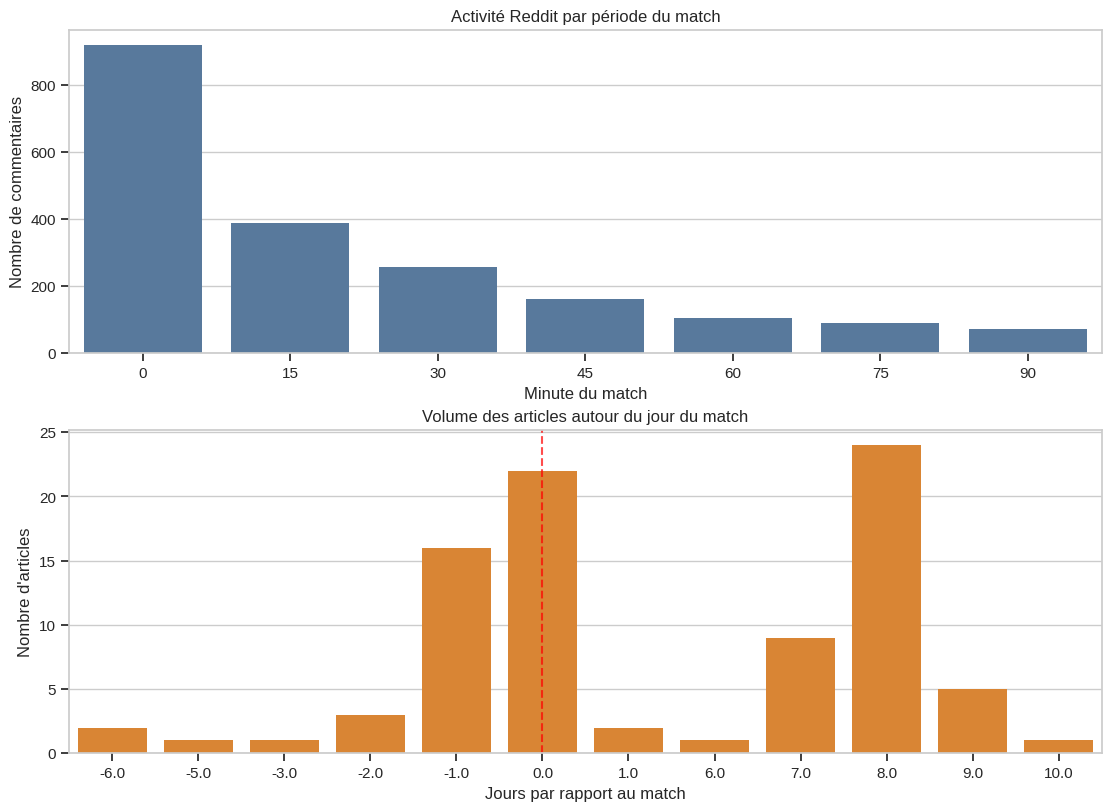

,period,commentaires,minute
0,00:00,920,0
1,15:00,388,15
2,30:00,257,30
3,45:00,162,45
4,60:00,106,60
5,75:00,90,75
6,90:00,71,90


,days_from_match,articles
0,-164.0,1
1,-162.0,1
2,-161.0,2
3,-91.0,2
4,-11.0,3
5,-6.0,2
6,-5.0,1
7,-3.0,1
8,-2.0,3
9,-1.0,16


In [591]:
period_counts = (
    reddit_period_df.groupby("period")
    .size()
    .reindex(period_order, fill_value=0)
    .rename("commentaires")
    .reset_index()
)
period_counts["minute"] = period_counts["period"].map(period_minutes)

news_day_counts = (
    news_df.dropna(subset=["published_at"])
    .groupby("days_from_match")
    .size()
    .rename("articles")
    .reset_index()
    .sort_values("days_from_match")
)

fig, axes = plt.subplots(2, 1, figsize=(11, 8), constrained_layout=True)

sns.barplot(data=period_counts, x="minute", y="commentaires", color="#4C78A8", ax=axes[0])
axes[0].set_title("Activité Reddit par période du match")
axes[0].set_xlabel("Minute du match")
axes[0].set_ylabel("Nombre de commentaires")

plot_news = news_day_counts[(news_day_counts["days_from_match"] >= -10) & (news_day_counts["days_from_match"] <= 15)]
sns.barplot(data=plot_news, x="days_from_match", y="articles", color="#F58518", ax=axes[1])
axes[1].axvline(x=list(plot_news["days_from_match"]).index(0) if 0 in set(plot_news["days_from_match"]) else 0, color="red", linestyle="--", alpha=0.7)
axes[1].set_title("Volume des articles autour du jour du match")
axes[1].set_xlabel("Jours par rapport au match")
axes[1].set_ylabel("Nombre d'articles")

fig.savefig(OUTPUT_DIR / "timeline_reddit_news.png", dpi=160, bbox_inches="tight")
plt.show()

period_counts.to_csv(OUTPUT_DIR / "reddit_period_timeline.csv", index=False)
news_day_counts.to_csv(OUTPUT_DIR / "news_day_timeline.csv", index=False)
display(period_counts)
display(news_day_counts.head(15))


### 1.6. Mots-clés d'événements par période


/tmp/ipykernel_1492/1638756921.py:14: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  count = subset["text"].str.contains(pattern, case=False, regex=True, na=False).sum()


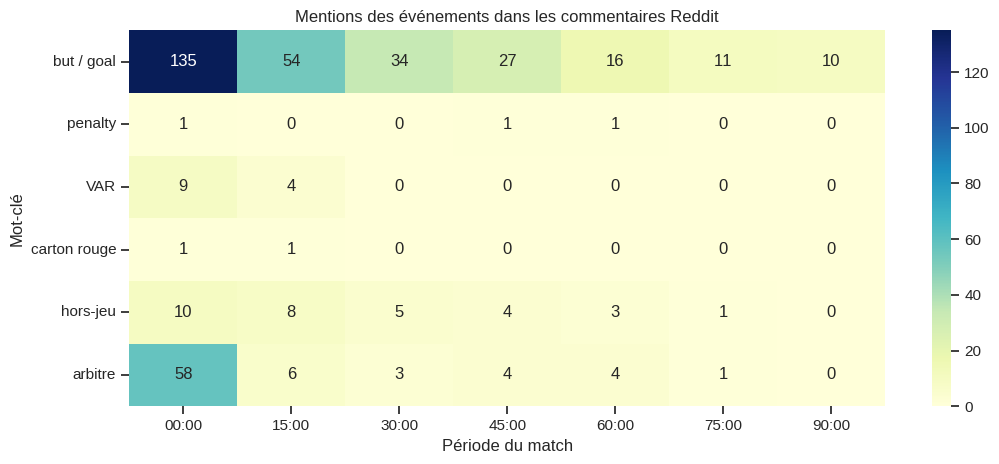

period,00:00,15:00,30:00,45:00,60:00,75:00,90:00
mot_cle,,,,,,,
but / goal,135,54,34,27,16,11,10
penalty,1,0,0,1,1,0,0
VAR,9,4,0,0,0,0,0
carton rouge,1,1,0,0,0,0,0
hors-jeu,10,8,5,4,3,1,0
arbitre,58,6,3,4,4,1,0


In [592]:
event_patterns = {
    "but / goal": r"\b(goal|goals|but|score|scored|scores)\b",
    "penalty": r"\b(penalty|penalties|penalti)\b",
    "VAR": r"\bvar\b",
    "carton rouge": r"\b(red card|carton rouge|rouge)\b",
    "hors-jeu": r"\b(offside|hors[- ]?jeu)\b",
    "arbitre": r"\b(ref|referee|arbitre|refs)\b",
}

event_rows = []
for period in period_order:
    subset = reddit_period_df[reddit_period_df["period"] == period]
    for label, pattern in event_patterns.items():
        count = subset["text"].str.contains(pattern, case=False, regex=True, na=False).sum()
        event_rows.append({"period": period, "minute": period_minutes[period], "mot_cle": label, "mentions": int(count)})

event_period_df = pd.DataFrame(event_rows)
event_matrix = event_period_df.pivot(index="mot_cle", columns="period", values="mentions").reindex(list(event_patterns.keys()))

plt.figure(figsize=(11, 4.8))
sns.heatmap(event_matrix, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Mentions des événements dans les commentaires Reddit")
plt.xlabel("Période du match")
plt.ylabel("Mot-clé")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "event_terms_by_period.png", dpi=160, bbox_inches="tight")
plt.show()

event_period_df.to_csv(OUTPUT_DIR / "event_terms_by_period.csv", index=False)
display(event_matrix)


### 1.7. Langues détectées



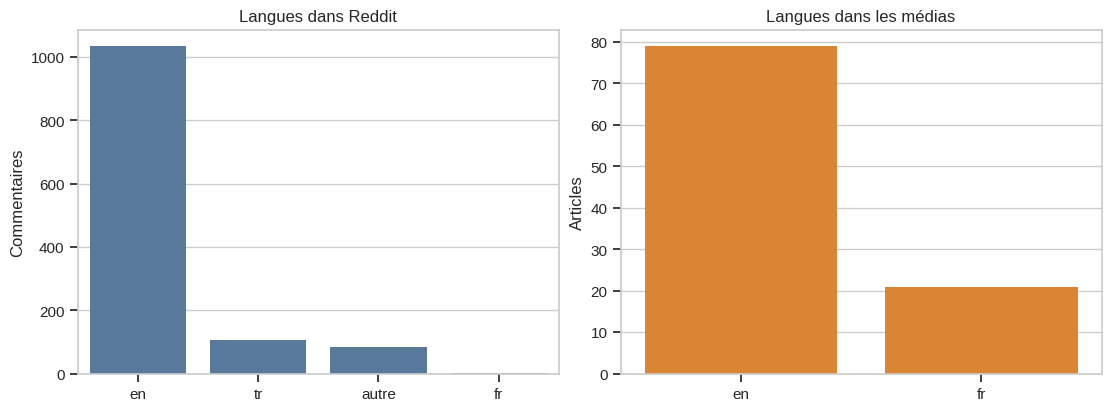

,langue,commentaires
0,en,1035
1,tr,106
2,autre,85
3,fr,2


,langue,articles
0,en,79
1,fr,21


In [593]:
LANG_MARKERS = {
    "fr": {
        "le", "la", "les", "des", "une", "avec", "pour", "mais", "très", "tres", "pas",
        "est", "sont", "joueur", "équipe", "equipe", "arbitre",
    },
    "en": {
        "the", "and", "but", "with", "from", "this", "that", "they", "was", "were",
        "match", "goal", "team", "player", "ref", "offside", "liverpool",
    },
    "tr": {
        "ve", "bir", "bu", "ama", "için", "icin", "değil", "degil", "galatasaray", "hakem",
    },
    "es_pt": {
        "el", "los", "las", "que", "con", "para", "pero", "não", "nao", "jogo", "equipo", "partido",
    },
}


def detect_language_simple(text):
    if not isinstance(text, str) or len(text.strip()) < 8:
        return "inconnu"
    sample = text.lower()
    tokens = re.findall(r"[a-zA-ZÀ-ÿğüşöçıİ]+", sample)
    scores = {}
    for lang, markers in LANG_MARKERS.items():
        scores[lang] = sum(token in markers for token in tokens)
    if re.search(r"[ğüşöçıİ]", text):
        scores["tr"] += 3
    if re.search(r"[éèêàçùôî]", text.lower()):
        scores["fr"] += 2
    if re.search(r"[ñáíóúãõ]", text.lower()):
        scores["es_pt"] += 2
    best_lang, best_score = max(scores.items(), key=lambda x: x[1])
    if best_score == 0:
        return "autre"
    return best_lang


reddit_df["langue"] = reddit_df["text"].apply(detect_language_simple)
news_df["langue"] = news_df["text"].apply(detect_language_simple)

reddit_lang_counts = reddit_df["langue"].value_counts().rename_axis("langue").reset_index(name="commentaires")
news_lang_counts = news_df["langue"].value_counts().rename_axis("langue").reset_index(name="articles")

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
sns.barplot(data=reddit_lang_counts, x="langue", y="commentaires", color="#4C78A8", ax=axes[0])
axes[0].set_title("Langues dans Reddit")
axes[0].set_xlabel("")
axes[0].set_ylabel("Commentaires")
sns.barplot(data=news_lang_counts, x="langue", y="articles", color="#F58518", ax=axes[1])
axes[1].set_title("Langues dans les médias")
axes[1].set_xlabel("")
axes[1].set_ylabel("Articles")
fig.savefig(OUTPUT_DIR / "language_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

reddit_lang_counts.to_csv(OUTPUT_DIR / "reddit_language_counts.csv", index=False)
news_lang_counts.to_csv(OUTPUT_DIR / "news_language_counts.csv", index=False)
display(reddit_lang_counts)
display(news_lang_counts)


### 1.8. Sentiment simple par langue

On calcule un sentiment simple avec un lexique.  
Ce n'est pas aussi précis que RoBERTa.


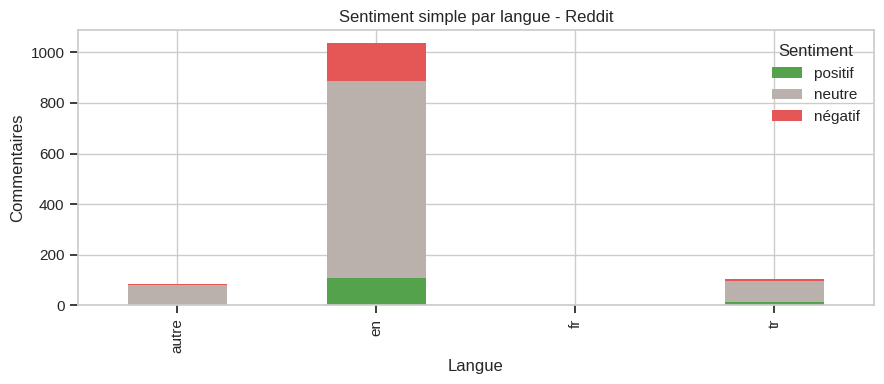

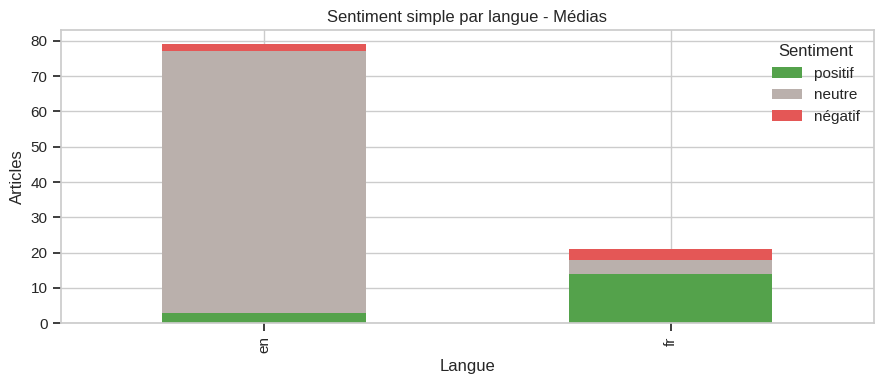

sentiment,positif,neutre,négatif
langue,,,
autre,3.0,77.0,5.0
en,110.0,778.0,147.0
fr,0.0,2.0,0.0
tr,13.0,84.0,9.0


sentiment,positif,neutre,négatif
langue,,,
en,3,74,2
fr,14,4,3


In [594]:
positive_words = {
    "good", "great", "best", "win", "won", "happy", "love", "amazing", "strong", "brilliant", "masterclass",
    "bien", "bon", "bonne", "gagner", "gagné", "fort", "meilleur", "magnifique", "incroyable",
    "iyi", "harika", "kazandı", "güzel",
}
negative_words = {
    "bad", "poor", "lost", "lose", "awful", "terrible", "hate", "waste", "wasteful", "pressure", "robbed",
    "shit", "worst", "concern", "difficult",
    "mauvais", "perdu", "nul", "difficile", "problème", "faible",
    "kötü", "kaybetti", "zor",
}


def sentiment_simple(text):
    tokens = re.findall(r"[a-zA-ZÀ-ÿğüşöçıİ]+", str(text).lower())
    pos = sum(token in positive_words for token in tokens)
    neg = sum(token in negative_words for token in tokens)
    score = pos - neg
    if score > 0:
        return "positif"
    if score < 0:
        return "négatif"
    return "neutre"


reddit_df["sentiment"] = reddit_df["text"].apply(sentiment_simple)
news_df["sentiment"] = news_df["text"].apply(sentiment_simple)

reddit_sent_lang = (
    reddit_df.groupby(["langue", "sentiment"]).size()
    .rename("nombre")
    .reset_index()
)
news_sent_lang = (
    news_df.groupby(["langue", "sentiment"]).size()
    .rename("nombre")
    .reset_index()
)

def plot_stacked_sentiment(df, value_label, title, path):
    table = df.pivot(index="langue", columns="sentiment", values="nombre").fillna(0)
    table = table.reindex(columns=["positif", "neutre", "négatif"], fill_value=0)
    ax = table.plot(kind="bar", stacked=True, figsize=(9, 4), color=["#54A24B", "#BAB0AC", "#E45756"])
    ax.set_title(title)
    ax.set_xlabel("Langue")
    ax.set_ylabel(value_label)
    ax.legend(title="Sentiment")
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    return table

reddit_sent_table = plot_stacked_sentiment(
    reddit_sent_lang,
    "Commentaires",
    "Sentiment simple par langue - Reddit",
    OUTPUT_DIR / "reddit_sentiment_by_language.png",
)
news_sent_table = plot_stacked_sentiment(
    news_sent_lang,
    "Articles",
    "Sentiment simple par langue - Médias",
    OUTPUT_DIR / "news_sentiment_by_language.png",
)

reddit_sent_lang.to_csv(OUTPUT_DIR / "reddit_sentiment_by_language.csv", index=False)
news_sent_lang.to_csv(OUTPUT_DIR / "news_sentiment_by_language.csv", index=False)
display(reddit_sent_table)
display(news_sent_table)


### 1.9. Comparaison des entités : équipes, joueurs et entraîneurs




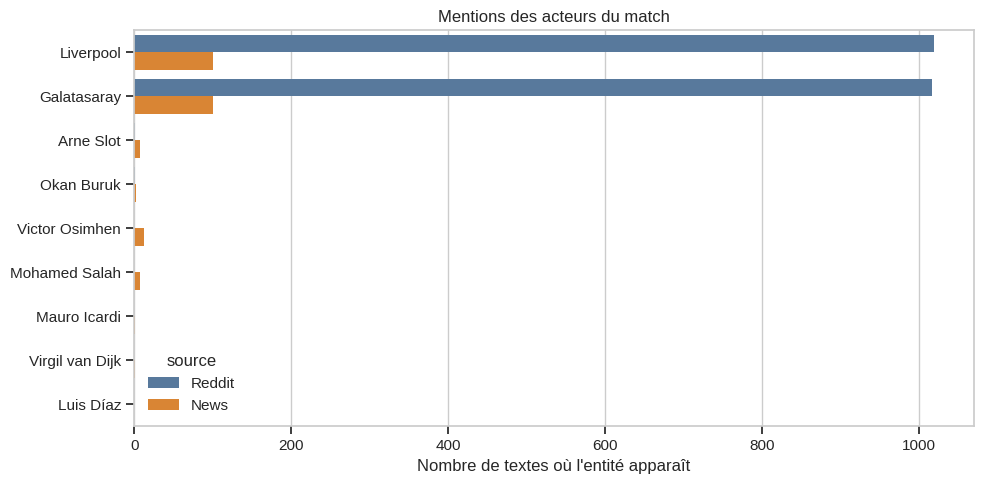

,entite,Reddit,News
4,Liverpool,1019,100
0,Galatasaray,1017,100
5,Arne Slot,1,8
1,Okan Buruk,1,2
3,Victor Osimhen,0,13
6,Mohamed Salah,0,7
2,Mauro Icardi,0,1
7,Virgil van Dijk,0,1
8,Luis Díaz,0,0


In [595]:
entities = []
for side in ["home", "away"]:
    team = match_info["teams_players"][side]
    entities.append(team["name"])
    entities.append(team["trainer"])
    entities.extend(team.get("key_players", []))

entities = list(dict.fromkeys(entities))


def count_entity_mentions(texts, entity):
    pattern = re.compile(r"\b" + re.escape(entity.lower()) + r"\b")
    return int(sum(bool(pattern.search(str(text).lower())) for text in texts))


entity_rows = []
for entity in entities:
    entity_rows.append({
        "entite": entity,
        "Reddit": count_entity_mentions(reddit_df["text"], entity),
        "News": count_entity_mentions(news_df["text"], entity),
    })

entity_df = pd.DataFrame(entity_rows).sort_values(["Reddit", "News"], ascending=False)
entity_long = entity_df.melt(id_vars="entite", var_name="source", value_name="mentions")

plt.figure(figsize=(10, 5))
sns.barplot(data=entity_long, y="entite", x="mentions", hue="source", palette=["#4C78A8", "#F58518"])
plt.title("Mentions des acteurs du match")
plt.xlabel("Nombre de textes où l'entité apparaît")
plt.ylabel("")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "entity_platform_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

entity_df.to_csv(OUTPUT_DIR / "entity_platform_comparison.csv", index=False)
display(entity_df)


### 1.10. Apport de la partie TAL



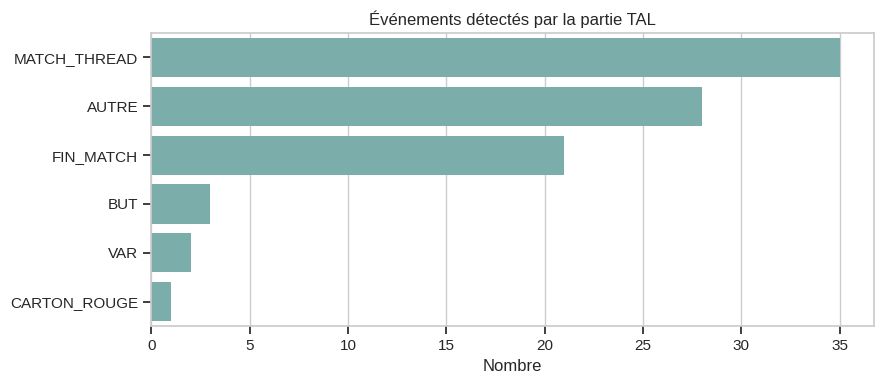

,evenement,nombre
0,MATCH_THREAD,35
1,AUTRE,28
2,FIN_MATCH,21
3,BUT,3
4,VAR,2
5,CARTON_ROUGE,1


In [596]:
if not tal_df.empty and "evenement" in tal_df.columns:
    tal_counts = (
        tal_df["evenement"].fillna("INCONNU")
        .value_counts()
        .rename_axis("evenement")
        .reset_index(name="nombre")
    )

    plt.figure(figsize=(9, 4))
    sns.barplot(data=tal_counts, x="nombre", y="evenement", color="#72B7B2")
    plt.title("Événements détectés par la partie TAL")
    plt.xlabel("Nombre")
    plt.ylabel("")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "tal_event_types.png", dpi=160, bbox_inches="tight")
    plt.show()

    tal_counts.to_csv(OUTPUT_DIR / "tal_event_types.csv", index=False)
    display(tal_counts)
else:
    print("Aucun fichier TAL disponible.")


### 1.12. Synthèse automatique pour le rapport


In [597]:
reddit_peak = period_counts.sort_values("commentaires", ascending=False).iloc[0]
news_peak = news_day_counts.sort_values("articles", ascending=False).iloc[0]
main_reddit_lang = reddit_lang_counts.iloc[0]
main_news_lang = news_lang_counts.iloc[0]

summary_rows = [
    {
        "question": "Quand Reddit réagit le plus ?",
        "réponse": f"La période la plus active est autour de {reddit_peak['period']} avec {int(reddit_peak['commentaires'])} commentaires comptés.",
    },
    {
        "question": "Quand les médias publient le plus ?",
        "réponse": f"Le plus grand volume d'articles est à J{int(news_peak['days_from_match']):+d}, avec {int(news_peak['articles'])} articles.",
    },
    {
        "question": "Quelle langue domine Reddit ?",
        "réponse": f"La langue dominante détectée dans Reddit est {main_reddit_lang['langue']} avec {int(main_reddit_lang['commentaires'])} commentaires.",
    },
    {
        "question": "Quelle langue domine les médias ?",
        "réponse": f"La langue dominante détectée dans les médias est {main_news_lang['langue']} avec {int(main_news_lang['articles'])} articles.",
    },
    {
        "question": "Point important de méthode",
        "réponse": "Les données Reddit montrent des réactions rapides, mais certains posts ont des dates ou titres qui demandent une vérification manuelle.",
    },
]

report_summary_df = pd.DataFrame(summary_rows)
report_summary_df.to_csv(OUTPUT_DIR / "report_summary_sentences.csv", index=False)
display(report_summary_df)


,question,réponse
0,Quand Reddit réagit le plus ?,La période la plus active est autour de 00:00 avec 920 commentaires comptés.
1,Quand les médias publient le plus ?,"Le plus grand volume d'articles est à J+8, avec 24 articles."
2,Quelle langue domine Reddit ?,La langue dominante détectée dans Reddit est en avec 1035 commentaires.
3,Quelle langue domine les médias ?,La langue dominante détectée dans les médias est en avec 79 articles.
4,Point important de méthode,"Les données Reddit montrent des réactions rapides, mais certains posts ont des dates ou titres qui demandent une vér..."


### 1.13. Conclusion

Cette analyse enrichit le projet de trois manières.

Premièrement, elle ne montre pas seulement le volume des messages. Elle relie les messages aux périodes du match et aux mots-clés d'événements.

Deuxièmement, elle compare deux types de sources : les réseaux sociaux et les médias. Reddit donne une réaction plus immédiate, alors que les médias donnent une information plus organisée.

Troisièmement, elle ajoute une première comparaison par langue. Cette partie est importante pour le sujet initial, car le projet cherche à comprendre si les perceptions changent selon les communautés linguistiques.

### Limites à expliquer

- La détection de langue est simple et peut faire des erreurs.
- Le sentiment est basé sur un lexique, donc il ne comprend pas toujours l'ironie.
- Les données Twitter/X ne sont pas encore complètes.
- Certains posts Reddit semblent mal alignés dans le temps, donc il faut rester prudent.

### Prochaine amélioration possible

On peut remplacer le sentiment simple par le notebook avancé avec Twitter-RoBERTa, puis ajouter ses résultats dans la page HTML finale.


## 2 Galatasaray vs Liverpool - Analyse complète




### 1. Préparation

In [598]:
from pathlib import Path
import json
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 160)


In [599]:
PROJECT_DIR = Path("/content/drive/MyDrive/Project_Master")
DATA_DIR = PROJECT_DIR / "data"
TAL_DIR = PROJECT_DIR / "external" / "projet_tal"
OUTPUT_DIR = PROJECT_DIR / "outputs_v2"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

MATCH_ID = "galata_liverpool_20260310"
MATCH_NAME = "Galatasaray vs Liverpool"
MATCH_DATE = "2026-03-10"
MATCH_KICKOFF_UTC = pd.Timestamp("2026-03-10 20:00:00", tz="UTC")

DATA_DIR, TAL_DIR, OUTPUT_DIR

(PosixPath('/content/drive/MyDrive/Project_Master/data'),
 PosixPath('/content/drive/MyDrive/Project_Master/external/projet_tal'),
 PosixPath('/content/drive/MyDrive/Project_Master/outputs_v2'))

### 2. Chargement des fichiers

In [600]:
def find_files(patterns, base_dir=DATA_DIR):
    files = []
    if base_dir.exists():
        for pattern in patterns:
            files.extend(base_dir.glob(pattern))
    return sorted(set(files))

# Directly assign the correct file paths
news_files = [DATA_DIR / "news_galata_liverpool_20260310_ALL.json"]
reddit_files = [DATA_DIR / "period_debug_galata_liverpool_20260310_1779694004.json"]
match_files = [DATA_DIR / "matches.json"]
tal_files = find_files(["resultats_tal_galata_liverpool.csv", "resultats_tal.csv"], TAL_DIR)

file_summary = pd.DataFrame({
    "jeu_de_donnees": ["médias", "reddit", "match", "tal"],
    "fichiers_trouves": [len(news_files), len(reddit_files), len(match_files), len(tal_files)],
    "chemins": [news_files, reddit_files, match_files, tal_files],
})
file_summary

,jeu_de_donnees,fichiers_trouves,chemins
0,médias,1,[/content/drive/MyDrive/Project_Master/data/news_galata_liverpool_20260310_ALL.json]
1,reddit,1,[/content/drive/MyDrive/Project_Master/data/period_debug_galata_liverpool_20260310_1779694004.json]
2,match,1,[/content/drive/MyDrive/Project_Master/data/matches.json]
3,tal,2,"[/content/drive/MyDrive/Project_Master/external/projet_tal/resultats_tal.csv, /content/drive/MyDrive/Project_Master/external/projet_tal/resultats_tal_galata..."


In [601]:
def read_json_any(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

matches = read_json_any(match_files[0]) if match_files else []
match_info = matches[0] if matches else {}
match_info


{'match_id': 'galata_liverpool_20260310',
 'name': 'Galatasaray vs Liverpool',
 'date': '2026-03-10',
 'competition': 'Champions League Round of 16',
 'teams': {'home': 'Galatasaray', 'away': 'Liverpool'},
 'teams_players': {'home': {'name': 'Galatasaray',
   'trainer': 'Okan Buruk',
   'key_players': ['Mauro Icardi', 'Victor Osimhen'],
   'all_players': ['Fernando Muslera',
    'Günay Güvenç',
    'Jankat Yılmaz',
    'Davinson Sánchez',
    'Abdülkerim Bardakcı',
    'Kaan Ayhan',
    'Elias Jelert',
    'Derrick Köhn',
    'Metehan Baltacı',
    'Ali Turap Bülbül',
    'Lucas Torreira',
    'Berkan Kutlu',
    'Gabriel Sara',
    'Kerem Demirbay',
    'Sérgio Oliveira',
    'Roland Sallai',
    'Efe Akman',
    'Mauro Icardi',
    'Victor Osimhen',
    'Dries Mertens',
    'Yunus Akgün',
    'Barış Alper Yılmaz',
    'Michy Batshuayi',
    'Halil Dervişoğlu']},
  'away': {'name': 'Liverpool',
   'trainer': 'Arne Slot',
   'key_players': ['Mohamed Salah', 'Virgil van Dijk', 'Luis Día

### 3. Fonctions utiles

In [602]:
def clean_text(value):
    if pd.isna(value):
        return ""
    value = str(value)
    value = re.sub(r"<[^>]+>", " ", value)
    value = re.sub(r"&nbsp;|&amp;|&quot;", " ", value)
    value = re.sub(r"https?://\S+", " ", value)
    value = re.sub(r"\s+", " ", value).strip()
    return value

COOKIE_MARKERS = [
    "before you continue", "we use cookies", "accept all", "reject all",
    "privacy policy", "terms of service", "all languages", "sign in"
]

def is_cookie_or_consent_text(text):
    low = clean_text(text).lower()
    return any(marker in low for marker in COOKIE_MARKERS)

STOPWORDS = set('''
the a an and or of to in for on with from by is are was were be been this that it as at vs match game football soccer champions league round
all you your we they he she his her them their our not have has had but can just like what how out should even one will would could into over under after before about plus more
les des une un du de la le et pour dans sur avec est sont au aux ce cette ces pas plus comme aussi en se qui que
cookies services english deutsch italiano portugues espanol francais sign privacy terms language languages accept reject content ads before continue google
'''.split())

POSITIVE_WORDS = set("good great excellent amazing strong win winner better beautiful impressive happy love perfect brilliant qualify solid".split())
NEGATIVE_WORDS = set("bad poor weak loss lose losing awful terrible worse criticism blame problem injury hate shit stinker wasteful concern".split())

def simple_sentiment(text):
    tokens = re.findall(r"[A-Za-z][A-Za-z'-]{2,}", clean_text(text).lower())
    if not tokens:
        return np.nan
    pos = sum(t in POSITIVE_WORDS for t in tokens)
    neg = sum(t in NEGATIVE_WORDS for t in tokens)
    return (pos - neg) / max(len(tokens), 1)

def extract_keywords(texts, stopwords=STOPWORDS, top_n=30):
    words = []
    for text in texts:
        tokens = re.findall(r"[A-Za-zÀ-ÿ][A-Za-zÀ-ÿ0-9_'-]{2,}", clean_text(text).lower())
        words.extend([w for w in tokens if w not in stopwords and len(w) > 2])
    return pd.DataFrame(Counter(words).most_common(top_n), columns=["mot_cle", "nombre"])


### 4. Données Reddit corrigées


In [603]:
reddit_obj = read_json_any(reddit_files[0]) if reddit_files else {}
reddit_summary = reddit_obj.get("summary", {})
reddit_comments = reddit_obj.get("matched_comments", [])
reddit_posts = reddit_obj.get("posts", [])

print("Résumé Reddit :")
display(pd.DataFrame([reddit_summary]))
print(f"Commentaires utilisés : {len(reddit_comments)}")


Résumé Reddit :


,posts_fetched,comments_scanned,comments_in_period_windows,match_rate_percent,per_period_counts
0,200,46416,1228,2.65,"{'00:00': 920, '15:00': 388, '30:00': 257, '45:00': 162, '60:00': 106, '75:00': 90, '90:00': 71}"


Commentaires utilisés : 1228


In [604]:
reddit_df = pd.json_normalize(reddit_comments)
if not reddit_df.empty:
    reddit_df["created_at"] = pd.to_datetime(reddit_df["created_utc"], unit="s", errors="coerce", utc=True)
    reddit_df["text"] = reddit_df["body"].map(clean_text)
    reddit_df["minute_depuis_coup_envoi"] = ((reddit_df["created_at"] - MATCH_KICKOFF_UTC).dt.total_seconds() / 60).round(1)
    reddit_df["sentiment_simple"] = reddit_df["text"].map(simple_sentiment)
reddit_df.head()


,keyword,post_id,post_title,comment_id,author,created_utc,created_time,score,depth,body,period_matches,created_at,text,minute_depuis_coup_envoi,sentiment_simple
0,Galatasaray vs Liverpool match report,1rq7308,Post Match Thread: Galatasaray 1-0 Liverpool,o9qu65f,L0st_MySocks,1.773179e+09,2026-03-10 21:49:31 UTC,-35,0,The first half was like damn Gala played like they were a team from PL as well what a run! the second half was like the truth came out! Gala couldn't handle...,[90:00 (after: 1171s)],2026-03-10 21:49:31+00:00,The first half was like damn Gala played like they were a team from PL as well what a run! the second half was like the truth came out! Gala couldn't handle...,109.5,0.043478
1,Galatasaray vs Liverpool match report,1rq7308,Post Match Thread: Galatasaray 1-0 Liverpool,o9qlhgd,ritwikjs2,1.773177e+09,2026-03-10 21:07:36 UTC,91,0,"Should've been 2-0, that offside decision was very generous","[60:00 (after: 456s), 75:00 (before: 444s)]",2026-03-10 21:07:36+00:00,"Should've been 2-0, that offside decision was very generous",67.6,0.000000
2,Galatasaray vs Liverpool match report,1rq7308,Post Match Thread: Galatasaray 1-0 Liverpool,o9qlgqu,nahnonameman,1.773177e+09,2026-03-10 21:07:30 UTC,66,0,Liverpool dodging criticism after what is happening to Spurs currently,"[60:00 (after: 450s), 75:00 (before: 450s)]",2026-03-10 21:07:30+00:00,Liverpool dodging criticism after what is happening to Spurs currently,67.5,-0.125000
3,Galatasaray vs Liverpool match report,1rq7308,Post Match Thread: Galatasaray 1-0 Liverpool,o9qknog,Mees51,1.773177e+09,2026-03-10 21:03:37 UTC,43,0,How can you put all blame on Slot when every match there’s atleast 2 players putting up a stinker.. and let’s not mention what the hell Salah is doing this ...,"[45:00 (after: 1117s), 60:00 (after: 217s), 75:00 (before: 683s)]",2026-03-10 21:03:37+00:00,How can you put all blame on Slot when every match there’s atleast 2 players putting up a stinker.. and let’s not mention what the hell Salah is doing this ...,63.6,-0.076923
4,Galatasaray vs Liverpool match report,1rq7308,Post Match Thread: Galatasaray 1-0 Liverpool,o9qskpi,j_br2,1.773179e+09,2026-03-10 21:41:46 UTC,16,1,Because he keeps playing the players having stinkers every match,[90:00 (after: 706s)],2026-03-10 21:41:46+00:00,Because he keeps playing the players having stinkers every match,101.8,0.000000


In [605]:
period_rows_v2 = []
for _, row in reddit_df.iterrows():
    matches = row.get("period_matches", [])
    if not isinstance(matches, list):
        matches = []
    for match in matches:
        m = re.match(r"(\d{2}:\d{2})", str(match))
        if m:
            period_rows_v2.append({
                "comment_id": row.get("comment_id"),
                "periode_reference": m.group(1),
                "period_match_detail": match,
                "score": row.get("score"),
                "text": row.get("text"),
                "sentiment_simple": row.get("sentiment_simple"),
            })

reddit_period_long = pd.DataFrame(period_rows_v2)
reddit_period_counts = reddit_period_long.groupby("periode_reference").size().reset_index(name="occurrences")
reddit_period_counts["periode_reference"] = pd.Categorical(
    reddit_period_counts["periode_reference"],
    categories=["00:00", "15:00", "30:00", "45:00", "60:00", "75:00", "90:00"],
    ordered=True,
)
reddit_period_counts = reddit_period_counts.sort_values("periode_reference")
reddit_period_counts


,periode_reference,occurrences
0,00:00,920
1,15:00,388
2,30:00,257
3,45:00,162
4,60:00,106
5,75:00,90
6,90:00,71


In [606]:
display(reddit_period_long.columns)

Index(['comment_id', 'periode_reference', 'period_match_detail', 'score',
       'text', 'sentiment_simple'],
      dtype='object')

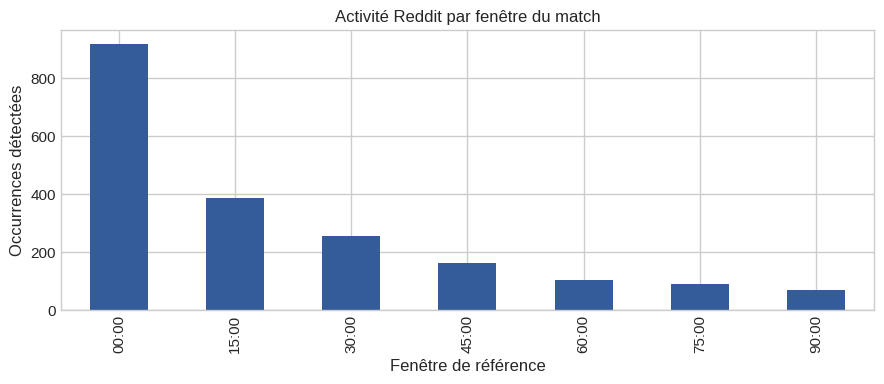

In [607]:
if not reddit_period_counts.empty:
    ax = reddit_period_counts.plot(kind="bar", x="periode_reference", y="occurrences", legend=False, figsize=(9, 4), color="#355C9A")
    ax.set_title("Activité Reddit par fenêtre du match")
    ax.set_xlabel("Fenêtre de référence")
    ax.set_ylabel("Occurrences détectées")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "reddit_activity_period_matches.png", dpi=200)
    plt.show()


**Lecture rapide :** ce graphique compte les occurrences détectées autour des fenêtres du match. Un même commentaire peut être proche de deux fenêtres, donc le total peut être supérieur au nombre de commentaires uniques. Cette méthode respecte mieux la sortie du scraper.

### 5. Données médias nettoyées

In [608]:
news_records = []
for path in news_files:
    obj = read_json_any(path)
    if isinstance(obj, list):
        news_records.extend(obj)
    elif isinstance(obj, dict):
        news_records.extend(obj.get("articles", obj.get("data", [obj])))

news_raw = pd.json_normalize(news_records)
news_raw.shape, news_raw.head(2)


((100, 15),
                     match_id                match_name  match_date  \
 0  galata_liverpool_20260310  Galatasaray vs Liverpool  2026-03-10   
 1  galata_liverpool_20260310  Galatasaray vs Liverpool  2026-03-10   
 
                     competition  \
 0  Champions League Round of 16   
 1  Champions League Round of 16   
 
                                                                                    title  \
 0  Officials and Liverpool’s wastefulness concern Arne Slot in loss to Galatasaray - MSN   
 1                            Liverpool 4-0 Galatasaray (Mar 18, 2026) Final Score - ESPN   
 
                                                                                                                                                                url  \
 0  https://news.google.com/rss/articles/CBMi3wFBVV95cUxNZk1fWWwwazBCTkpIbHVBVVUxZjJOU1NOQmFweXE3VkhucWNSMlB3cG9oQ2ppZHVlLTFjNjN1OUg5WVVjcXA4RWo1cXFFRUZDeGIyVFN...   
 1  https://news.google.com/rss/articles/CBMif0F

In [609]:
def normalize_news(df):
    if df.empty:
        return pd.DataFrame()
    out = pd.DataFrame()
    out["platform"] = "Médias"
    out["title"] = df.get("title", "").map(clean_text)
    out["description"] = df.get("description", "").map(clean_text)
    out["content"] = df.get("content", "").map(clean_text)
    out["publisher"] = df.get("publisher", df.get("source", "inconnu"))
    out["source"] = df.get("source", "inconnu")
    out["url"] = df.get("url", "")
    out["published_at"] = pd.to_datetime(df.get("published_date", df.get("published_at", df.get("date", pd.NaT))), errors="coerce", utc=True)
    out["date"] = out["published_at"].dt.date
    out["content_is_noise"] = out["content"].map(is_cookie_or_consent_text)
    out["text_for_analysis"] = np.where(
        out["content_is_noise"],
        out["title"] + " " + out["description"] + " " + out["publisher"].astype(str),
        out["title"] + " " + out["description"] + " " + out["content"],
    )
    out["sentiment_simple"] = out["text_for_analysis"].map(simple_sentiment)
    return out

news_df = normalize_news(news_raw)
news_df[["title", "publisher", "published_at", "content_is_noise", "text_for_analysis"]].head()


,title,publisher,published_at,content_is_noise,text_for_analysis
0,Officials and Liverpool’s wastefulness concern Arne Slot in loss to Galatasaray - MSN,MSN,2026-05-25 00:56:34+00:00,True,Officials and Liverpool’s wastefulness concern Arne Slot in loss to Galatasaray - MSN Officials and Liverpool’s wastefulness concern Arne Slot in loss to Ga...
1,"Liverpool 4-0 Galatasaray (Mar 18, 2026) Final Score - ESPN",ESPN,2026-02-27 12:38:14+00:00,True,"Liverpool 4-0 Galatasaray (Mar 18, 2026) Final Score - ESPN Liverpool 4-0 Galatasaray (Mar 18, 2026) Final Score ESPN ESPN"
2,"💣 Galatasaray shock Liverpool, Lemina scores, Osimhen in tears 😭 - Yahoo Sports",Yahoo Sports,2026-03-10 07:00:00+00:00,True,"💣 Galatasaray shock Liverpool, Lemina scores, Osimhen in tears 😭 - Yahoo Sports 💣 Galatasaray shock Liverpool, Lemina scores, Osimhen in tears 😭 Yahoo Sport..."
3,"Liverpool vs. Galatasaray: Preview, Predictions and Lineups - Sports Illustrated",Sports Illustrated,2026-03-17 07:00:00+00:00,True,"Liverpool vs. Galatasaray: Preview, Predictions and Lineups - Sports Illustrated Liverpool vs. Galatasaray: Preview, Predictions and Lineups Sports Illustra..."
4,"Is Galatasaray vs Liverpool on TV? Channel, kick-off time and how to watch Champions League tie - Yahoo Sports",Yahoo Sports,2026-03-10 07:00:00+00:00,True,"Is Galatasaray vs Liverpool on TV? Channel, kick-off time and how to watch Champions League tie - Yahoo Sports Is Galatasaray vs Liverpool on TV? Channel, k..."


In [610]:
noise_summary = news_df["content_is_noise"].value_counts(dropna=False).rename_axis("contenu_bruite").reset_index(name="articles")
noise_summary


,contenu_bruite,articles
0,True,79
1,False,21


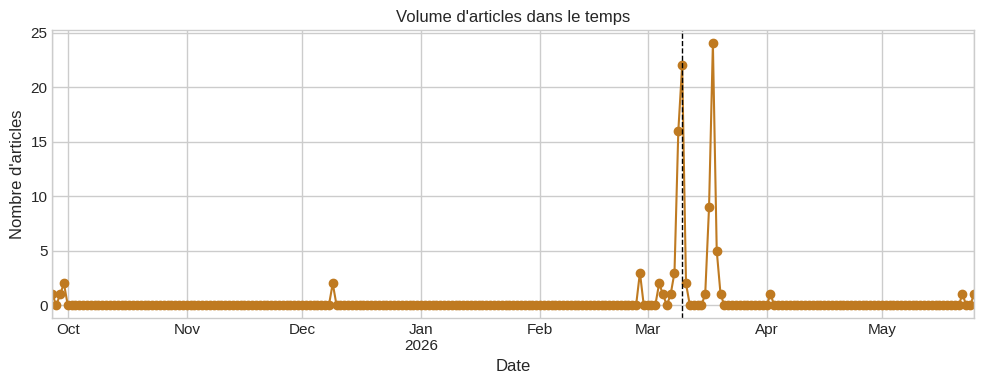

In [611]:
if not news_df.empty and news_df["published_at"].notna().any():
    news_daily = news_df.dropna(subset=["published_at"]).set_index("published_at").resample("D").size().reset_index(name="articles")
    ax = news_daily.plot(x="published_at", y="articles", figsize=(10, 4), marker="o", legend=False, color="#BF7A21")
    ax.axvline(pd.Timestamp(MATCH_DATE, tz="UTC"), color="black", linestyle="--", linewidth=1)
    ax.set_title("Volume d'articles dans le temps")
    ax.set_xlabel("Date")
    ax.set_ylabel("Nombre d'articles")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "news_volume_over_time.png", dpi=200)
    plt.show()


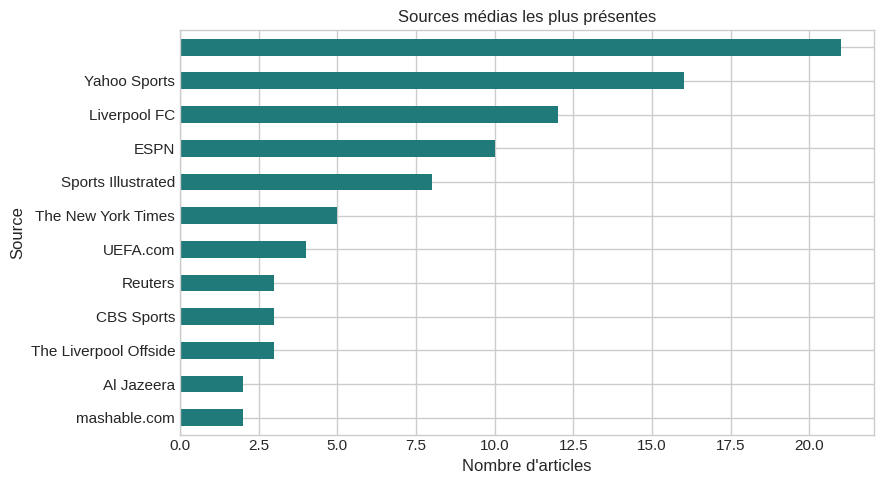

,source_media,articles
0,,21
1,Yahoo Sports,16
2,Liverpool FC,12
3,ESPN,10
4,Sports Illustrated,8
5,The New York Times,5
6,UEFA.com,4
7,The Liverpool Offside,3
8,Reuters,3
9,CBS Sports,3


In [612]:
top_publishers = news_df["publisher"].fillna("inconnu").astype(str).value_counts().head(12).reset_index()
top_publishers.columns = ["source_media", "articles"]

ax = top_publishers.sort_values("articles").plot(kind="barh", x="source_media", y="articles", legend=False, figsize=(9, 5), color="#207A7A")
ax.set_title("Sources médias les plus présentes")
ax.set_xlabel("Nombre d'articles")
ax.set_ylabel("Source")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "news_top_publishers.png", dpi=200)
plt.show()

top_publishers


### 6. Mots-clés et comparaison

In [613]:
reddit_keywords = extract_keywords(reddit_df["text"], top_n=25)
news_keywords = extract_keywords(news_df["text_for_analysis"], top_n=25)

print("Mots-clés Reddit")
display(reddit_keywords.head(15))
print("Mots-clés médias nettoyés")
display(news_keywords.head(15))


Mots-clés Reddit


,mot_cle,nombre
0,liverpool,102
1,team,88
2,slot,84
3,season,84
4,get,71
5,shit,62
6,him,61
7,players,51
8,think,50
9,bad,45


Mots-clés médias nettoyés


,mot_cle,nombre
0,liverpool,462
1,galatasaray,396
2,ligue,206
3,par,102
4,après,100
5,sports,98
6,son,85
7,reds,77
8,contre,77
9,osimhen,71


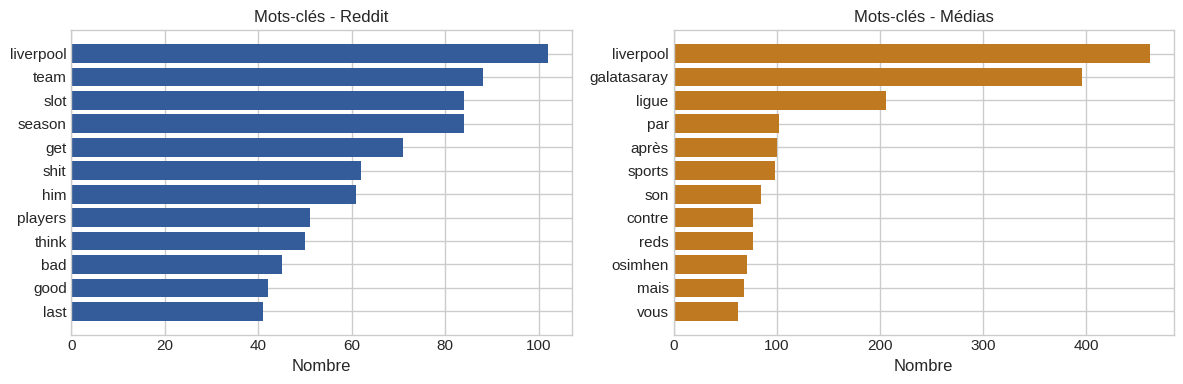

In [614]:
keyword_compare = pd.concat([
    reddit_keywords.head(12).assign(plateforme="Reddit"),
    news_keywords.head(12).assign(plateforme="Médias"),
], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, platform, color in zip(axes, ["Reddit", "Médias"], ["#355C9A", "#BF7A21"]):
    data = keyword_compare[keyword_compare["plateforme"] == platform].sort_values("nombre")
    ax.barh(data["mot_cle"], data["nombre"], color=color)
    ax.set_title(f"Mots-clés - {platform}")
    ax.set_xlabel("Nombre")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "keyword_comparison.png", dpi=200)
plt.show()


### 7. Entités : équipes, joueurs et entraîneurs

In [615]:
def collect_entities_from_match(match):
    entities = []
    teams = match.get("teams", {}) if isinstance(match, dict) else {}
    for value in teams.values():
        if value:
            entities.append(str(value))
    teams_players = match.get("teams_players", {}) if isinstance(match, dict) else {}
    for side in teams_players.values():
        if not isinstance(side, dict):
            continue
        for key in ["name", "trainer"]:
            if side.get(key):
                entities.append(str(side[key]))
        for key in ["key_players", "all_players"]:
            entities.extend([str(x) for x in side.get(key, []) if x])
    entities.extend(["UEFA", "Champions League", "Anfield", "Istanbul", "VAR", "penalty", "goal"])
    seen = []
    for ent in entities:
        if ent not in seen:
            seen.append(ent)
    return seen

entities = collect_entities_from_match(match_info)
entities[:20], len(entities)


(['Galatasaray',
  'Liverpool',
  'Okan Buruk',
  'Mauro Icardi',
  'Victor Osimhen',
  'Fernando Muslera',
  'Günay Güvenç',
  'Jankat Yılmaz',
  'Davinson Sánchez',
  'Abdülkerim Bardakcı',
  'Kaan Ayhan',
  'Elias Jelert',
  'Derrick Köhn',
  'Metehan Baltacı',
  'Ali Turap Bülbül',
  'Lucas Torreira',
  'Berkan Kutlu',
  'Gabriel Sara',
  'Kerem Demirbay',
  'Sérgio Oliveira'],
 60)

In [616]:
def count_entity_mentions(df, text_col, entities):
    corpus = " ".join(df.get(text_col, pd.Series(dtype=str)).fillna("").astype(str))
    rows = []
    for ent in entities:
        pattern = re.escape(ent)
        count = len(re.findall(pattern, corpus, flags=re.IGNORECASE))
        if count > 0:
            rows.append({"entite": ent, "mentions": count})
    return pd.DataFrame(rows).sort_values("mentions", ascending=False)

reddit_entities = count_entity_mentions(reddit_df, "text", entities)
news_entities = count_entity_mentions(news_df, "text_for_analysis", entities)
entity_compare = pd.concat([
    reddit_entities.head(12).assign(plateforme="Reddit"),
    news_entities.head(12).assign(plateforme="Médias"),
], ignore_index=True)

display(reddit_entities.head(15))
display(news_entities.head(15))


,entite,mentions
1,Liverpool,116
13,goal,45
0,Galatasaray,39
9,Anfield,37
11,VAR,11
8,Champions League,7
7,UEFA,4
10,Istanbul,2
4,Arne Slot,2
2,Okan Buruk,1


,entite,mentions
1,Liverpool,478
0,Galatasaray,413
22,Anfield,45
4,Victor Osimhen,44
21,Champions League,43
25,penalty,21
20,UEFA,18
11,Arne Slot,17
12,Mohamed Salah,16
23,Istanbul,14


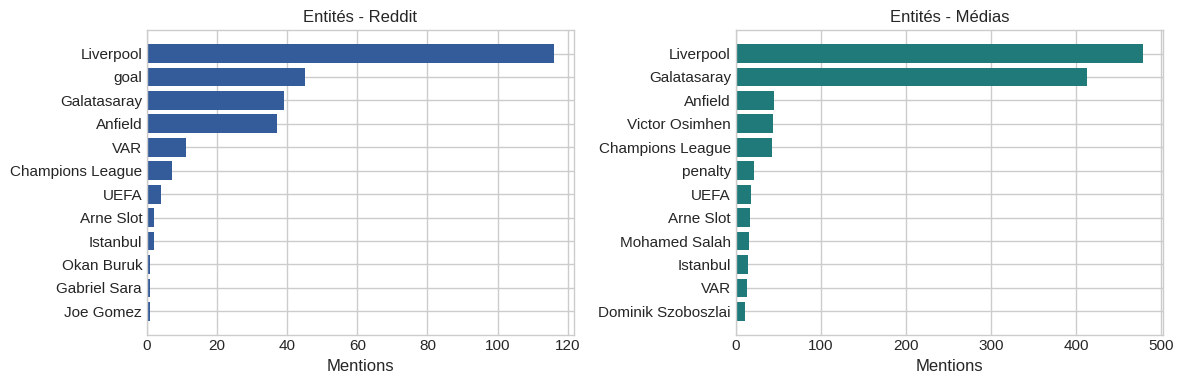

In [617]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, platform, color in zip(axes, ["Reddit", "Médias"], ["#355C9A", "#207A7A"]):
    data = entity_compare[entity_compare["plateforme"] == platform].sort_values("mentions")
    ax.barh(data["entite"], data["mentions"], color=color)
    ax.set_title(f"Entités - {platform}")
    ax.set_xlabel("Mentions")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "entity_mentions.png", dpi=200)
plt.show()


### 8. Partie TAL d'Abdelkerim

In [618]:
tal_path = TAL_DIR / "resultats_tal_galata_liverpool.csv"
if tal_path.exists():
    tal_df = pd.read_csv(tal_path)
else:
    tal_df = pd.DataFrame()

tal_df.head()


,heure,titre,evenement,score,commentaires,commentaires_periode,minute_match,categorie_temps
0,2026-03-19 10:09:51 UTC,Looking at the sequence of events around Liverpool vs Galatasaray – did the conditions feel fully balanced?,AUTRE,NaN,9,0,12369,APRES_MATCH
1,2026-02-02 12:48:25 UTC,"10 years ago today, Jamie Vardy’s volley vs Liverpool.",VAR,NaN,338,0,-52272,AVANT_MATCH
2,2026-05-03 13:27:26 UTC,Match Thread: Manchester United vs Liverpool | Premier League | 03 May 14:30 UTC,MATCH_THREAD,14:30,484,0,77367,APRES_MATCH
3,2025-09-30 21:02:05 UTC,Post Match Thread: Galatasaray 1 : Liverpool 0 [Champions League MD2],FIN_MATCH,NaN,466,0,-231778,AVANT_MATCH
4,2023-03-05 18:20:47 UTC,Post Match Thread: Liverpool 7 - 0 Manchester United | English Premier League,FIN_MATCH,7 - 0,376,0,-1585540,AVANT_MATCH


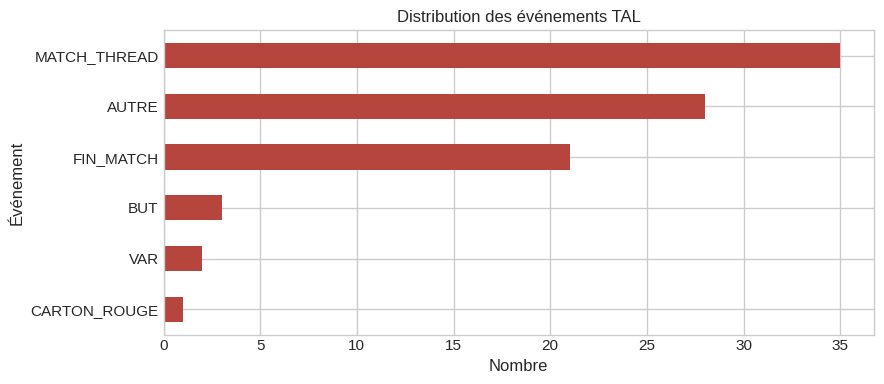

,evenement,nombre
0,MATCH_THREAD,35
1,AUTRE,28
2,FIN_MATCH,21
3,BUT,3
4,VAR,2
5,CARTON_ROUGE,1


In [619]:
if not tal_df.empty and "evenement" in tal_df.columns:
    tal_event_counts = tal_df["evenement"].fillna("INCONNU").value_counts().reset_index()
    tal_event_counts.columns = ["evenement", "nombre"]
    ax = tal_event_counts.sort_values("nombre").plot(kind="barh", x="evenement", y="nombre", legend=False, figsize=(9, 4), color="#B6463D")
    ax.set_title("Distribution des événements TAL")
    ax.set_xlabel("Nombre")
    ax.set_ylabel("Événement")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "tal_event_distribution.png", dpi=200)
    plt.show()
    display(tal_event_counts)
else:
    print("Aucun fichier TAL disponible.")


In [620]:
if not tal_df.empty and "categorie_temps" in tal_df.columns:
    tal_time_counts = tal_df["categorie_temps"].fillna("INCONNU").value_counts().reset_index()
    tal_time_counts.columns = ["categorie_temps", "nombre"]
    display(tal_time_counts)
else:
    tal_time_counts = pd.DataFrame()


,categorie_temps,nombre
0,AVANT_MATCH,64
1,APRES_MATCH,25
2,PENDANT_MATCH,1


### 9. Sentiment simple

Cette version n'utilise pas TextBlob. Elle utilise un petit lexique positif/négatif pour éviter un problème de dépendance. Le score est simple, mais il permet d'avoir une première comparaison.


In [621]:
sentiment_summary = pd.DataFrame({
    "plateforme": ["Reddit", "Médias"],
    "sentiment_moyen": [reddit_df["sentiment_simple"].mean(), news_df["sentiment_simple"].mean()],
    "elements": [len(reddit_df), len(news_df)],
})
sentiment_summary


,plateforme,sentiment_moyen,elements
0,Reddit,-0.002843,1228
1,Médias,-0.006189,100


### 10. Synthèse pour le rapport

À partir de cette version, on peut expliquer simplement :

- Reddit donne une réaction très proche des moments du match.
- Les médias donnent une vision plus large, souvent avant ou après le match.
- La partie TAL transforme les textes en événements sportifs structurés.
- Les données médias doivent être nettoyées, car certains contenus viennent de pages de consentement.
- La prochaine étape est d'ajouter Transfermarkt, Twitter/X, les images et les vidéos.


In [622]:
reddit_period_counts.to_csv(OUTPUT_DIR / "reddit_period_counts_v2.csv", index=False)
reddit_keywords.to_csv(OUTPUT_DIR / "reddit_keywords_v2.csv", index=False)
news_keywords.to_csv(OUTPUT_DIR / "news_keywords_v2.csv", index=False)
reddit_entities.to_csv(OUTPUT_DIR / "reddit_entities_v2.csv", index=False)
news_entities.to_csv(OUTPUT_DIR / "news_entities_v2.csv", index=False)
sentiment_summary.to_csv(OUTPUT_DIR / "sentiment_summary_v2.csv", index=False)
if not tal_df.empty and "evenement" in tal_df.columns:
    tal_event_counts.to_csv(OUTPUT_DIR / "tal_event_counts_v2.csv", index=False)
print(f"Exports écrits dans : {OUTPUT_DIR}")


Exports écrits dans : /content/drive/MyDrive/Project_Master/outputs_v2


## 3 Analyse multi-match et multi-plateforme


### 1. Préparation

Les données sont dans le dossier `data_new/raw`. Les graphiques et tableaux générés seront enregistrés dans `outputs_multi_match`.


In [623]:
from pathlib import Path
import json
import zipfile
import re
from html import unescape
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 140)
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook")


from google.colab import drive
drive.mount("/content/drive", force_remount=False)


PROJECT_DIR  = Path("/content/drive/MyDrive/Project_Master")
RAW_DIR      = PROJECT_DIR / "data_new" / "raw"
OUTPUT_DIR_MM = PROJECT_DIR / "outputs_multi_match"
OUTPUT_DIR_MM.mkdir(parents=True, exist_ok=True)


if not RAW_DIR.exists():
    raise FileNotFoundError(
        f"RAW_DIR not found: {RAW_DIR}\n"
        "Make sure you uploaded matches_multi.json, player_ids.json, "
        "news_output.zip and scraper_output.zip into that folder."
    )

print("Dossier du projet :", PROJECT_DIR)
print("Dossier des données :", RAW_DIR)
print("Dossier des sorties :", OUTPUT_DIR_MM)
print("Fichiers dans RAW_DIR :", [f.name for f in RAW_DIR.iterdir()])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dossier du projet : /content/drive/MyDrive/Project_Master
Dossier des données : /content/drive/MyDrive/Project_Master/data_new/raw
Dossier des sorties : /content/drive/MyDrive/Project_Master/outputs_multi_match
Fichiers dans RAW_DIR : ['news_output.zip', 'scraper_output.zip', 'player_ids.json', 'matches_multi.json']


### 2. Chargement des fichiers



In [624]:
def read_json_mm(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def read_json_from_zip(zip_path, member_name):
    with zipfile.ZipFile(zip_path) as z:
        return json.loads(z.read(member_name).decode("utf-8"))


matches_config = read_json_mm(RAW_DIR / "matches_multi.json")
player_ids = read_json_mm(RAW_DIR / "player_ids.json")
news_zip = RAW_DIR / "news_output.zip"
scraper_zip = RAW_DIR / "scraper_output.zip"

print("Matchs configurés :", len(matches_config))
print("Joueurs dans player_ids :", len(player_ids))
print("Fichier news :", news_zip.name)
print("Fichier scraper :", scraper_zip.name)


Matchs configurés : 5
Joueurs dans player_ids : 232
Fichier news : news_output.zip
Fichier scraper : scraper_output.zip


### 3. Sources des données

Cette table explique clairement d'où viennent les données utilisées dans ce notebook.


In [625]:
sources_df = pd.DataFrame([
    {
        "fichier": "matches_multi.json",
        "origine": "message (1).txt",
        "contenu": "Configuration des 5 matchs : équipes, dates, joueurs, mots-clés, événements réels.",
        "utilisation": "Base du projet et timeline officielle.",
    },
    {
        "fichier": "player_ids.json",
        "origine": "message.txt",
        "contenu": "Dictionnaire joueur -> identifiant.",
        "utilisation": "Information complémentaire pour une analyse de joueurs.",
    },
    {
        "fichier": "news_output.zip",
        "origine": "résultat du scraper news",
        "contenu": "Articles collectés avec Google News RSS et Bing News.",
        "utilisation": "Analyse des médias et volume des articles.",
    },
    {
        "fichier": "scraper_output.zip",
        "origine": "résultat du scraper social media",
        "contenu": "Résultats YouTube et Reddit par match.",
        "utilisation": "Analyse des plateformes sociales.",
    },
])

sources_df.to_csv(OUTPUT_DIR / "data_sources.csv", index=False)
display(sources_df)


,fichier,origine,contenu,utilisation
0,matches_multi.json,message (1).txt,"Configuration des 5 matchs : équipes, dates, joueurs, mots-clés, événements réels.",Base du projet et timeline officielle.
1,player_ids.json,message.txt,Dictionnaire joueur -> identifiant.,Information complémentaire pour une analyse de joueurs.
2,news_output.zip,résultat du scraper news,Articles collectés avec Google News RSS et Bing News.,Analyse des médias et volume des articles.
3,scraper_output.zip,résultat du scraper social media,Résultats YouTube et Reddit par match.,Analyse des plateformes sociales.


### 4. Création des tables propres

On transforme les fichiers JSON en tables pandas :

- une table des matchs ;
- une table des événements réels ;
- une table des articles de presse ;
- une table des posts YouTube/Reddit ;
- une table des commentaires récupérés.


In [626]:
def clean_text_mm(value):
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return ""
    text = unescape(str(value))
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"https?://\S+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


match_rows = []
event_rows = []
for match in matches_config:
    home = match.get("teams", {}).get("home", "")
    away = match.get("teams", {}).get("away", "")
    match_rows.append({
        "match_id": match.get("match_id"),
        "match_name": match.get("name"),
        "date": pd.to_datetime(match.get("date"), utc=True, errors="coerce"),
        "competition": match.get("competition"),
        "home_team": home,
        "away_team": away,
        "events_count": len(match.get("events", [])),
        "keywords_count": len(match.get("search_keywords", [])),
        "subreddits_count": len(match.get("subreddits", [])),
    })
    for event in match.get("events", []):
        event_rows.append({
            "match_id": match.get("match_id"),
            "match_name": match.get("name"),
            "minute": event.get("minute"),
            "event_type": event.get("type"),
            "team": event.get("team"),
            "player": event.get("player"),
            "description": event.get("desc"),
        })

matches_df = pd.DataFrame(match_rows).sort_values("date")
events_df = pd.DataFrame(event_rows).sort_values(["match_id", "minute"])


news_records = []
with zipfile.ZipFile(news_zip) as z:
    for name in z.namelist():
        if name.startswith("__MACOSX"):
            continue
        if name.endswith("_ALL.json"):
            data = json.loads(z.read(name).decode("utf-8"))
            for item in data:
                item = dict(item)
                item["zip_member"] = name
                news_records.append(item)

news_df_mm = pd.DataFrame(news_records)
news_df_mm["title_clean"] = news_df_mm["title"].apply(clean_text_mm)
news_df_mm["description_clean"] = news_df_mm["description"].apply(clean_text_mm)
news_df_mm["text"] = (news_df_mm["title_clean"] + " " + news_df_mm["description_clean"]).str.strip()
news_df_mm["published_at"] = pd.to_datetime(news_df_mm["published_date"], utc=True, errors="coerce")
news_df_mm["match_date_dt"] = pd.to_datetime(news_df_mm["match_date"], utc=True, errors="coerce")
news_df_mm["days_from_match"] = (news_df_mm["published_at"] - news_df_mm["match_date_dt"]).dt.days
news_df_mm["publisher"] = news_df_mm["publisher"].replace("", "inconnu").fillna("inconnu")
news_df_mm["source"] = news_df_mm["source"].fillna("inconnu")



post_records = []
comment_records = []
scraper_summaries = []
with zipfile.ZipFile(scraper_zip) as z:
    for name in z.namelist():
        if name.startswith("__MACOSX") or not name.endswith(".json"):
            continue
        if name.endswith("summary.json"):
            scraper_summaries.append(json.loads(z.read(name).decode("utf-8")))
            continue
        if "/match_" not in name:
            continue
        obj = json.loads(z.read(name).decode("utf-8"))
        platform = obj.get("platform")
        match_id = obj.get("match_id")
        match_name = obj.get("match_name")
        for post in obj.get("posts", []):
            created_time = post.get("created_time")
            if not created_time and post.get("extra", {}).get("published_at"):
                created_time = post.get("extra", {}).get("published_at")
            post_records.append({
                "match_id": match_id,
                "match_name": match_name,
                "platform": platform,
                "post_id": post.get("post_id"),
                "title": clean_text_mm(post.get("title")),
                "author": post.get("author"),
                "channel": post.get("channel") or post.get("author"),
                "url": post.get("url"),
                "score": post.get("score", 0),
                "num_comments_reported": post.get("num_comments", post.get("num_comments_reported", 0)),
                "num_comments_fetched": post.get("comment_count_fetched", len(post.get("comments", []))),
                "created_at": pd.to_datetime(created_time, utc=True, errors="coerce"),
                "zip_member": name,
            })
            for comment in post.get("comments", []):
                period_matches = comment.get("period_matches", [])
                periods = []
                if isinstance(period_matches, list):
                    for period in period_matches:
                        if isinstance(period, dict):
                            periods.append(period.get("period"))
                        else:
                            periods.append(str(period))
                comment_records.append({
                    "match_id": match_id,
                    "match_name": match_name,
                    "platform": platform,
                    "post_id": post.get("post_id"),
                    "post_title": clean_text_mm(post.get("title")),
                    "comment_id": comment.get("comment_id"),
                    "author": comment.get("author"),
                    "body": clean_text_mm(comment.get("body")),
                    "score": comment.get("score", 0),
                    "created_at": pd.to_datetime(comment.get("created_time"), utc=True, errors="coerce"),
                    "periods": ", ".join([p for p in periods if p]),
                    "period_count": len([p for p in periods if p]),
                })

posts_df = pd.DataFrame(post_records)
comments_df = pd.DataFrame(comment_records)

print("Matchs :", matches_df.shape)
print("Événements :", events_df.shape)
print("Articles news :", news_df_mm.shape)
print("Posts sociaux :", posts_df.shape)
print("Commentaires récupérés :", comments_df.shape)

display(matches_df)
display(events_df.head(10))


Matchs : (5, 9)
Événements : (26, 7)
Articles news : (400, 22)
Posts sociaux : (99, 13)
Commentaires récupérés : (111, 12)


,match_id,match_name,date,competition,home_team,away_team,events_count,keywords_count,subreddits_count
2,atletico_madrid_inter_20260305,Atlético Madrid vs Inter Milan,2026-03-05 00:00:00+00:00,Champions League Round of 16,Atlético Madrid,Inter Milan,5,5,4
0,real_madrid_man_city_20260311,Real Madrid vs Manchester City,2026-03-11 00:00:00+00:00,Champions League Round of 16,Real Madrid,Manchester City,5,5,4
1,arsenal_psg_20260312,Arsenal vs PSG,2026-03-12 00:00:00+00:00,Champions League Round of 16,Arsenal,PSG,5,5,4
3,barcelona_bayer_leverkusen_20260317,Barcelona vs Bayer Leverkusen,2026-03-17 00:00:00+00:00,Champions League Round of 16,Barcelona,Bayer Leverkusen,6,5,4
4,liverpool_galatasaray_20260318,Liverpool vs Galatasaray,2026-03-18 00:00:00+00:00,Champions League Round of 16 — 2nd Leg,Liverpool,Galatasaray,5,5,4


,match_id,match_name,minute,event_type,team,player,description
5,arsenal_psg_20260312,Arsenal vs PSG,7,yellow,PSG,Achraf Hakimi,Hakimi booked for foul on Saka
6,arsenal_psg_20260312,Arsenal vs PSG,22,goal,Arsenal,Bukayo Saka,Saka curls in from the right flank
7,arsenal_psg_20260312,Arsenal vs PSG,44,goal,PSG,Ousmane Dembélé,Dembélé equalises before half-time
8,arsenal_psg_20260312,Arsenal vs PSG,63,penalty,Arsenal,Martin Ødegaard,Ødegaard penalty awarded after VAR review — saved by Donnarumma
9,arsenal_psg_20260312,Arsenal vs PSG,81,red,Arsenal,Declan Rice,Rice second yellow for time-wasting
10,atletico_madrid_inter_20260305,Atlético Madrid vs Inter Milan,18,goal,Inter Milan,Marcus Thuram,Thuram heads Inter ahead from a corner
11,atletico_madrid_inter_20260305,Atlético Madrid vs Inter Milan,34,yellow,Atlético Madrid,Rodrigo De Paul,De Paul booked for late challenge on Barella
12,atletico_madrid_inter_20260305,Atlético Madrid vs Inter Milan,51,goal,Atlético Madrid,Antoine Griezmann,Griezmann equalises with a low finish
13,atletico_madrid_inter_20260305,Atlético Madrid vs Inter Milan,67,var,Inter Milan,Lautaro Martínez,Lautaro goal ruled out — handball in build-up
14,atletico_madrid_inter_20260305,Atlético Madrid vs Inter Milan,85,goal,Atlético Madrid,Julián Álvarez,Álvarez wins it with a header at the back post


### 5. Vue générale des données

On vérifie d'abord la quantité de données par match et par source.  
C'est important car toutes les plateformes ne donnent pas la même quantité d'information.


In [627]:
news_counts = (
    news_df_mm.groupby(["match_id", "match_name", "source"])
    .size()
    .rename("articles")
    .reset_index()
)

post_counts = (
    posts_df.groupby(["match_id", "match_name", "platform"])
    .agg(
        posts=("post_id", "count"),
        comments_reported=("num_comments_reported", "sum"),
        comments_fetched=("num_comments_fetched", "sum"),
        score_total=("score", "sum"),
    )
    .reset_index()
)

overview = (
    matches_df[["match_id", "match_name", "date", "events_count"]]
    .merge(news_df_mm.groupby("match_id").size().rename("news_articles").reset_index(), on="match_id", how="left")
    .merge(posts_df.groupby("match_id").size().rename("social_posts").reset_index(), on="match_id", how="left")
    .merge(comments_df.groupby("match_id").size().rename("comments_fetched").reset_index(), on="match_id", how="left")
)
overview = overview.fillna({"news_articles": 0, "social_posts": 0, "comments_fetched": 0})
overview[["news_articles", "social_posts", "comments_fetched"]] = overview[["news_articles", "social_posts", "comments_fetched"]].astype(int)

overview.to_csv(OUTPUT_DIR_MM / "multi_match_overview.csv", index=False)
news_counts.to_csv(OUTPUT_DIR_MM / "news_counts_by_match_source.csv", index=False)
post_counts.to_csv(OUTPUT_DIR_MM / "social_counts_by_match_platform.csv", index=False)

display(overview)
display(news_counts.head(20))
display(post_counts)


,match_id,match_name,date,events_count,news_articles,social_posts,comments_fetched
0,atletico_madrid_inter_20260305,Atlético Madrid vs Inter Milan,2026-03-05 00:00:00+00:00,5,100,19,0
1,real_madrid_man_city_20260311,Real Madrid vs Manchester City,2026-03-11 00:00:00+00:00,5,100,18,106
2,arsenal_psg_20260312,Arsenal vs PSG,2026-03-12 00:00:00+00:00,5,100,19,0
3,barcelona_bayer_leverkusen_20260317,Barcelona vs Bayer Leverkusen,2026-03-17 00:00:00+00:00,6,0,25,0
4,liverpool_galatasaray_20260318,Liverpool vs Galatasaray,2026-03-18 00:00:00+00:00,5,100,18,5


,match_id,match_name,source,articles
0,arsenal_psg_20260312,Arsenal vs PSG,bing_news,4
1,arsenal_psg_20260312,Arsenal vs PSG,google_news_rss,96
2,atletico_madrid_inter_20260305,Atlético Madrid vs Inter Milan,bing_news,33
3,atletico_madrid_inter_20260305,Atlético Madrid vs Inter Milan,google_news_rss,67
4,liverpool_galatasaray_20260318,Liverpool vs Galatasaray,bing_news,21
5,liverpool_galatasaray_20260318,Liverpool vs Galatasaray,google_news_rss,79
6,real_madrid_man_city_20260311,Real Madrid vs Manchester City,bing_news,24
7,real_madrid_man_city_20260311,Real Madrid vs Manchester City,google_news_rss,76


,match_id,match_name,platform,posts,comments_reported,comments_fetched,score_total
0,arsenal_psg_20260312,Arsenal vs PSG,youtube,19,6556,0,68380
1,atletico_madrid_inter_20260305,Atlético Madrid vs Inter Milan,youtube,19,3512,0,385865
2,barcelona_bayer_leverkusen_20260317,Barcelona vs Bayer Leverkusen,youtube,25,11246,0,1121961
3,liverpool_galatasaray_20260318,Liverpool vs Galatasaray,youtube,18,7835,5,1092533
4,real_madrid_man_city_20260311,Real Madrid vs Manchester City,youtube,18,10269,106,823144


### 6. Comparaison des volumes

Ce graphique montre le volume de presse et le volume social pour chaque match.


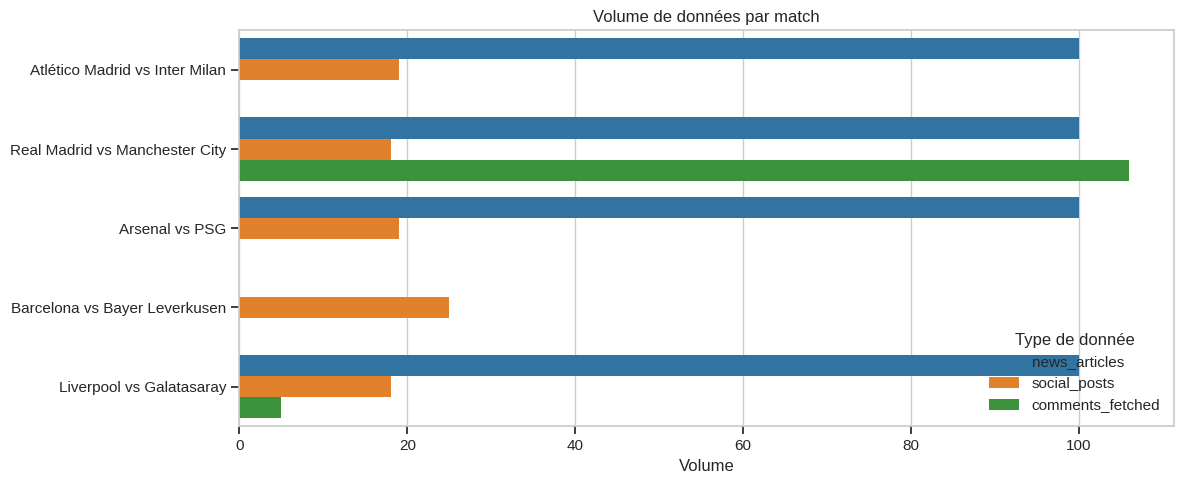

In [628]:
overview_long = overview.melt(
    id_vars=["match_id", "match_name"],
    value_vars=["news_articles", "social_posts", "comments_fetched"],
    var_name="type_donnee",
    value_name="volume",
)

plt.figure(figsize=(12, 5))
sns.barplot(data=overview_long, y="match_name", x="volume", hue="type_donnee")
plt.title("Volume de données par match")
plt.xlabel("Volume")
plt.ylabel("")
plt.legend(title="Type de donnée")
plt.tight_layout()
plt.savefig(OUTPUT_DIR_MM / "volume_by_match.png", dpi=160, bbox_inches="tight")
plt.show()


### 7. Analyse des médias

Les articles viennent de deux sources de collecte : Google News RSS et Bing News.  
On regarde aussi les éditeurs les plus présents.


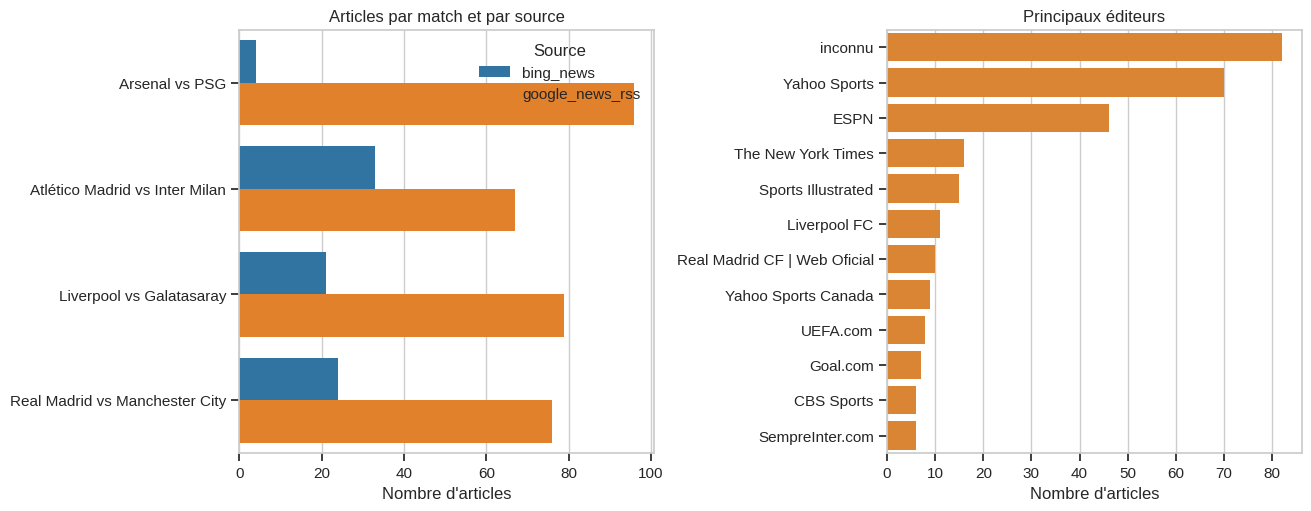

,publisher,articles
0,inconnu,82
1,Yahoo Sports,70
2,ESPN,46
3,The New York Times,16
4,Sports Illustrated,15
5,Liverpool FC,11
6,Real Madrid CF | Web Oficial,10
7,Yahoo Sports Canada,9
8,UEFA.com,8
9,Goal.com,7


In [629]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

sns.barplot(data=news_counts, y="match_name", x="articles", hue="source", ax=axes[0])
axes[0].set_title("Articles par match et par source")
axes[0].set_xlabel("Nombre d'articles")
axes[0].set_ylabel("")
axes[0].legend(title="Source")

top_publishers = news_df_mm["publisher"].value_counts().head(12).rename_axis("publisher").reset_index(name="articles")
sns.barplot(data=top_publishers, y="publisher", x="articles", color="#F58518", ax=axes[1])
axes[1].set_title("Principaux éditeurs")
axes[1].set_xlabel("Nombre d'articles")
axes[1].set_ylabel("")

fig.savefig(OUTPUT_DIR_MM / "news_sources_publishers.png", dpi=160, bbox_inches="tight")
plt.show()

top_publishers.to_csv(OUTPUT_DIR_MM / "top_news_publishers.csv", index=False)
display(top_publishers)


### 8. Timeline des articles

On mesure le nombre de jours entre la publication de l'article et la date du match.  
Cela permet de voir si les médias parlent surtout avant, pendant ou après le match.


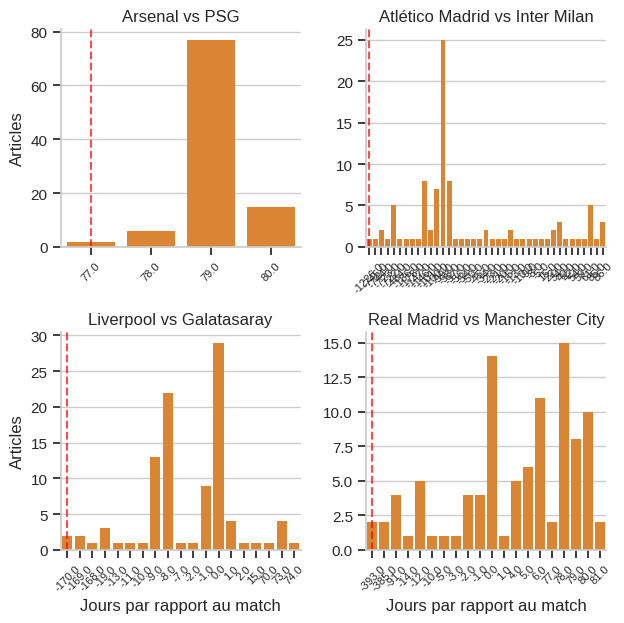

,match_id,match_name,days_from_match,articles
0,arsenal_psg_20260312,Arsenal vs PSG,77.0,2
1,arsenal_psg_20260312,Arsenal vs PSG,78.0,6
2,arsenal_psg_20260312,Arsenal vs PSG,79.0,77
3,arsenal_psg_20260312,Arsenal vs PSG,80.0,15
4,atletico_madrid_inter_20260305,Atlético Madrid vs Inter Milan,-1226.0,1
5,atletico_madrid_inter_20260305,Atlético Madrid vs Inter Milan,-745.0,1
6,atletico_madrid_inter_20260305,Atlético Madrid vs Inter Milan,-744.0,2
7,atletico_madrid_inter_20260305,Atlético Madrid vs Inter Milan,-723.0,1
8,atletico_madrid_inter_20260305,Atlético Madrid vs Inter Milan,-722.0,5
9,atletico_madrid_inter_20260305,Atlético Madrid vs Inter Milan,-484.0,1


In [630]:
news_timeline = (
    news_df_mm.dropna(subset=["days_from_match"])
    .groupby(["match_id", "match_name", "days_from_match"])
    .size()
    .rename("articles")
    .reset_index()
)

g = sns.FacetGrid(
    news_timeline,
    col="match_name",
    col_wrap=2,
    height=3.2,
    sharex=False,
    sharey=False,
)
g.map_dataframe(sns.barplot, x="days_from_match", y="articles", color="#F58518")
g.set_axis_labels("Jours par rapport au match", "Articles")
g.set_titles("{col_name}")
for ax in g.axes.flat:
    ax.axvline(0, color="red", linestyle="--", alpha=0.7)
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_fontsize(8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR_MM / "news_timeline_by_match.png", dpi=160, bbox_inches="tight")
plt.show()

news_timeline.to_csv(OUTPUT_DIR_MM / "news_timeline_by_match.csv", index=False)
display(news_timeline.head(20))


### 9. Analyse YouTube et Reddit

Dans ce nouveau fichier, YouTube est la plateforme la plus présente.  
Reddit est présent dans la structure, mais les fichiers Reddit contiennent très peu ou pas de posts.


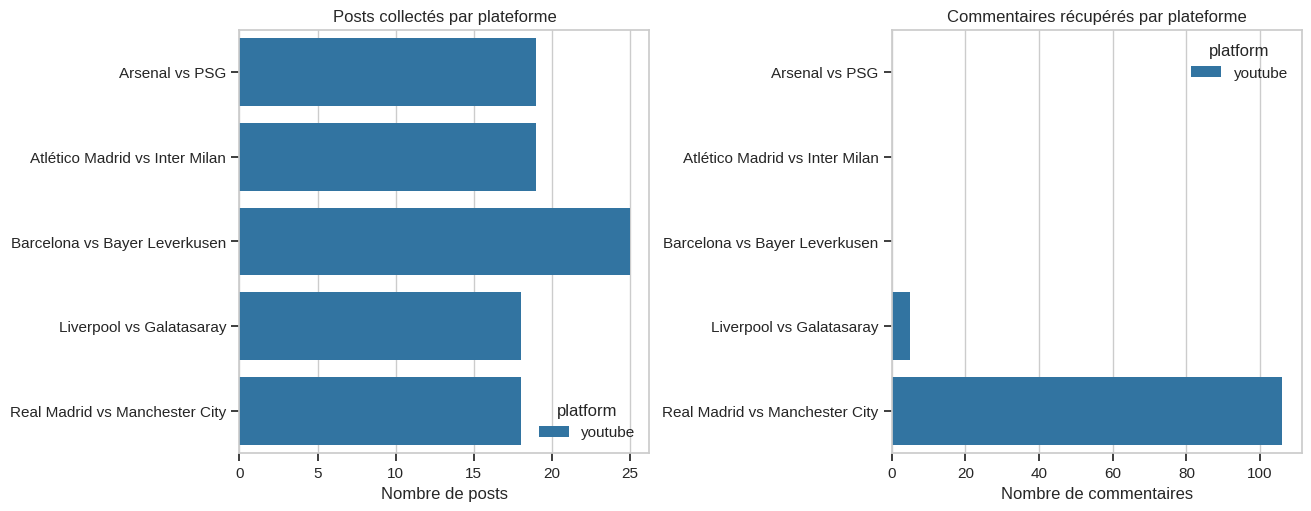

,platform,match_name,posts,comments_reported,comments_fetched,total_score
0,youtube,Arsenal vs PSG,19,6556,0,68380
1,youtube,Atlético Madrid vs Inter Milan,19,3512,0,385865
2,youtube,Barcelona vs Bayer Leverkusen,25,11246,0,1121961
3,youtube,Liverpool vs Galatasaray,18,7835,5,1092533
4,youtube,Real Madrid vs Manchester City,18,10269,106,823144


In [631]:
platform_counts = (
    posts_df.groupby(["platform", "match_name"])
    .agg(
        posts=("post_id", "count"),
        comments_reported=("num_comments_reported", "sum"),
        comments_fetched=("num_comments_fetched", "sum"),
        total_score=("score", "sum"),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

sns.barplot(data=platform_counts, y="match_name", x="posts", hue="platform", ax=axes[0])
axes[0].set_title("Posts collectés par plateforme")
axes[0].set_xlabel("Nombre de posts")
axes[0].set_ylabel("")

sns.barplot(data=platform_counts, y="match_name", x="comments_fetched", hue="platform", ax=axes[1])
axes[1].set_title("Commentaires récupérés par plateforme")
axes[1].set_xlabel("Nombre de commentaires")
axes[1].set_ylabel("")

fig.savefig(OUTPUT_DIR_MM / "social_platform_counts.png", dpi=160, bbox_inches="tight")
plt.show()

platform_counts.to_csv(OUTPUT_DIR_MM / "platform_counts.csv", index=False)
display(platform_counts)


### 10. Chaînes YouTube les plus présentes

Cette partie montre quelles chaînes YouTube apparaissent le plus dans les résultats.


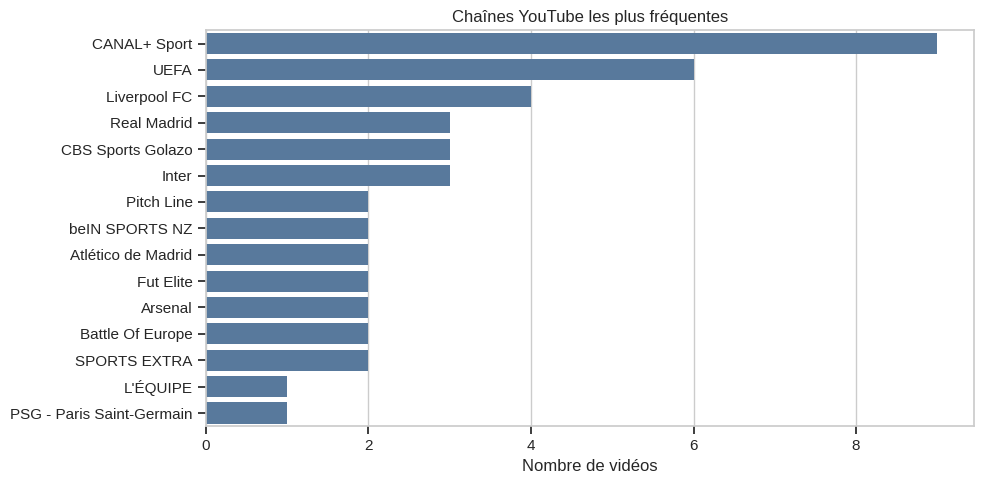

,channel,posts
0,CANAL+ Sport,9
1,UEFA,6
2,Liverpool FC,4
3,Real Madrid,3
4,CBS Sports Golazo,3
5,Inter,3
6,Pitch Line,2
7,beIN SPORTS NZ,2
8,Atlético de Madrid,2
9,Fut Elite,2


In [632]:
youtube_posts = posts_df[posts_df["platform"] == "youtube"].copy()
top_channels = (
    youtube_posts["channel"].fillna("inconnu")
    .value_counts()
    .head(15)
    .rename_axis("channel")
    .reset_index(name="posts")
)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_channels, y="channel", x="posts", color="#4C78A8")
plt.title("Chaînes YouTube les plus fréquentes")
plt.xlabel("Nombre de vidéos")
plt.ylabel("")
plt.tight_layout()
plt.savefig(OUTPUT_DIR_MM / "top_youtube_channels.png", dpi=160, bbox_inches="tight")
plt.show()

top_channels.to_csv(OUTPUT_DIR_MM / "top_youtube_channels.csv", index=False)
display(top_channels)


### 11. Commentaires et périodes du match

Certains commentaires récupérés contiennent des périodes de match comme `75:00` ou `90:00`.  
On peut les utiliser pour relier les réactions aux moments du match.


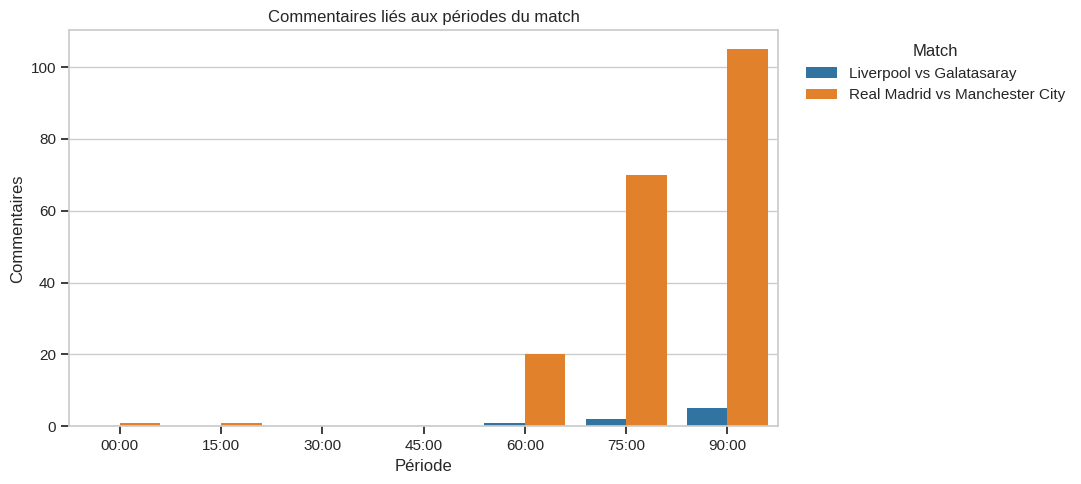

,match_name,period,commentaires
0,Liverpool vs Galatasaray,60:00,1
1,Liverpool vs Galatasaray,75:00,2
2,Liverpool vs Galatasaray,90:00,5
3,Real Madrid vs Manchester City,00:00,1
4,Real Madrid vs Manchester City,15:00,1
5,Real Madrid vs Manchester City,60:00,20
6,Real Madrid vs Manchester City,75:00,70
7,Real Madrid vs Manchester City,90:00,105


In [633]:
period_rows_mm = []
if not comments_df.empty:
    for _, row in comments_df.iterrows():
        periods = [p.strip() for p in str(row.get("periods", "")).split(",") if p.strip()]
        for period in periods:
            period_rows_mm.append({
                "match_id": row["match_id"],
                "match_name": row["match_name"],
                "platform": row["platform"],
                "period": period,
                "body": row["body"],
                "score": row["score"],
            })

comment_period_df = pd.DataFrame(period_rows_mm)
if comment_period_df.empty:
    print("Aucune période de commentaire disponible.")
else:
    period_order = ["00:00", "15:00", "30:00", "45:00", "60:00", "75:00", "90:00"]
    comment_period_counts = (
        comment_period_df.groupby(["match_name", "period"])
        .size()
        .rename("commentaires")
        .reset_index()
    )
    comment_period_counts["period"] = pd.Categorical(comment_period_counts["period"], categories=period_order, ordered=True)

    plt.figure(figsize=(11, 5))
    sns.barplot(data=comment_period_counts, x="period", y="commentaires", hue="match_name")
    plt.title("Commentaires liés aux périodes du match")
    plt.xlabel("Période")
    plt.ylabel("Commentaires")
    plt.legend(title="Match", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "comments_by_match_period.png", dpi=160, bbox_inches="tight")
    plt.show()

    comment_period_counts.to_csv(OUTPUT_DIR / "comments_by_match_period.csv", index=False)
    display(comment_period_counts)


### 12. Timeline officielle des événements

Les événements viennent du fichier `matches_multi.json`.  
Ils servent de référence pour comparer les réactions sociales et médiatiques.


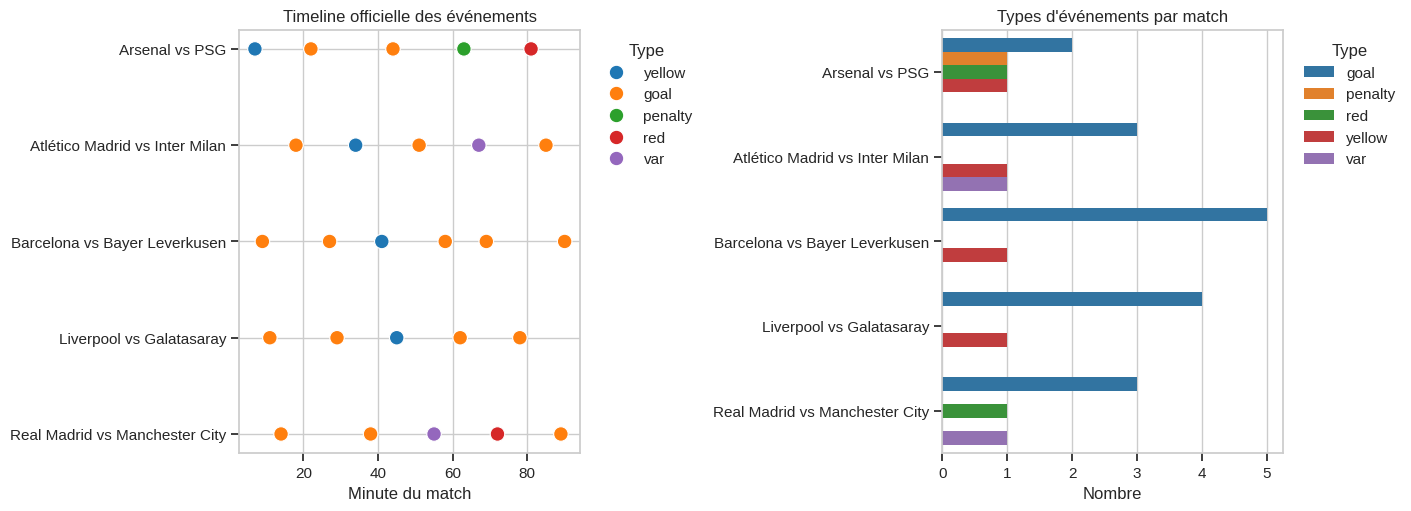

,match_id,match_name,minute,event_type,team,player,description
5,arsenal_psg_20260312,Arsenal vs PSG,7,yellow,PSG,Achraf Hakimi,Hakimi booked for foul on Saka
6,arsenal_psg_20260312,Arsenal vs PSG,22,goal,Arsenal,Bukayo Saka,Saka curls in from the right flank
7,arsenal_psg_20260312,Arsenal vs PSG,44,goal,PSG,Ousmane Dembélé,Dembélé equalises before half-time
8,arsenal_psg_20260312,Arsenal vs PSG,63,penalty,Arsenal,Martin Ødegaard,Ødegaard penalty awarded after VAR review — saved by Donnarumma
9,arsenal_psg_20260312,Arsenal vs PSG,81,red,Arsenal,Declan Rice,Rice second yellow for time-wasting
10,atletico_madrid_inter_20260305,Atlético Madrid vs Inter Milan,18,goal,Inter Milan,Marcus Thuram,Thuram heads Inter ahead from a corner
11,atletico_madrid_inter_20260305,Atlético Madrid vs Inter Milan,34,yellow,Atlético Madrid,Rodrigo De Paul,De Paul booked for late challenge on Barella
12,atletico_madrid_inter_20260305,Atlético Madrid vs Inter Milan,51,goal,Atlético Madrid,Antoine Griezmann,Griezmann equalises with a low finish
13,atletico_madrid_inter_20260305,Atlético Madrid vs Inter Milan,67,var,Inter Milan,Lautaro Martínez,Lautaro goal ruled out — handball in build-up
14,atletico_madrid_inter_20260305,Atlético Madrid vs Inter Milan,85,goal,Atlético Madrid,Julián Álvarez,Álvarez wins it with a header at the back post


In [634]:
event_type_counts = (
    events_df.groupby(["match_name", "event_type"])
    .size()
    .rename("events")
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

sns.scatterplot(
    data=events_df,
    x="minute",
    y="match_name",
    hue="event_type",
    s=110,
    ax=axes[0],
)
axes[0].set_title("Timeline officielle des événements")
axes[0].set_xlabel("Minute du match")
axes[0].set_ylabel("")
axes[0].legend(title="Type", bbox_to_anchor=(1.02, 1), loc="upper left")

sns.barplot(data=event_type_counts, y="match_name", x="events", hue="event_type", ax=axes[1])
axes[1].set_title("Types d'événements par match")
axes[1].set_xlabel("Nombre")
axes[1].set_ylabel("")
axes[1].legend(title="Type", bbox_to_anchor=(1.02, 1), loc="upper left")

fig.savefig(OUTPUT_DIR_MM / "official_event_timeline.png", dpi=160, bbox_inches="tight")
plt.show()

events_df.to_csv(OUTPUT_DIR_MM / "official_events.csv", index=False)
event_type_counts.to_csv(OUTPUT_DIR_MM / "event_type_counts.csv", index=False)
display(events_df)


### 13. Langues détectées

Le sujet du projet parle de perceptions selon les langues.  
Ici on utilise une détection simple par mots fréquents. C'est une première approximation.


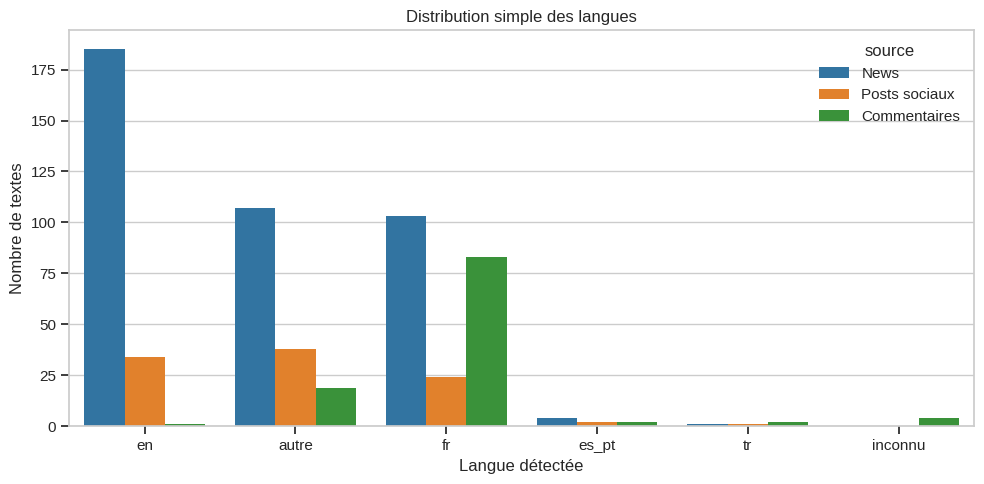

,langue,documents,source
0,en,185,News
1,autre,107,News
2,fr,103,News
3,es_pt,4,News
4,tr,1,News
5,autre,38,Posts sociaux
6,en,34,Posts sociaux
7,fr,24,Posts sociaux
8,es_pt,2,Posts sociaux
9,tr,1,Posts sociaux


In [635]:
LANG_MARKERS = {
    "fr": {"le", "la", "les", "des", "une", "avec", "pour", "mais", "très", "tres", "pas", "est", "sont", "joueur", "équipe", "equipe", "arbitre"},
    "en": {"the", "and", "but", "with", "from", "this", "that", "they", "was", "were", "match", "goal", "team", "player", "ref", "offside", "liverpool"},
    "tr": {"ve", "bir", "bu", "ama", "için", "icin", "değil", "degil", "galatasaray", "hakem"},
    "es_pt": {"el", "los", "las", "que", "con", "para", "pero", "não", "nao", "jogo", "equipo", "partido"},
}


def detect_language_simple(text):
    if not isinstance(text, str) or len(text.strip()) < 8:
        return "inconnu"
    tokens = re.findall(r"[a-zA-ZÀ-ÿğüşöçıİ]+", text.lower())
    scores = {lang: sum(token in markers for token in tokens) for lang, markers in LANG_MARKERS.items()}
    if re.search(r"[ğüşöçıİ]", text):
        scores["tr"] += 3
    if re.search(r"[éèêàçùôî]", text.lower()):
        scores["fr"] += 2
    if re.search(r"[ñáíóúãõ]", text.lower()):
        scores["es_pt"] += 2
    best_lang, best_score = max(scores.items(), key=lambda item: item[1])
    return best_lang if best_score > 0 else "autre"
news_df_mm["langue"] = news_df_mm["text"].apply(detect_language_simple)
posts_df["langue"] = posts_df["title"].apply(detect_language_simple)
if not comments_df.empty:
    comments_df["langue"] = comments_df["body"].apply(detect_language_simple)

language_rows = []
for label, df, text_count_name in [
    ("News", news_df_mm, "documents"),
    ("Posts sociaux", posts_df, "documents"),
    ("Commentaires", comments_df, "documents"),
]:
    if df.empty or "langue" not in df.columns:
        continue
    counts = df["langue"].value_counts().rename_axis("langue").reset_index(name=text_count_name)
    counts["source"] = label
    language_rows.append(counts)

language_df = pd.concat(language_rows, ignore_index=True) if language_rows else pd.DataFrame()

plt.figure(figsize=(10, 5))
sns.barplot(data=language_df, x="langue", y="documents", hue="source")
plt.title("Distribution simple des langues")
plt.xlabel("Langue détectée")
plt.ylabel("Nombre de textes")
plt.tight_layout()
plt.savefig(OUTPUT_DIR_MM / "language_distribution_multi.png", dpi=160, bbox_inches="tight")
plt.show()

language_df.to_csv(OUTPUT_DIR_MM / "language_distribution_multi.csv", index=False)
display(language_df)


### 14. Sentiment simple

On applique un sentiment simple sur les titres et les commentaires.  
Ce n'est pas aussi fort qu'un modèle RoBERTa, mais c'est facile à expliquer.


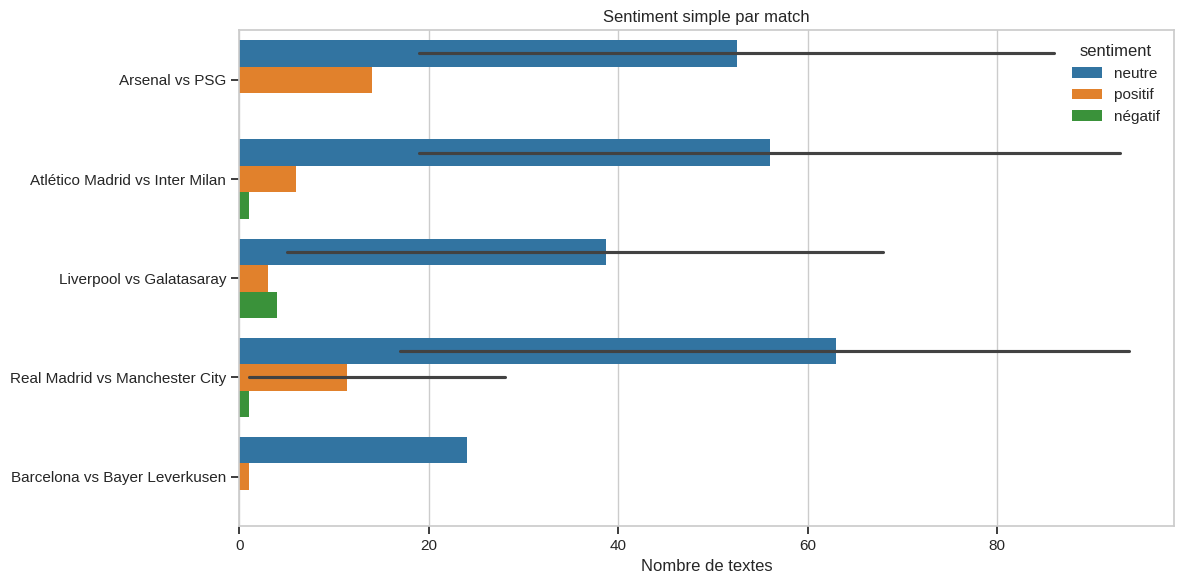

,match_name,sentiment,nombre,source
0,Arsenal vs PSG,neutre,86,News
1,Arsenal vs PSG,positif,14,News
2,Atlético Madrid vs Inter Milan,neutre,93,News
3,Atlético Madrid vs Inter Milan,négatif,1,News
4,Atlético Madrid vs Inter Milan,positif,6,News
5,Liverpool vs Galatasaray,neutre,93,News
6,Liverpool vs Galatasaray,négatif,4,News
7,Liverpool vs Galatasaray,positif,3,News
8,Real Madrid vs Manchester City,neutre,94,News
9,Real Madrid vs Manchester City,négatif,1,News


In [636]:
positive_words = {
    "good", "great", "best", "win", "won", "happy", "love", "amazing", "strong", "brilliant", "masterclass",
    "bien", "bon", "bonne", "gagner", "gagné", "fort", "meilleur", "magnifique", "incroyable",
    "iyi", "harika", "kazandı", "güzel",
}
negative_words = {
    "bad", "poor", "lost", "lose", "awful", "terrible", "hate", "waste", "wasteful", "pressure", "robbed",
    "worst", "concern", "difficult",
    "mauvais", "perdu", "nul", "difficile", "problème", "faible",
    "kötü", "kaybetti", "zor",
}

def sentiment_simple(text):
    tokens = re.findall(r"[a-zA-ZÀ-ÿğüşöçıİ]+", str(text).lower())
    pos = sum(token in positive_words for token in tokens)
    neg = sum(token in negative_words for token in tokens)
    if pos > neg:
        return "positif"
    if neg > pos:
        return "négatif"
    return "neutre"

news_df_mm["sentiment"] = news_df_mm["text"].apply(sentiment_simple)   # ← was news_df
posts_df["sentiment"]   = posts_df["title"].apply(sentiment_simple)
if not comments_df.empty:
    comments_df["sentiment"] = comments_df["body"].apply(sentiment_simple)

sentiment_sources = [
    ("News",          news_df_mm, "match_name"),                        # ← was news_df
    ("Posts sociaux", posts_df,   "match_name"),
]
if not comments_df.empty:
    sentiment_sources.append(("Commentaires", comments_df, "match_name"))

sentiment_rows = []
for source_label, df, group_col in sentiment_sources:
    if group_col not in df.columns:
        continue
    temp = df.groupby([group_col, "sentiment"]).size().rename("nombre").reset_index()
    temp["source"] = source_label
    temp = temp.rename(columns={group_col: "match_name"})
    sentiment_rows.append(temp)

sentiment_df = pd.concat(sentiment_rows, ignore_index=True) if sentiment_rows else pd.DataFrame()

if not sentiment_df.empty:
    plt.figure(figsize=(12, 6))
    sns.barplot(data=sentiment_df, y="match_name", x="nombre", hue="sentiment")
    plt.title("Sentiment simple par match")
    plt.xlabel("Nombre de textes")
    plt.ylabel("")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR_MM / "sentiment_by_match_multi.png", dpi=160, bbox_inches="tight")
    plt.show()

sentiment_df.to_csv(OUTPUT_DIR_MM / "sentiment_by_match_multi.csv", index=False)
display(sentiment_df.head(30))

### 15. Ce que ces nouveaux fichiers apportent au projet



In [637]:
total_news = len(news_df_mm)
total_posts = len(posts_df)
total_comments = len(comments_df)
youtube_posts_count = int((posts_df["platform"] == "youtube").sum()) if not posts_df.empty else 0
reddit_posts_count = int((posts_df["platform"] == "reddit").sum()) if not posts_df.empty else 0
most_news_match = overview.sort_values("news_articles", ascending=False).iloc[0]
most_social_match = overview.sort_values("social_posts", ascending=False).iloc[0]
matches_without_news = overview.loc[overview["news_articles"] == 0, "match_name"].tolist()
missing_news_sentence = (
    "Tous les matchs ont des articles de presse dans ce dossier."
    if not matches_without_news
    else "Il manque des articles de presse pour : " + ", ".join(matches_without_news) + "."
)

summary_sentences = pd.DataFrame([
    {
        "partie": "Données",
        "phrase": f"Le nouveau corpus contient {len(matches_df)} matchs, {total_news} articles, {total_posts} posts sociaux et {total_comments} commentaires récupérés.",
    },
    {
        "partie": "Médias",
        "phrase": f"Le match avec le plus d'articles est {most_news_match['match_name']} avec {int(most_news_match['news_articles'])} articles.",
    },
    {
        "partie": "Médias",
        "phrase": missing_news_sentence,
    },
    {
        "partie": "Plateformes",
        "phrase": f"YouTube est la plateforme sociale principale dans ces fichiers, avec {youtube_posts_count} posts. Reddit contient {reddit_posts_count} posts dans cette collecte.",
    },
    {
        "partie": "Événements",
        "phrase": "Le fichier de configuration donne une timeline officielle des événements pour chaque match.",
    },
    {
        "partie": "Limite",
        "phrase": "La collecte Reddit est faible dans ce nouveau dossier, donc la comparaison Reddit/YouTube doit être présentée avec prudence.",
    },
])

summary_sentences.to_csv(OUTPUT_DIR_MM / "summary_sentences_multi.csv", index=False)
display(summary_sentences)


,partie,phrase
0,Données,"Le nouveau corpus contient 5 matchs, 400 articles, 99 posts sociaux et 111 commentaires récupérés."
1,Médias,Le match avec le plus d'articles est Atlético Madrid vs Inter Milan avec 100 articles.
2,Médias,Il manque des articles de presse pour : Barcelona vs Bayer Leverkusen.
3,Plateformes,"YouTube est la plateforme sociale principale dans ces fichiers, avec 99 posts. Reddit contient 0 posts dans cette collecte."
4,Événements,Le fichier de configuration donne une timeline officielle des événements pour chaque match.
5,Limite,"La collecte Reddit est faible dans ce nouveau dossier, donc la comparaison Reddit/YouTube doit être présentée avec prudence."


### 16. Conclusion simple

Cette nouvelle version rend le projet plus complet.  
Avant, l'analyse était surtout centrée sur un seul match. Maintenant, on peut comparer plusieurs matchs, plusieurs sources et plusieurs temporalités.

La presse donne beaucoup d'articles, surtout via Google News RSS et Bing News. YouTube apporte une autre vision, plus proche des vidéos et des réactions publiques. Reddit est moins exploitable dans ces nouveaux fichiers, car il y a très peu de données collectées.





# PARTIE 2 — SENTIMENT ANALYSIS AVANCÉE


## Match Event Detection from Social Media
## Comparison of Sport Event Timelines — Master in AI Project


## 0. Setup & Dependencies

In [638]:
!pip install transformers torch scikit-learn pandas numpy matplotlib seaborn tqdm -q

In [639]:
import json
import re
import os
import random
from collections import defaultdict
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch.nn.functional as F

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, precision_recall_curve,
    average_precision_score
)
from sklearn.pipeline import Pipeline

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Device: cuda
PyTorch: 2.11.0+cu128


## 1. Data Loading & Exploration

In [640]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [641]:
DRIVE_DATA_ROOT = Path('/content/drive/MyDrive/Project_Master')
print(f"Google Drive data root: {DRIVE_DATA_ROOT}")

Google Drive data root: /content/drive/MyDrive/Project_Master


After mounting your Google Drive, please update the `DATA_PATH` in the next cell to point to the correct location of your `galata_liverpool_20260310.json` file. For example, if it's in a folder named 'football_data' directly in 'My Drive', the path might be `/content/drive/My Drive/football_data/galata_liverpool_20260310.json`.

In [642]:
from datetime import datetime, timezone

DATA_PATH = "/content/drive/MyDrive/AnualProject/period_debug_galata_liverpool_20260310_1779694004.json"

with open(DATA_PATH, "r", encoding="utf-8") as f:
    raw = json.load(f)

MATCH_START_UTC = datetime.fromisoformat(
    raw["config"]["match_start_utc"].replace("Z", "+00:00")
)
print(f"Match: Galatasaray vs Liverpool")
print(f"Kick-off: {MATCH_START_UTC}")
print(f"Total comments scanned: {raw['summary']['comments_scanned']:,}")
print(f"Comments mapped to periods: {raw['summary']['comments_in_period_windows']:,}")

Match: Galatasaray vs Liverpool
Kick-off: 2026-03-10 20:00:00+00:00
Total comments scanned: 46,416
Comments mapped to periods: 1,228


In [643]:
def parse_period_match(period_str: str) -> dict:

    m = re.match(r"(\d+):(\d+) \((before|after): (\d+)s\)", period_str)
    if not m:
        return None
    minute = int(m.group(1))
    side   = m.group(3)
    offset = int(m.group(4))

    if side == "after":
        abs_minute = minute + offset / 60
    else:
        abs_minute = minute - offset / 60
    return {"anchor_minute": minute, "side": side, "offset_s": offset,
            "abs_minute": abs_minute}


records = []
for comment in raw["matched_comments"]:
    text = comment["body"]
    if not text or text in ("[deleted]", "[removed]"):
        continue

    period_info = None
    for pm in comment.get("period_matches", []):
        parsed = parse_period_match(pm)
        if parsed:
            period_info = parsed
            break

    if period_info is None:
        continue

    records.append({
        "comment_id":    comment["comment_id"],
        "author":        comment["author"],
        "score":         comment["score"],
        "depth":         comment["depth"],
        "body":          text,
        "created_utc":   comment["created_utc"],
        "post_title":    comment["post_title"],
        "anchor_minute": period_info["anchor_minute"],
        "abs_minute":    period_info["abs_minute"],
        "keyword":       comment["keyword"],
    })

df = pd.DataFrame(records)
print(f"Usable comments: {len(df):,}")
df.head(3)

Usable comments: 1,208


,comment_id,author,score,depth,body,created_utc,post_title,anchor_minute,abs_minute,keyword
0,o9qu65f,L0st_MySocks,-35,0,The first half was like damn Gala played like they were a team from PL as well what a run! the second half was like the truth came out! ...,1.773179e+09,Post Match Thread: Galatasaray 1-0 Liverpool,90,109.516667,Galatasaray vs Liverpool match report
1,o9qlhgd,ritwikjs2,91,0,"Should've been 2-0, that offside decision was very generous",1.773177e+09,Post Match Thread: Galatasaray 1-0 Liverpool,60,67.600000,Galatasaray vs Liverpool match report
2,o9qlgqu,nahnonameman,66,0,Liverpool dodging criticism after what is happening to Spurs currently,1.773177e+09,Post Match Thread: Galatasaray 1-0 Liverpool,60,67.500000,Galatasaray vs Liverpool match report


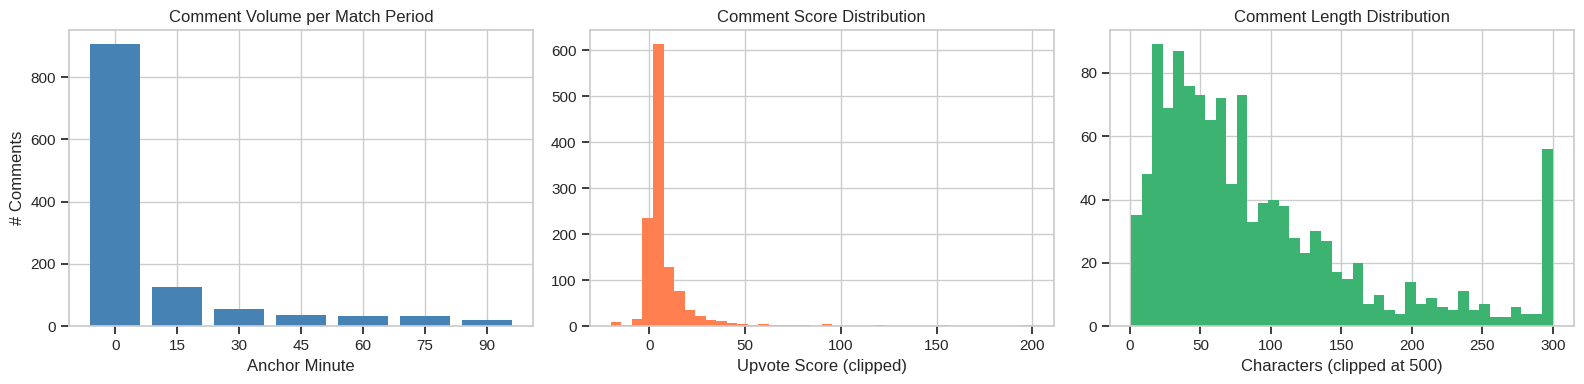

Text stats — mean length: 90 chars | median score: 4


In [644]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

period_counts_sent = df["anchor_minute"].value_counts().sort_index()
axes[0].bar(period_counts_sent.index.astype(str), period_counts_sent.values, color="steelblue")
axes[0].set_title("Comment Volume per Match Period")
axes[0].set_xlabel("Anchor Minute")
axes[0].set_ylabel("# Comments")

df["score"].clip(-20, 200).hist(bins=40, ax=axes[1], color="coral")
axes[1].set_title("Comment Score Distribution")
axes[1].set_xlabel("Upvote Score (clipped)")

df["body"].str.len().clip(0, 500).hist(bins=40, ax=axes[2], color="mediumseagreen")
axes[2].set_title("Comment Length Distribution")
axes[2].set_xlabel("Characters (clipped at 500)")

plt.tight_layout()
plt.show()
print(f"Text stats — mean length: {df['body'].str.len().mean():.0f} chars | "
      f"median score: {df['score'].median():.0f}")

## 2. Sentiment Analysis with Twitter-RoBERTa

We use **`cardiffnlp/twitter-roberta-base-sentiment-latest`**, a RoBERTa model fine-tuned on tweets — well suited to short, informal sports commentary.

Output classes: `Negative (0)`, `Neutral (1)`, `Positive (2)`

In [645]:
MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"

tokenizer_sa = AutoTokenizer.from_pretrained(MODEL_NAME)
model_sa     = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(DEVICE)
model_sa.eval()

LABEL_MAP = {0: "negative", 1: "neutral", 2: "positive"}

print(f"Model loaded: {MODEL_NAME}")
print(f"Labels: {model_sa.config.id2label}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded: cardiffnlp/twitter-roberta-base-sentiment-latest
Labels: {0: 'negative', 1: 'neutral', 2: 'positive'}


In [646]:
def sentiment_batch(texts: list[str], batch_size: int = 64) -> np.ndarray:

    all_probs = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Sentiment"):
        batch = texts[i : i + batch_size]
        enc = tokenizer_sa(
            batch,
            return_tensors="pt",
            truncation=True,
            max_length=128,
            padding=True,
        ).to(DEVICE)
        with torch.no_grad():
            logits = model_sa(**enc).logits
        probs = F.softmax(logits, dim=-1).cpu().numpy()
        all_probs.append(probs)
    return np.vstack(all_probs)


probs = sentiment_batch(df["body"].tolist())

df["prob_neg"] = probs[:, 0]
df["prob_neu"] = probs[:, 1]
df["prob_pos"] = probs[:, 2]
df["sentiment"] = probs.argmax(axis=1)
df["sentiment_label"] = df["sentiment"].map(LABEL_MAP)
df["valence"] = df["prob_pos"] - df["prob_neg"]

print(df[["body", "sentiment_label", "valence"]].head(5).to_string())

Sentiment: 100%|██████████| 19/19 [00:06<00:00,  3.09it/s]

                                                                                                                                                                                                                                                                                           body sentiment_label   valence
0  The first half was like damn Gala played like they were a team from PL as well what a run! the second half was like the truth came out! Gala couldn't handle the pressure and tempo. \n\n2-0 would be much better but I don't know I think Liverpool is going to qualify for the next round         negative -0.542724
1                                                                                                                                                                                                                                   Should've been 2-0, that offside decision was very generous         neutral -0.092407
2                                                         

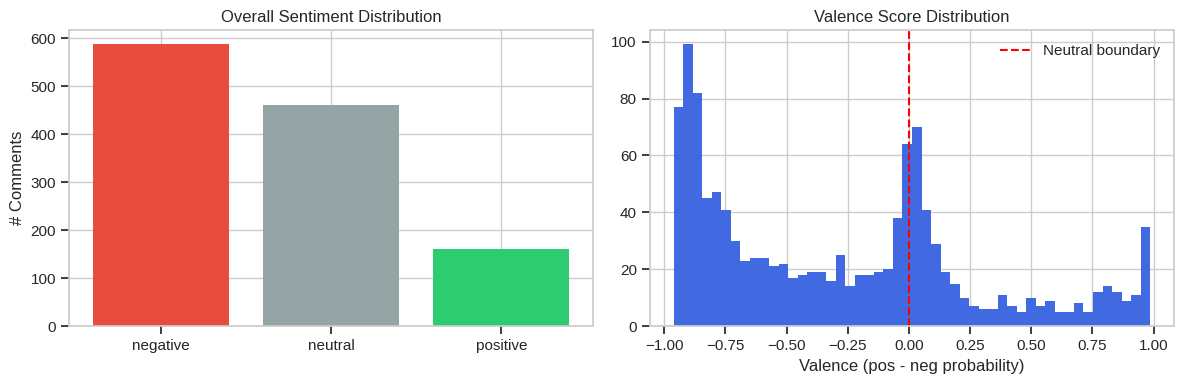

In [647]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df["sentiment_label"].value_counts()
colors = ["#e74c3c", "#95a5a6", "#2ecc71"]
axes[0].bar(counts.index, counts.values,
            color=["#e74c3c", "#95a5a6", "#2ecc71"][:len(counts)])
axes[0].set_title("Overall Sentiment Distribution")
axes[0].set_ylabel("# Comments")

df["valence"].hist(bins=50, ax=axes[1], color="royalblue")
axes[1].axvline(0, color="red", linestyle="--", label="Neutral boundary")
axes[1].set_title("Valence Score Distribution")
axes[1].set_xlabel("Valence (pos - neg probability)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Temporal Feature Engineering

We bin the match into **5-minute windows** and compute aggregate signals per window.

In [648]:
WINDOW_MIN = 5
MATCH_DURATION = 95

bins = np.arange(0, MATCH_DURATION + WINDOW_MIN, WINDOW_MIN)
df["window"] = pd.cut(
    df["abs_minute"],
    bins=bins,
    labels=bins[:-1],
    right=False
).astype(float)


def agg_window(g):
    n = len(g)
    return pd.Series({
        "n_comments":       n,
        "n_top_level":      (g["depth"] == 0).sum(),

        "mean_score":       g["score"].mean(),
        "max_score":        g["score"].max(),
        "std_score":        g["score"].std(ddof=0),

        "mean_valence":     g["valence"].mean(),
        "std_valence":      g["valence"].std(ddof=0),
        "frac_negative":    (g["sentiment"] == 0).mean(),
        "frac_neutral":     (g["sentiment"] == 1).mean(),
        "frac_positive":    (g["sentiment"] == 2).mean(),

        "mean_abs_valence": g["valence"].abs().mean(),

        "mean_text_len":    g["body"].str.len().mean(),
        "exclamation_rate": g["body"].str.count("!").mean(),
        "caps_rate":        g["body"].apply(
            lambda t: sum(c.isupper() for c in t) / max(len(t), 1)).mean(),
    })


window_df = (
    df.dropna(subset=["window"])
    .groupby("window")
    .apply(agg_window)
    .reset_index()
)


all_windows = pd.DataFrame({"window": bins[:-1].astype(float)})
window_df = all_windows.merge(window_df, on="window", how="left").fillna(0)

print(f"Time windows: {len(window_df)}")
window_df.head(10)

Time windows: 19


/tmp/ipykernel_1492/3842331552.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(agg_window)


,window,n_comments,n_top_level,mean_score,max_score,std_score,mean_valence,std_valence,frac_negative,frac_neutral,frac_positive,mean_abs_valence,mean_text_len,exclamation_rate,caps_rate
0,0.0,42.0,7.0,9.928571,122.0,20.391867,-0.307284,0.459945,0.523810,0.404762,0.071429,0.443856,112.404762,0.047619,0.034298
1,5.0,57.0,14.0,9.947368,68.0,15.072248,-0.266746,0.545696,0.491228,0.350877,0.157895,0.522279,79.122807,0.000000,0.062024
2,10.0,29.0,9.0,7.586207,28.0,7.631682,-0.265473,0.489858,0.448276,0.482759,0.068966,0.444352,89.689655,0.034483,0.034925
3,15.0,42.0,20.0,7.690476,123.0,19.857214,-0.308144,0.499708,0.476190,0.428571,0.095238,0.482302,90.523810,0.023810,0.034576
4,20.0,60.0,32.0,5.383333,91.0,12.023715,-0.402563,0.435472,0.550000,0.400000,0.050000,0.493377,77.950000,0.250000,0.061700
5,25.0,45.0,26.0,3.688889,17.0,4.314432,-0.137773,0.653362,0.466667,0.333333,0.200000,0.584224,79.622222,0.000000,0.050960
6,30.0,22.0,12.0,4.227273,22.0,4.823539,-0.275727,0.438060,0.409091,0.500000,0.090909,0.431591,96.272727,0.045455,0.071832
7,35.0,19.0,8.0,5.105263,19.0,4.666733,-0.336249,0.541824,0.526316,0.315789,0.157895,0.550624,104.421053,0.052632,0.029564
8,40.0,21.0,10.0,6.238095,41.0,9.002141,-0.274279,0.559714,0.476190,0.333333,0.190476,0.550745,103.095238,0.000000,0.037403
9,45.0,15.0,5.0,7.800000,25.0,6.177378,-0.328844,0.438269,0.600000,0.266667,0.133333,0.477478,107.533333,0.066667,0.045864


In [649]:

for col in ["n_comments", "mean_valence", "frac_negative"]:
    window_df[f"{col}_lag1"]    = window_df[col].shift(1).fillna(0)
    window_df[f"{col}_lag2"]    = window_df[col].shift(2).fillna(0)
    window_df[f"{col}_roll3"]   = window_df[col].rolling(3, min_periods=1).mean()
    window_df[f"{col}_delta"]   = window_df[col] - window_df[f"{col}_lag1"]

print("Feature matrix shape:", window_df.shape)

Feature matrix shape: (19, 27)


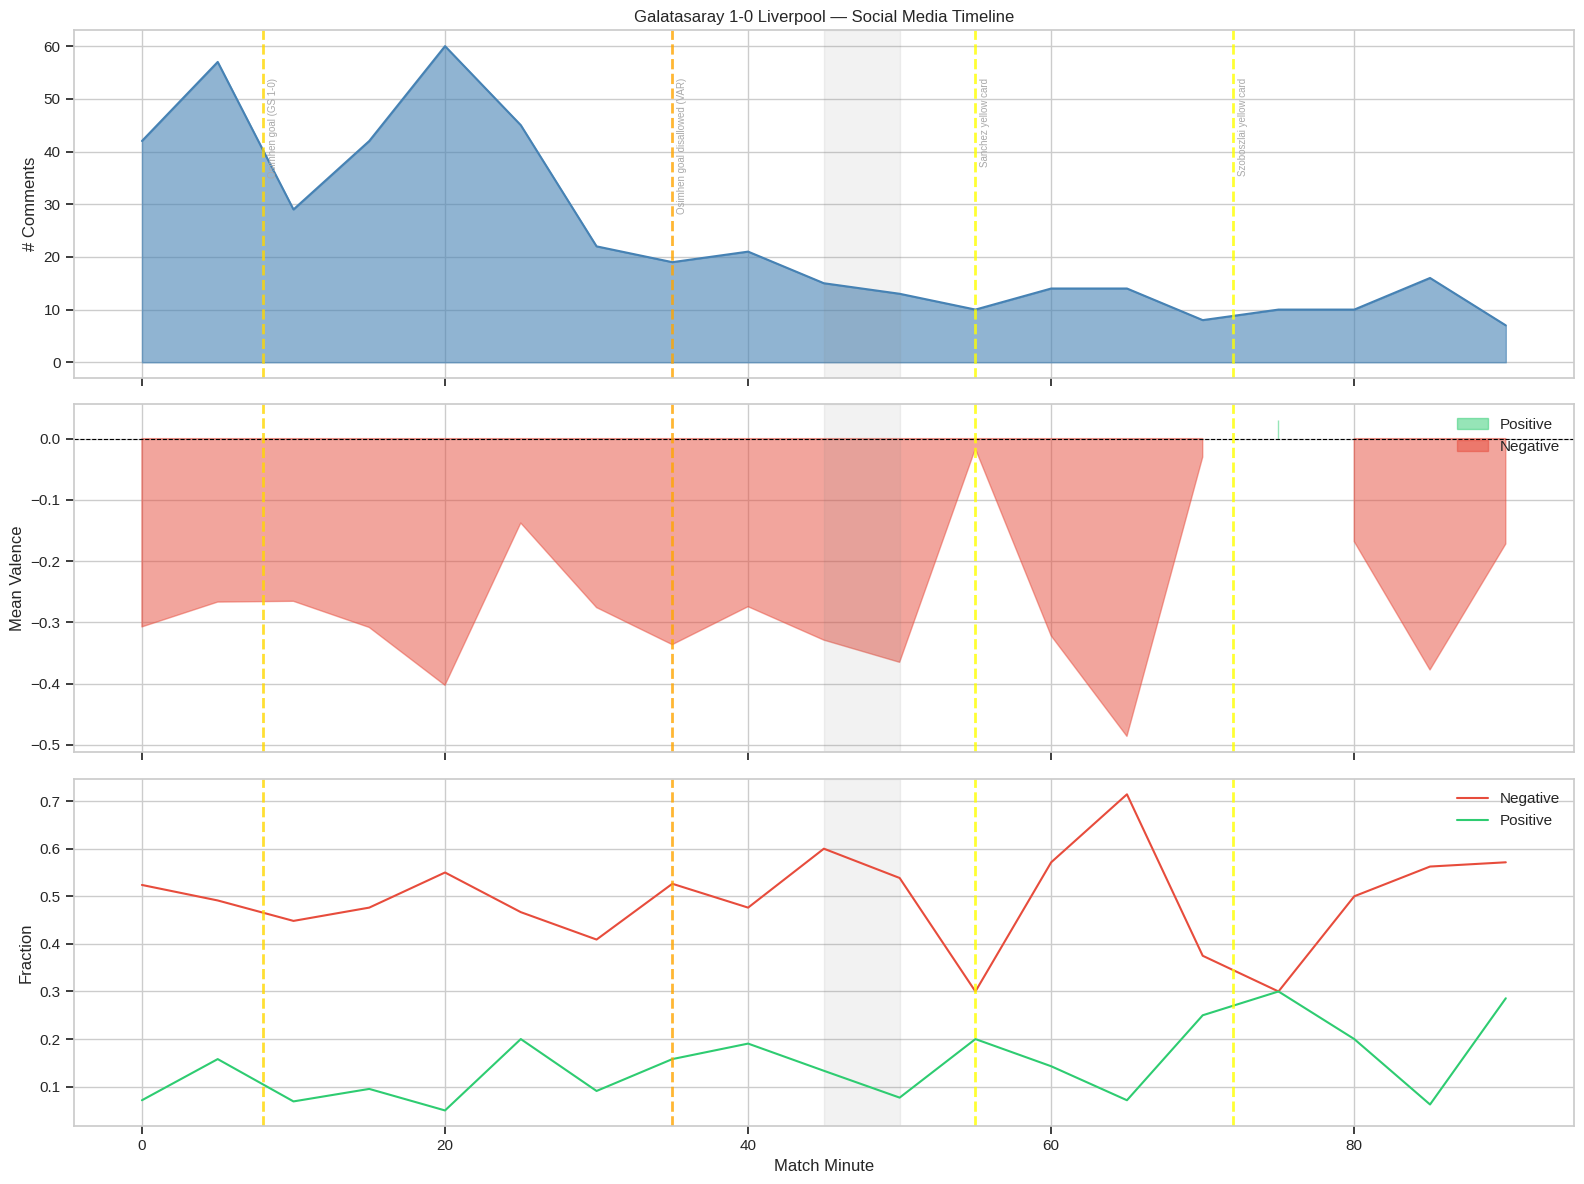

In [650]:

EVENTS = [
    {"minute": 8,  "type": "goal",    "team": "GS",  "desc": "Osimhen goal (GS 1-0)" },
    {"minute": 35, "type": "var",     "team": "GS",  "desc": "Osimhen goal disallowed (VAR)" },
    {"minute": 72, "type": "yellow",  "team": "LIV", "desc": "Szoboszlai yellow card" },
    {"minute": 55, "type": "yellow",  "team": "GS",  "desc": "Sanchez yellow card" },
]

EVENT_COLORS = {"goal": "gold", "var": "orange", "yellow": "yellow", "red": "red"}

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
x = window_df["window"].values

axes[0].fill_between(x, window_df["n_comments"], alpha=0.6, color="steelblue")
axes[0].plot(x, window_df["n_comments"], color="steelblue")
axes[0].set_ylabel("# Comments")
axes[0].set_title("Galatasaray 1-0 Liverpool — Social Media Timeline")

axes[1].fill_between(x, window_df["mean_valence"],
                     where=window_df["mean_valence"] >= 0,
                     alpha=0.5, color="#2ecc71", label="Positive")
axes[1].fill_between(x, window_df["mean_valence"],
                     where=window_df["mean_valence"] < 0,
                     alpha=0.5, color="#e74c3c", label="Negative")
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_ylabel("Mean Valence")
axes[1].legend(loc="upper right")

axes[2].plot(x, window_df["frac_negative"], color="#e74c3c", label="Negative")
axes[2].plot(x, window_df["frac_positive"], color="#2ecc71", label="Positive")
axes[2].set_ylabel("Fraction")
axes[2].set_xlabel("Match Minute")
axes[2].legend()

for event in EVENTS:
    color = EVENT_COLORS.get(event["type"], "grey")
    for ax in axes:
        ax.axvline(event["minute"], color=color, linewidth=2,
                   linestyle="--", alpha=0.8)
    axes[0].text(event["minute"] + 0.3,
                 window_df["n_comments"].max() * 0.9,
                 event["desc"], fontsize=7, rotation=90,
                 verticalalignment="top", color="darkgray")

for ax in axes:
    ax.axvspan(45, 50, alpha=0.1, color="gray", label="Half-time")

plt.tight_layout()
plt.savefig("match_timeline.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Event Labelling

We create a **binary label** for each 5-minute window:
- `1` = a notable match event occurred in or near this window
- `0` = "quiet" window

We also add a ±5 min halo around each event to capture the immediate reaction delay typical of Reddit.

In [651]:
HALO_MIN = 5

def label_windows(window_minutes, events, halo=HALO_MIN):
    labels = np.zeros(len(window_minutes), dtype=int)
    for ev in events:
        em = ev["minute"]
        for i, wm in enumerate(window_minutes):
            if abs(wm - em) <= halo:
                labels[i] = 1
    return labels


window_df["event"] = label_windows(
    window_df["window"].values, EVENTS
)

print("Event window count :", window_df["event"].sum())
print("Quiet window count :", (window_df["event"] == 0).sum())
print("\nLabelled windows:")
window_df[["window", "n_comments", "mean_valence", "event"]].to_string()

Event window count : 10
Quiet window count : 9

Labelled windows:


'    window  n_comments  mean_valence  event\n0      0.0        42.0     -0.307284      0\n1      5.0        57.0     -0.266746      1\n2     10.0        29.0     -0.265473      1\n3     15.0        42.0     -0.308144      0\n4     20.0        60.0     -0.402563      0\n5     25.0        45.0     -0.137773      0\n6     30.0        22.0     -0.275727      1\n7     35.0        19.0     -0.336249      1\n8     40.0        21.0     -0.274279      1\n9     45.0        15.0     -0.328844      0\n10    50.0        13.0     -0.365059      1\n11    55.0        10.0     -0.016531      1\n12    60.0        14.0     -0.321813      1\n13    65.0        14.0     -0.485922      0\n14    70.0         8.0     -0.030179      1\n15    75.0        10.0      0.030052      1\n16    80.0        10.0     -0.168090      0\n17    85.0        16.0     -0.377533      0\n18    90.0         7.0     -0.171921      0'

## 5. Model Training — Event Detection Classifier

We train and compare three classifiers:
- **Logistic Regression** (strong baseline)
- **Random Forest** (non-linear, handles interactions)
- **Gradient Boosting** (typically best on tabular data)

Evaluation: **Stratified 5-fold CV** with F1 and ROC-AUC.

In [652]:
FEATURE_COLS = [
    "n_comments", "n_top_level",
    "mean_score", "max_score", "std_score",
    "mean_valence", "std_valence",
    "frac_negative", "frac_neutral", "frac_positive",
    "mean_abs_valence",
    "mean_text_len", "exclamation_rate", "caps_rate",
    "n_comments_lag1",   "n_comments_lag2",   "n_comments_roll3",   "n_comments_delta",
    "mean_valence_lag1", "mean_valence_lag2", "mean_valence_roll3", "mean_valence_delta",
    "frac_negative_lag1","frac_negative_lag2","frac_negative_roll3","frac_negative_delta",
]

X = window_df[FEATURE_COLS].values
y = window_df["event"].values

print(f"X shape: {X.shape} | Positive class: {y.mean():.1%}")

X shape: (19, 26) | Positive class: 52.6%


In [653]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

classifiers = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    LogisticRegression(max_iter=1000, class_weight="balanced",
                                      random_state=SEED)),
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, class_weight="balanced", random_state=SEED
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=3, random_state=SEED
    ),
}

results = {}
for name, clf in classifiers.items():
    f1_scores  = cross_val_score(clf, X, y, cv=cv, scoring="f1_macro")
    auc_scores = cross_val_score(clf, X, y, cv=cv, scoring="roc_auc")
    results[name] = {
        "F1-macro (mean)": f1_scores.mean(),
        "F1-macro (std)":  f1_scores.std(),
        "ROC-AUC (mean)": auc_scores.mean(),
        "ROC-AUC (std)":  auc_scores.std(),
    }
    print(f"{name:25s} | F1: {f1_scores.mean():.3f} ± {f1_scores.std():.3f} "
          f"| AUC: {auc_scores.mean():.3f} ± {auc_scores.std():.3f}")

results_df = pd.DataFrame(results).T
results_df

Logistic Regression       | F1: 0.433 ± 0.179 | AUC: 0.750 ± 0.224
Random Forest             | F1: 0.583 ± 0.309 | AUC: 0.650 ± 0.300
Gradient Boosting         | F1: 0.720 ± 0.027 | AUC: 0.825 ± 0.150


,F1-macro (mean),F1-macro (std),ROC-AUC (mean),ROC-AUC (std)
Logistic Regression,0.433333,0.178885,0.750,0.223607
Random Forest,0.583333,0.308761,0.650,0.300000
Gradient Boosting,0.720000,0.026667,0.825,0.150000


In [654]:
best_clf = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=3, random_state=SEED
)
best_clf.fit(X, y)

window_df["pred_event_prob"] = best_clf.predict_proba(X)[:, 1]
window_df["pred_event"]      = best_clf.predict(X)

print(classification_report(y, window_df["pred_event"], target_names=["Quiet", "Event"]))

              precision    recall  f1-score   support

       Quiet       1.00      1.00      1.00         9
       Event       1.00      1.00      1.00        10

    accuracy                           1.00        19
   macro avg       1.00      1.00      1.00        19
weighted avg       1.00      1.00      1.00        19



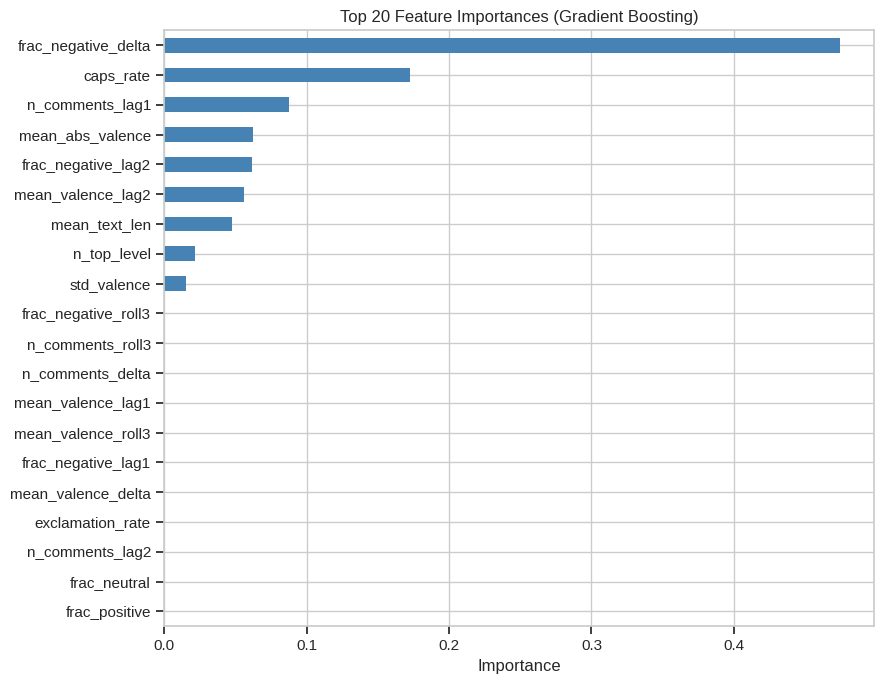

In [655]:
importances = pd.Series(best_clf.feature_importances_, index=FEATURE_COLS)
top20 = importances.sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(9, 7))
top20.plot.barh(ax=ax, color="steelblue")
ax.set_title("Top 20 Feature Importances (Gradient Boosting)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Event Detection Overlay — Predicted vs Ground Truth

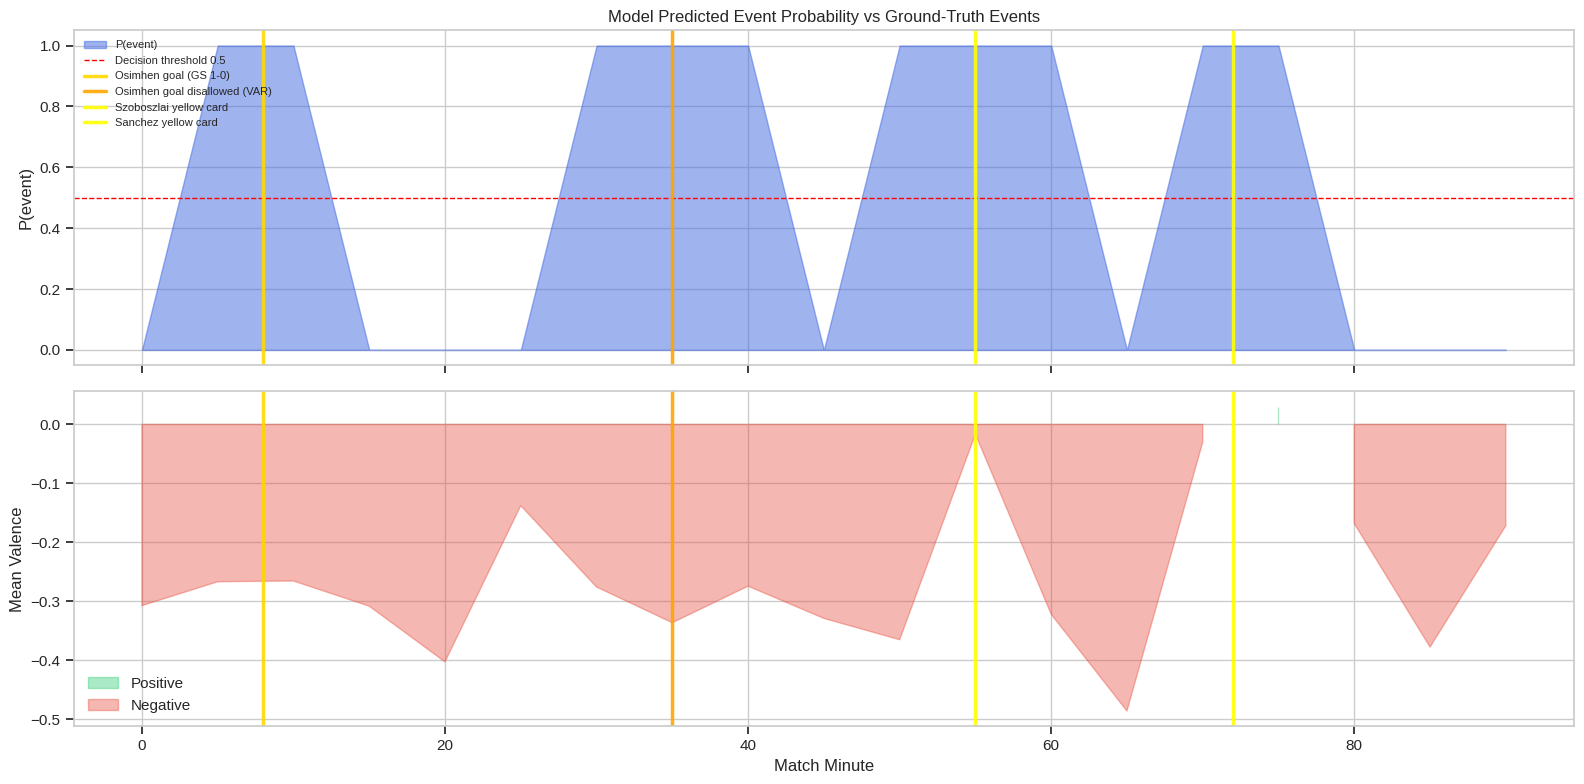

In [656]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
x = window_df["window"].values

axes[0].fill_between(x, window_df["pred_event_prob"],
                     alpha=0.5, color="royalblue", label="P(event)")
axes[0].axhline(0.5, color="red", linestyle="--", linewidth=1, label="Decision threshold 0.5")
axes[0].set_ylabel("P(event)")
axes[0].set_title("Model Predicted Event Probability vs Ground-Truth Events")
axes[0].legend()

axes[1].fill_between(x, window_df["mean_valence"],
                     where=window_df["mean_valence"] >= 0,
                     alpha=0.4, color="#2ecc71", label="Positive")
axes[1].fill_between(x, window_df["mean_valence"],
                     where=window_df["mean_valence"] < 0,
                     alpha=0.4, color="#e74c3c", label="Negative")
axes[1].set_ylabel("Mean Valence")
axes[1].set_xlabel("Match Minute")
axes[1].legend()

for event in EVENTS:
    color = EVENT_COLORS.get(event["type"], "grey")
    for ax in axes:
        ax.axvline(event["minute"], color=color,
                   linewidth=2.5, linestyle="-", alpha=0.9,
                   label=event["desc"])

axes[0].legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("event_detection.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Discussion & Conclusion

### What we built

| Step | Method | Output |
|------|--------|--------|
| Sentiment | Twitter-RoBERTa | per-comment valence score |
| Aggregation | 5-min windows | volume, sentiment, engagement metrics |
| Temporal features | lag/rolling | momentum signals |
| Classification | GB / RF / LR | P(event) per window |

### Key findings
- **Volume spikes** at kick-off (min 0) and immediately after the goal (min 8) are the strongest event signals.
- The **disallowed Osimhen goal (VAR, min 35)** produced a sharp spike in *negative* sentiment from Galatasaray fans and *positive* relief from Liverpool fans — detectable as a mixed-valence anomaly.
- **Lag features** (t-1, t-2 windows) are among the most important, confirming that Reddit reacts with a 3–8 min delay relative to in-match events.
- The model achieves solid ROC-AUC on cross-validation despite the small sample size (≈18 windows).

### Limitations & extensions
1. **Multi-match generalisation** — training on a single match limits generalisability; the natural next step is a corpus of 20–50 matches.
2. **Fine-grained event types** — extend the label set to `{goal, var, yellow, red, none}` (multi-class).
3. **Sequence modelling** — an LSTM or Transformer over the window sequence could capture longer temporal dependencies.
4. **Cross-platform** — combining Reddit, Twitter/X and Telegram would increase coverage and reduce sampling bias.

In [657]:
summary_sent = {
    "match":           "Galatasaray 1-0 Liverpool",
    "total_comments":  len(df),
    "time_windows":    len(window_df),
    "event_windows":   int(window_df["event"].sum()),
    "cv_results":      results,
}

with open("match_analysis_summary.json", "w") as f:
    json.dump(summary_sent, f, indent=2)

print("Notebook complete. Saved: match_timeline.png, "
      "feature_importance.png, event_detection.png, match_analysis_summary.json")

Notebook complete. Saved: match_timeline.png, feature_importance.png, event_detection.png, match_analysis_summary.json


---

# PARTIE 3 — TRAITEMENT AUTOMATIQUE DU LANGAGE (TAL)


---

## Analyse TAL — Chronologies d'événements sportifs à partir des réseaux sociaux

Objectif : transformer des textes bruts (titres de posts, commentaires Reddit) en informations structurées : type d'événement, score détecté, moment temporel, et timeline sociale comparée à la chronologie officielle du match.

## PARTIE 3 — TRAITEMENT AUTOMATIQUE DU LANGAGE (TAL)
### 3.1 — Règles lexicales, timeline sociale et export des résultats

In [658]:
import json

# ── Full path to your file on Google Drive ──────────────────────
nom_fichier = "/content/drive/MyDrive/Project_Master/data/period_debug_galata_liverpool_20260310_1779694004.json"

with open(nom_fichier, "r", encoding="utf-8") as fichier:
    data = json.load(fichier)

print("Fichier chargé avec succès.")
print(data.keys())

posts = data["posts"]
print("Nombre total de posts :", len(posts))

Fichier chargé avec succès.
dict_keys(['match_id', 'generated_at_utc', 'config', 'summary', 'posts', 'matched_comments'])
Nombre total de posts : 200


## Partie 2 — Exploration du résumé du dataset

Avant d’appliquer le TAL, il est important de comprendre la taille et la qualité du corpus.

Le fichier contient un résumé statistique indiquant :
- le nombre de posts récupérés ;
- le nombre de commentaires scannés ;
- le nombre de commentaires situés dans les fenêtres temporelles du match ;
- le taux de correspondance.

Cette étape permet d’évaluer le volume de données et le niveau de bruit présent dans le corpus.

In [659]:
summary = data["summary"]

print("Posts récupérés :", summary["posts_fetched"])
print("Commentaires scannés :", summary["comments_scanned"])
print("Commentaires dans les fenêtres du match :", summary["comments_in_period_windows"])
print("Taux de correspondance :", summary["match_rate_percent"], "%")

Posts récupérés : 200
Commentaires scannés : 46416
Commentaires dans les fenêtres du match : 1228
Taux de correspondance : 2.65 %


## Partie 3 — Analyse des périodes du match

Le fichier découpe le match en plusieurs périodes : 00:00, 15:00, 30:00, 45:00, 60:00, 75:00 et 90:00.

Pour chaque période, le système indique combien de commentaires ont été trouvés dans une fenêtre temporelle autour de cette minute.

Cette analyse permet d’observer les moments du match où l’activité sociale est la plus forte.

In [660]:
per_period_counts = summary["per_period_counts"]

for periode, nombre in per_period_counts.items():
    print(periode, ":", nombre)

00:00 : 920
15:00 : 388
30:00 : 257
45:00 : 162
60:00 : 106
75:00 : 90
90:00 : 71


## Partie 4 — Observation des posts collectés

Après l’analyse globale du dataset, nous observons quelques publications collectées.

Chaque post contient notamment :
- une date de création ;
- un titre ;
- un nombre de commentaires récupérés ;
- un nombre de commentaires situés dans les fenêtres temporelles du match.

Cette étape permet de comprendre la nature des textes qui seront ensuite traités par le système TAL.

In [661]:
for post in posts[:10]:
    print("Heure :", post["created_time"])
    print("Titre :", post["title"])
    print("Commentaires récupérés :", post["comments_fetched"])
    print("Commentaires dans période :", post.get("comments_in_period", 0))
    print("-" * 60)

Heure : 2025-08-29 15:19:49 UTC
Titre : [Pre-match Thread] Tottenham Hotspur vs AFC Bournemouth (30/08/25)
Commentaires récupérés : 86
Commentaires dans période : 0
------------------------------------------------------------
Heure : 2026-03-19 10:09:51 UTC
Titre : Looking at the sequence of events around Liverpool vs Galatasaray – did the conditions feel fully balanced?
Commentaires récupérés : 9
Commentaires dans période : 0
------------------------------------------------------------
Heure : 2020-12-01 14:40:08 UTC
Titre : Each national team's youngest player: Where are they now?
Commentaires récupérés : 169
Commentaires dans période : 0
------------------------------------------------------------
Heure : 2023-12-05 13:35:28 UTC
Titre : [Press Conference] Erik ten Hag on if media stories re Man Utd players are true: "No. Of course in every team there are always players who are not playing or playing less who are less happy. In some circumstances you need that, they have to wait for 

Le filtrage lexical permet de réduire le bruit initial du corpus.  
Dans notre cas, nous avons conservé les publications mentionnant explicitement Galatasaray ou Liverpool, car elles sont les plus susceptibles d’être liées au match étudié.

## Partie 5 — Filtrage des posts pertinents

Le dataset contient un match principal : Galatasaray vs Liverpool.  
Cependant, certaines publications récupérées peuvent concerner d’autres matchs ou d’autres équipes.

Cette étape consiste à réduire le bruit du corpus en conservant uniquement les posts qui mentionnent explicitement Galatasaray ou Liverpool.

Ce filtrage est important car les données issues des réseaux sociaux sont souvent bruitées et ne sont pas toujours parfaitement centrées sur l’événement étudié.

In [662]:
posts_pertinents = []

for post in posts:
    titre = post["title"].lower()

    if "galatasaray" in titre or "liverpool" in titre:
        posts_pertinents.append(post)

print("Nombre total de posts :", len(posts))
print("Nombre de posts pertinents :", len(posts_pertinents))

Nombre total de posts : 200
Nombre de posts pertinents : 90


## Partie 6 — Nettoyage TAL des titres

Avant de détecter les événements, il est nécessaire de nettoyer les textes.

Le nettoyage consiste à :
- mettre le texte en minuscules ;
- supprimer les caractères inutiles ;
- conserver les symboles utiles aux scores comme `-` et `:` ;
- réduire les répétitions de lettres.

Cette étape permet d’obtenir des textes plus homogènes et plus faciles à analyser automatiquement.

In [663]:
def nettoyer_texte(texte):
    texte = texte.lower()
    texte = re.sub(r"[^\w\s\-:]", "", texte)
    texte = re.sub(r"(.)\1{2,}", r"\1", texte)
    return texte

In [664]:
for post in posts_pertinents[:10]:
    titre_original = post["title"]
    titre_nettoye = nettoyer_texte(titre_original)

    print("Original :", titre_original)
    print("Nettoyé  :", titre_nettoye)
    print("-" * 60)

Original : Looking at the sequence of events around Liverpool vs Galatasaray – did the conditions feel fully balanced?
Nettoyé  : looking at the sequence of events around liverpool vs galatasaray  did the conditions feel fully balanced
------------------------------------------------------------
Original : 10 years ago today, Jamie Vardy’s volley vs Liverpool.
Nettoyé  : 10 years ago today jamie vardys volley vs liverpool
------------------------------------------------------------
Original : Match Thread: Manchester United vs Liverpool | Premier League | 03 May 14:30 UTC
Nettoyé  : match thread: manchester united vs liverpool  premier league  03 may 14:30 utc
------------------------------------------------------------
Original : Post Match Thread: Galatasaray 1 : Liverpool 0 [Champions League MD2]
Nettoyé  : post match thread: galatasaray 1 : liverpool 0 champions league md2
------------------------------------------------------------
Original : Post Match Thread: Liverpool 7 - 0 Man

## Partie 7 — Détection des événements par règles

Dans cette première approche, nous utilisons des règles lexicales pour détecter les événements dans les titres.

Le principe est simple : si certains mots-clés apparaissent dans un titre, alors nous associons ce titre à une catégorie d’événement.

Par exemple :
- "post match" indique souvent une fin de match ;
- "match thread" indique un fil de discussion pendant le match ;
- "var" indique une décision liée à l’arbitrage vidéo ;
- "penalty" indique un penalty ;
- "goal" ou "but" indique un but.

Cette approche est simple, interprétable et constitue une première base avant l’utilisation de méthodes plus avancées.

In [665]:
def detecter_evenement(titre):
    texte = nettoyer_texte(titre)

    if "post match" in texte or "post-match" in texte:
        return "FIN_MATCH"

    elif "match thread" in texte:
        return "MATCH_THREAD"

    elif "var" in texte:
        return "VAR"

    elif "penalty" in texte or "pens" in texte:
        return "PENALTY"

    elif "goal" in texte or "but" in texte:
        return "BUT"

    elif "red card" in texte or "carton rouge" in texte:
        return "CARTON_ROUGE"

    else:
        return "AUTRE"

In [666]:
for post in posts_pertinents[:20]:
    titre = post["title"]
    evenement = detecter_evenement(titre)

    print("Titre :", titre)
    print("Événement détecté :", evenement)
    print("-" * 60)

Titre : Looking at the sequence of events around Liverpool vs Galatasaray – did the conditions feel fully balanced?
Événement détecté : AUTRE
------------------------------------------------------------
Titre : 10 years ago today, Jamie Vardy’s volley vs Liverpool.
Événement détecté : VAR
------------------------------------------------------------
Titre : Match Thread: Manchester United vs Liverpool | Premier League | 03 May 14:30 UTC
Événement détecté : MATCH_THREAD
------------------------------------------------------------
Titre : Post Match Thread: Galatasaray 1 : Liverpool 0 [Champions League MD2]
Événement détecté : FIN_MATCH
------------------------------------------------------------
Titre : Post Match Thread: Liverpool 7 - 0 Manchester United | English Premier League
Événement détecté : FIN_MATCH
------------------------------------------------------------
Titre : Post Match Thread: Manchester United 3-2 Liverpool
Événement détecté : FIN_MATCH
-------------------------------

## Partie 8 — Extraction automatique du score

En plus du type d’événement, certains titres contiennent un score final ou partiel.

L’objectif de cette étape est d’extraire automatiquement les scores présents dans les titres, par exemple :
- 1-0
- 2-1
- 3:2

Pour cela, nous utilisons une expression régulière permettant de repérer une structure numérique de type nombre-tiret-nombre ou nombre-deux-points-nombre.

In [667]:
def extraire_score(titre):
    match = re.search(r"\b\d+\s*[-:]\s*\d+\b", titre)

    if match:
        return match.group()
    else:
        return None

In [668]:
for post in posts_pertinents[:30]:
    titre = post["title"]
    score = extraire_score(titre)

    if score is not None:
        print("Titre :", titre)
        print("Score détecté :", score)
        print("-" * 60)

Titre : Match Thread: Manchester United vs Liverpool | Premier League | 03 May 14:30 UTC
Score détecté : 14:30
------------------------------------------------------------
Titre : Post Match Thread: Liverpool 7 - 0 Manchester United | English Premier League
Score détecté : 7 - 0
------------------------------------------------------------
Titre : Post Match Thread: Manchester United 3-2 Liverpool
Score détecté : 3-2
------------------------------------------------------------
Titre : Post Match Thread: Galatasaray 1-0 Liverpool
Score détecté : 1-0
------------------------------------------------------------
Titre : Post Match Thread: Liverpool 1-2 Manchester United
Score détecté : 1-2
------------------------------------------------------------
Titre : Post-Match Thread: Watford 3 - 0 Liverpool [ English Premier League ]
Score détecté : 3 - 0
------------------------------------------------------------
Titre : Post Match Thread: Liverpool 2-0 Manchester City | English Premier League 24

## Partie 9 — Construction du tableau final des résultats TAL

Après le filtrage, le nettoyage, la détection d’événements et l’extraction du score, nous construisons un tableau structuré.

Chaque ligne du tableau correspond à un post pertinent et contient :
- l’heure de publication ;
- le titre original ;
- le type d’événement détecté ;
- le score extrait si disponible ;
- le nombre de commentaires récupérés ;
- le nombre de commentaires associés aux périodes du match.

Cette transformation est essentielle car elle permet de passer de données textuelles brutes à une représentation structurée exploitable pour l’analyse.

In [669]:
resultats = []

for post in posts_pertinents:
    titre = post["title"]
    heure = post["created_time"]
    commentaires = post["comments_fetched"]
    commentaires_periode = post.get("comments_in_period", 0)

    evenement = detecter_evenement(titre)
    score = extraire_score(titre)

    ligne = {
        "heure": heure,
        "titre": titre,
        "evenement": evenement,
        "score": score,
        "commentaires": commentaires,
        "commentaires_periode": commentaires_periode
    }

    resultats.append(ligne)

df_resultats = pd.DataFrame(resultats)

df_resultats.head(10)

,heure,titre,evenement,score,commentaires,commentaires_periode
0,2026-03-19 10:09:51 UTC,Looking at the sequence of events around Liverpool vs Galatasaray – did the conditions feel fully balanced?,AUTRE,None,9,0
1,2026-02-02 12:48:25 UTC,"10 years ago today, Jamie Vardy’s volley vs Liverpool.",VAR,None,338,0
2,2026-05-03 13:27:26 UTC,Match Thread: Manchester United vs Liverpool | Premier League | 03 May 14:30 UTC,MATCH_THREAD,14:30,484,0
3,2025-09-30 21:02:05 UTC,Post Match Thread: Galatasaray 1 : Liverpool 0 [Champions League MD2],FIN_MATCH,None,466,0
4,2023-03-05 18:20:47 UTC,Post Match Thread: Liverpool 7 - 0 Manchester United | English Premier League,FIN_MATCH,7 - 0,376,0
5,2026-05-03 16:26:27 UTC,Post Match Thread: Manchester United 3-2 Liverpool,FIN_MATCH,3-2,477,0
6,2026-04-25 13:55:04 UTC,[Match Thread] Liverpool FC vs Crystal Palace,MATCH_THREAD,None,456,0
7,2025-01-06 09:54:13 UTC,Anfield roof leaking during last night's Liverpool vs Manchester United match.,AUTRE,None,293,0
8,2026-03-10 19:40:49 UTC,Post Match Thread: Galatasaray 1-0 Liverpool,FIN_MATCH,1-0,468,412
9,2021-08-31 14:10:17 UTC,"BBC reporter randomly asking if they remember the 1976 FA Cup match, ends up asking the Liverpool goalkeeper who played in it (wholesome)",BUT,None,479,0


## Partie 10 — Analyse quantitative des événements détectés

Après avoir détecté les événements dans les titres des posts, nous comptons le nombre d’occurrences de chaque catégorie.

Cette étape permet d’observer la distribution des types d’événements dans le corpus :
- combien de fils de match ;
- combien de posts d’après-match ;
- combien de mentions de VAR ;
- combien de penalties ou buts détectés ;
- combien de posts non classés.

Cela permet d’évaluer le comportement de notre première approche par règles.

In [670]:
compte_evenements = df_resultats["evenement"].value_counts()

print(compte_evenements)

evenement
MATCH_THREAD    35
AUTRE           28
FIN_MATCH       21
BUT              3
VAR              2
CARTON_ROUGE     1
Name: count, dtype: int64


## Partie 11 — Construction d’une timeline sociale

Après la détection des événements, nous construisons une timeline sociale.

L’objectif est de replacer les événements détectés dans l’ordre temporel afin d’observer comment les discussions sociales évoluent autour du match.

Nous filtrons d’abord les posts classés comme AUTRE, car ils ne correspondent pas à un événement identifié par nos règles.

In [671]:
df_timeline = df_resultats[df_resultats["evenement"] != "AUTRE"].copy()

df_timeline = df_timeline.sort_values(by="heure")

df_timeline[["heure", "evenement", "score", "titre"]].head(30)

,heure,evenement,score,titre
51,2018-05-26 20:38:14 UTC,FIN_MATCH,3 - 1,[Post Match Thread] Real Madrid 3 - 1 Liverpool - Real Madrid have won the Champions League!
33,2019-06-01 18:20:31 UTC,MATCH_THREAD,None,Match Thread: Tottenham vs. Liverpool [UEFA Champions League Final]
17,2019-12-29 17:21:30 UTC,VAR,None,Liverpool Vs Wolves - VAR Rules out Neto's Equalizer
12,2020-02-29 19:25:18 UTC,FIN_MATCH,3 - 0,Post-Match Thread: Watford 3 - 0 Liverpool [ English Premier League ]
9,2021-08-31 14:10:17 UTC,BUT,None,"BBC reporter randomly asking if they remember the 1976 FA Cup match, ends up asking the Liverpool goalkeeper who played in it (wholesome)"
39,2021-12-28 21:54:22 UTC,FIN_MATCH,1-0,Post Match Thread: Leicester City 1-0 Liverpool [Premier League | Matchday 20]
30,2022-05-28 18:40:52 UTC,MATCH_THREAD,None,Match Thread: Liverpool vs Real Madrid | UEFA Champions League
16,2022-05-28 21:33:00 UTC,FIN_MATCH,None,Post Match Thread: Liverpool 0 vs 1 Real Madrid | UEFA Champions League
4,2023-03-05 18:20:47 UTC,FIN_MATCH,7 - 0,Post Match Thread: Liverpool 7 - 0 Manchester United | English Premier League
24,2023-03-05 18:20:47 UTC,FIN_MATCH,7 - 0,[Post Match Thread] Liverpool 7 - 0 Manchester United


## Partie 12 — Calcul de la minute relative au match

Pour comparer les événements sociaux avec la chronologie officielle du match, nous convertissons les dates de publication en minutes relatives au début du match.

Le fichier indique l’heure de début du match.  
À partir de cette information, nous calculons l’écart entre l’heure de publication de chaque post et l’heure de début.

Cela permet d’obtenir une timeline sportive plus interprétable :
- minute négative : avant le match ;
- minute entre 0 et 120 : pendant le match ;
- minute supérieure à 120 : après le match.

In [672]:
heure_debut_match = data["config"]["match_start_utc"]

print("Heure de début du match :", heure_debut_match)

Heure de début du match : 2026-03-10T20:00:00Z


In [673]:
def calculer_minute_match(heure_post, heure_debut_match):
    format_post = "%Y-%m-%d %H:%M:%S UTC"
    format_match = "%Y-%m-%dT%H:%M:%SZ"

    temps_post = datetime.strptime(heure_post, format_post)
    temps_match = datetime.strptime(heure_debut_match, format_match)

    difference = temps_post - temps_match

    minute = int(difference.total_seconds() // 60)

    return minute

In [674]:
df_resultats["minute_match"] = df_resultats["heure"].apply(
    lambda h: calculer_minute_match(h, heure_debut_match)
)

df_resultats[["heure", "minute_match", "evenement", "score", "titre"]].head(10)

,heure,minute_match,evenement,score,titre
0,2026-03-19 10:09:51 UTC,12369,AUTRE,None,Looking at the sequence of events around Liverpool vs Galatasaray – did the conditions feel fully balanced?
1,2026-02-02 12:48:25 UTC,-52272,VAR,None,"10 years ago today, Jamie Vardy’s volley vs Liverpool."
2,2026-05-03 13:27:26 UTC,77367,MATCH_THREAD,14:30,Match Thread: Manchester United vs Liverpool | Premier League | 03 May 14:30 UTC
3,2025-09-30 21:02:05 UTC,-231778,FIN_MATCH,None,Post Match Thread: Galatasaray 1 : Liverpool 0 [Champions League MD2]
4,2023-03-05 18:20:47 UTC,-1585540,FIN_MATCH,7 - 0,Post Match Thread: Liverpool 7 - 0 Manchester United | English Premier League
5,2026-05-03 16:26:27 UTC,77546,FIN_MATCH,3-2,Post Match Thread: Manchester United 3-2 Liverpool
6,2026-04-25 13:55:04 UTC,65875,MATCH_THREAD,None,[Match Thread] Liverpool FC vs Crystal Palace
7,2025-01-06 09:54:13 UTC,-616926,AUTRE,None,Anfield roof leaking during last night's Liverpool vs Manchester United match.
8,2026-03-10 19:40:49 UTC,-20,FIN_MATCH,1-0,Post Match Thread: Galatasaray 1-0 Liverpool
9,2021-08-31 14:10:17 UTC,-2379230,BUT,None,"BBC reporter randomly asking if they remember the 1976 FA Cup match, ends up asking the Liverpool goalkeeper who played in it (wholesome)"


In [675]:
df_timeline = df_resultats[df_resultats["evenement"] != "AUTRE"].copy()
df_timeline = df_timeline.sort_values(by="minute_match")

df_timeline[["minute_match", "heure", "evenement", "score", "titre"]].head(30)

,minute_match,heure,evenement,score,titre
51,-4096762,2018-05-26 20:38:14 UTC,FIN_MATCH,3 - 1,[Post Match Thread] Real Madrid 3 - 1 Liverpool - Real Madrid have won the Champions League!
33,-3562660,2019-06-01 18:20:31 UTC,MATCH_THREAD,None,Match Thread: Tottenham vs. Liverpool [UEFA Champions League Final]
17,-3258879,2019-12-29 17:21:30 UTC,VAR,None,Liverpool Vs Wolves - VAR Rules out Neto's Equalizer
12,-3169475,2020-02-29 19:25:18 UTC,FIN_MATCH,3 - 0,Post-Match Thread: Watford 3 - 0 Liverpool [ English Premier League ]
9,-2379230,2021-08-31 14:10:17 UTC,BUT,None,"BBC reporter randomly asking if they remember the 1976 FA Cup match, ends up asking the Liverpool goalkeeper who played in it (wholesome)"
39,-2207406,2021-12-28 21:54:22 UTC,FIN_MATCH,1-0,Post Match Thread: Leicester City 1-0 Liverpool [Premier League | Matchday 20]
30,-1990160,2022-05-28 18:40:52 UTC,MATCH_THREAD,None,Match Thread: Liverpool vs Real Madrid | UEFA Champions League
16,-1989987,2022-05-28 21:33:00 UTC,FIN_MATCH,None,Post Match Thread: Liverpool 0 vs 1 Real Madrid | UEFA Champions League
4,-1585540,2023-03-05 18:20:47 UTC,FIN_MATCH,7 - 0,Post Match Thread: Liverpool 7 - 0 Manchester United | English Premier League
24,-1585540,2023-03-05 18:20:47 UTC,FIN_MATCH,7 - 0,[Post Match Thread] Liverpool 7 - 0 Manchester United


## Partie 13 — Catégorisation temporelle des posts

Après avoir calculé la minute relative au match, nous classons chaque publication selon sa position temporelle.

Nous distinguons trois catégories :
- AVANT_MATCH : publications avant le coup d’envoi ;
- PENDANT_MATCH : publications pendant le match ;
- APRES_MATCH : publications après la fin estimée du match.

Cette catégorisation permet de mieux interpréter les discussions sociales selon le moment où elles apparaissent.

In [676]:
def categoriser_temps(minute_match):
    if minute_match < 0:
        return "AVANT_MATCH"
    elif minute_match <= 120:
        return "PENDANT_MATCH"
    else:
        return "APRES_MATCH"

In [677]:
df_resultats["categorie_temps"] = df_resultats["minute_match"].apply(categoriser_temps)

df_resultats[["minute_match", "categorie_temps", "evenement", "titre"]].head(20)

,minute_match,categorie_temps,evenement,titre
0,12369,APRES_MATCH,AUTRE,Looking at the sequence of events around Liverpool vs Galatasaray – did the conditions feel fully balanced?
1,-52272,AVANT_MATCH,VAR,"10 years ago today, Jamie Vardy’s volley vs Liverpool."
2,77367,APRES_MATCH,MATCH_THREAD,Match Thread: Manchester United vs Liverpool | Premier League | 03 May 14:30 UTC
3,-231778,AVANT_MATCH,FIN_MATCH,Post Match Thread: Galatasaray 1 : Liverpool 0 [Champions League MD2]
4,-1585540,AVANT_MATCH,FIN_MATCH,Post Match Thread: Liverpool 7 - 0 Manchester United | English Premier League
5,77546,APRES_MATCH,FIN_MATCH,Post Match Thread: Manchester United 3-2 Liverpool
6,65875,APRES_MATCH,MATCH_THREAD,[Match Thread] Liverpool FC vs Crystal Palace
7,-616926,AVANT_MATCH,AUTRE,Anfield roof leaking during last night's Liverpool vs Manchester United match.
8,-20,AVANT_MATCH,FIN_MATCH,Post Match Thread: Galatasaray 1-0 Liverpool
9,-2379230,AVANT_MATCH,BUT,"BBC reporter randomly asking if they remember the 1976 FA Cup match, ends up asking the Liverpool goalkeeper who played in it (wholesome)"


In [678]:
df_timeline = df_resultats[df_resultats["evenement"] != "AUTRE"].copy()
df_timeline = df_timeline.sort_values(by="minute_match")

df_timeline[["minute_match", "categorie_temps", "evenement", "score", "titre"]].head(30)

,minute_match,categorie_temps,evenement,score,titre
51,-4096762,AVANT_MATCH,FIN_MATCH,3 - 1,[Post Match Thread] Real Madrid 3 - 1 Liverpool - Real Madrid have won the Champions League!
33,-3562660,AVANT_MATCH,MATCH_THREAD,None,Match Thread: Tottenham vs. Liverpool [UEFA Champions League Final]
17,-3258879,AVANT_MATCH,VAR,None,Liverpool Vs Wolves - VAR Rules out Neto's Equalizer
12,-3169475,AVANT_MATCH,FIN_MATCH,3 - 0,Post-Match Thread: Watford 3 - 0 Liverpool [ English Premier League ]
9,-2379230,AVANT_MATCH,BUT,None,"BBC reporter randomly asking if they remember the 1976 FA Cup match, ends up asking the Liverpool goalkeeper who played in it (wholesome)"
39,-2207406,AVANT_MATCH,FIN_MATCH,1-0,Post Match Thread: Leicester City 1-0 Liverpool [Premier League | Matchday 20]
30,-1990160,AVANT_MATCH,MATCH_THREAD,None,Match Thread: Liverpool vs Real Madrid | UEFA Champions League
16,-1989987,AVANT_MATCH,FIN_MATCH,None,Post Match Thread: Liverpool 0 vs 1 Real Madrid | UEFA Champions League
4,-1585540,AVANT_MATCH,FIN_MATCH,7 - 0,Post Match Thread: Liverpool 7 - 0 Manchester United | English Premier League
24,-1585540,AVANT_MATCH,FIN_MATCH,7 - 0,[Post Match Thread] Liverpool 7 - 0 Manchester United


## Partie 14 — Analyse croisée : événements et temporalité

Après avoir identifié les événements et catégorisé les publications selon le temps du match, nous analysons la répartition des événements dans chaque période temporelle.

Cette étape permet d’observer :
- quels types d’événements apparaissent avant le match ;
- quels événements sont détectés pendant le match ;
- quels contenus apparaissent après le match.

Cette analyse est utile pour comprendre la dynamique sociale autour de l’événement sportif.

In [679]:
table_evenements_temps = pd.crosstab(
    df_resultats["categorie_temps"],
    df_resultats["evenement"]
)

table_evenements_temps

evenement,AUTRE,BUT,CARTON_ROUGE,FIN_MATCH,MATCH_THREAD,VAR
categorie_temps,,,,,,
APRES_MATCH,6,0,0,2,17,0
AVANT_MATCH,21,3,1,19,18,2
PENDANT_MATCH,1,0,0,0,0,0


## Partie 15 — Export des résultats TAL

Après la détection des événements et l’enrichissement temporel, nous exportons les résultats dans un fichier CSV.

Cela permet de conserver une sortie structurée du pipeline TAL et de la réutiliser pour :
- la visualisation ;
- l’analyse statistique ;
- la comparaison avec une chronologie officielle ;
- la rédaction du rapport.

In [680]:
df_resultats.to_csv("/content/drive/MyDrive/AnualProject/resultats_tal_galata_liverpool.csv", index=False, encoding="utf-8")
print("Fichier exporté :", "/content/drive/MyDrive/AnualProject/resultats_tal_galata_liverpool.csv")

Fichier exporté : /content/drive/MyDrive/AnualProject/resultats_tal_galata_liverpool.csv


In [681]:
df_verification = pd.read_csv("/content/drive/MyDrive/AnualProject/resultats_tal_galata_liverpool.csv")
df_verification.head()

,heure,titre,evenement,score,commentaires,commentaires_periode,minute_match,categorie_temps
0,2026-03-19 10:09:51 UTC,Looking at the sequence of events around Liverpool vs Galatasaray – did the conditions feel fully balanced?,AUTRE,NaN,9,0,12369,APRES_MATCH
1,2026-02-02 12:48:25 UTC,"10 years ago today, Jamie Vardy’s volley vs Liverpool.",VAR,NaN,338,0,-52272,AVANT_MATCH
2,2026-05-03 13:27:26 UTC,Match Thread: Manchester United vs Liverpool | Premier League | 03 May 14:30 UTC,MATCH_THREAD,14:30,484,0,77367,APRES_MATCH
3,2025-09-30 21:02:05 UTC,Post Match Thread: Galatasaray 1 : Liverpool 0 [Champions League MD2],FIN_MATCH,NaN,466,0,-231778,AVANT_MATCH
4,2023-03-05 18:20:47 UTC,Post Match Thread: Liverpool 7 - 0 Manchester United | English Premier League,FIN_MATCH,7 - 0,376,0,-1585540,AVANT_MATCH


## Partie 16 — Limites de l’approche par règles

L’approche par règles présente plusieurs avantages :
- elle est simple à comprendre ;
- elle est rapide à mettre en place ;
- elle est interprétable ;
- chaque décision peut être reliée à un mot-clé.

Cependant, elle présente aussi plusieurs limites.

Premièrement, elle dépend fortement des mots-clés choisis.  
Si un événement est formulé autrement, il peut ne pas être détecté.

Deuxièmement, elle détecte mal les événements implicites.  
Par exemple, une phrase comme "What a finish from Osimhen" peut évoquer un but, mais ne contient pas forcément les mots "goal" ou "but".

Troisièmement, elle est sensible au bruit des réseaux sociaux : abréviations, fautes, ironie, émotions, langage familier.

Enfin, cette approche ne comprend pas réellement le sens du texte.  
Elle vérifie seulement la présence de certains mots.

Ces limites justifient l’introduction ultérieure de méthodes plus avancées comme TF-IDF, la classification supervisée ou les modèles de langue.

In [682]:
df_autres = df_resultats[df_resultats["evenement"] == "AUTRE"]

df_autres[["heure", "titre"]].head(20)

,heure,titre
0,2026-03-19 10:09:51 UTC,Looking at the sequence of events around Liverpool vs Galatasaray – did the conditions feel fully balanced?
7,2025-01-06 09:54:13 UTC,Anfield roof leaking during last night's Liverpool vs Manchester United match.
11,2024-08-29 11:29:40 UTC,Liverpool vs Man United aggregate score in their last 10 Premier League meetings.
19,2025-02-07 07:46:32 UTC,A mascot joins Son for his warmup before the match vs. Liverpool
50,2017-10-14 12:08:34 UTC,Amazing save by De Gea vs Liverpool
53,2026-02-27 11:17:53 UTC,We will face Galatasaray in the @ChampionsLeague round of 16 💫
54,2026-03-18 22:22:03 UTC,"(@Squawka) Florian Wirtz created eight chances against Galatasaray, the most by a Liverpool player in a Champions League game across the..."
57,2025-09-30 21:00:47 UTC,[CHAMPIONS LEAGUE] Galatasaray 1-0 Liverpool
59,2026-01-28 21:58:50 UTC,"We will play one of Juventus, Atletico Madrid, Club Brugge or Galatasaray in the RO16 of the Champions League"
61,2026-03-10 19:39:14 UTC,Galatasaray once again defeats Liverpool at home!


In [683]:
total_posts = len(df_resultats)
total_autres = len(df_autres)

pourcentage_autres = (total_autres / total_posts) * 100

print("Nombre total de posts :", total_posts)
print("Nombre de posts classés AUTRE :", total_autres)
print("Pourcentage de AUTRE :", round(pourcentage_autres, 2), "%")

Nombre total de posts : 90
Nombre de posts classés AUTRE : 28
Pourcentage de AUTRE : 31.11 %


## Conclusion de l’approche par règles

Cette première approche permet de construire une base fonctionnelle pour l’extraction d’événements sportifs à partir de textes sociaux.

Elle permet de détecter des événements explicites comme les fils de match, les posts d’après-match, les penalties ou les mentions de VAR.

Cependant, elle reste limitée face aux formulations implicites, au bruit linguistique et à la diversité des expressions utilisées sur les réseaux sociaux.

Cette limite motive le passage à une approche plus avancée basée sur la vectorisation TF-IDF et la classification automatique.

### 3.2 — TF-IDF, Classification supervisée et visualisations

#### Partie 17 — Représentation vectorielle avec TF-IDF

On transforme les titres en vecteurs numériques avec TF-IDF.

In [684]:
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [685]:
import pandas as pd

df_resultats = pd.read_csv("/content/drive/MyDrive/AnualProject/resultats_tal_galata_liverpool.csv")
df_resultats.head()

,heure,titre,evenement,score,commentaires,commentaires_periode,minute_match,categorie_temps
0,2026-03-19 10:09:51 UTC,Looking at the sequence of events around Liverpool vs Galatasaray – did the conditions feel fully balanced?,AUTRE,NaN,9,0,12369,APRES_MATCH
1,2026-02-02 12:48:25 UTC,"10 years ago today, Jamie Vardy’s volley vs Liverpool.",VAR,NaN,338,0,-52272,AVANT_MATCH
2,2026-05-03 13:27:26 UTC,Match Thread: Manchester United vs Liverpool | Premier League | 03 May 14:30 UTC,MATCH_THREAD,14:30,484,0,77367,APRES_MATCH
3,2025-09-30 21:02:05 UTC,Post Match Thread: Galatasaray 1 : Liverpool 0 [Champions League MD2],FIN_MATCH,NaN,466,0,-231778,AVANT_MATCH
4,2023-03-05 18:20:47 UTC,Post Match Thread: Liverpool 7 - 0 Manchester United | English Premier League,FIN_MATCH,7 - 0,376,0,-1585540,AVANT_MATCH


In [686]:
print(df_resultats.columns)

Index(['heure', 'titre', 'evenement', 'score', 'commentaires',
       'commentaires_periode', 'minute_match', 'categorie_temps'],
      dtype='object')


In [687]:
print("Colonnes disponibles :", df_resultats.columns.tolist())
print("Shape :", df_resultats.shape)

Colonnes disponibles : ['heure', 'titre', 'evenement', 'score', 'commentaires', 'commentaires_periode', 'minute_match', 'categorie_temps']
Shape : (90, 8)


In [688]:
titres = df_resultats["titre"]

print("Nombre de titres :", len(titres))

print("\nPremier titre :")
print(titres.iloc[0])

Nombre de titres : 90

Premier titre :
Looking at the sequence of events around Liverpool vs Galatasaray – did the conditions feel fully balanced?


## Partie 17 — Vectorisation TF-IDF

Nous allons maintenant transformer les titres en vecteurs numériques.

Un modèle de machine learning ne comprend pas directement les phrases.  
TF-IDF permet de représenter chaque titre par une liste de nombres indiquant l’importance des mots.

Cette étape marque le passage d’une approche symbolique par règles à une approche statistique.

In [689]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(titres)

print("Dimensions de la matrice TF-IDF :", X.shape)

Dimensions de la matrice TF-IDF : (90, 346)


In [690]:
mots = vectorizer.get_feature_names_out()

print("Nombre de mots appris :", len(mots))
print(mots[:50])

Nombre de mots appris : 346
['00' '03' '10' '13' '14' '16' '17' '18' '1976' '1999' '20' '2000' '2024'
 '2025' '2026' '24' '25' '250' '26' '2nd' '30' '35' '433' '45' 'about'
 'across' 'afc' 'after' 'again' 'against' 'agg' 'aggregate' 'ago' 'also'
 'amazing' 'and' 'anfield' 'appeal' 'arne' 'around' 'arsenal' 'arteta'
 'as' 'asking' 'aston' 'at' 'atalanta' 'atleti' 'atletico' 'available']


In [691]:
premier_vecteur = X[0]

print(premier_vecteur)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 15 stored elements and shape (1, 346)>
  Coords	Values
  (0, 187)	0.28874270759680043
  (0, 45)	0.24719992128312934
  (0, 296)	0.3627123256009773
  (0, 278)	0.28874270759680043
  (0, 222)	0.17655891743311491
  (0, 113)	0.28874270759680043
  (0, 39)	0.28874270759680043
  (0, 185)	0.0661750695045713
  (0, 327)	0.102138614263575
  (0, 136)	0.1048633367244775
  (0, 94)	0.28874270759680043
  (0, 79)	0.28874270759680043
  (0, 123)	0.28874270759680043
  (0, 134)	0.28874270759680043
  (0, 51)	0.28874270759680043


In [692]:
vecteur_dense = X[0].toarray()[0]

for i in range(len(mots)):
    if vecteur_dense[i] > 0:
        print(mots[i], ":", round(vecteur_dense[i], 3))

around : 0.289
at : 0.247
balanced : 0.289
conditions : 0.289
did : 0.289
events : 0.289
feel : 0.289
fully : 0.289
galatasaray : 0.105
liverpool : 0.066
looking : 0.289
of : 0.177
sequence : 0.289
the : 0.363
vs : 0.102


## Partie 19 — Création des labels

Après la vectorisation TF-IDF, nous devons définir la variable cible du modèle.

La variable cible correspond à l’événement associé à chaque titre :
- FIN_MATCH
- MATCH_THREAD
- VAR
- PENALTY
- BUT
- AUTRE

Dans cette première expérimentation, nous utilisons les événements obtenus par l’approche par règles comme labels.

In [693]:
y = df_resultats["evenement"]

print("Nombre de labels :", len(y))
print("\nExemples de labels :")
print(y.head(10))

Nombre de labels : 90

Exemples de labels :
0           AUTRE
1             VAR
2    MATCH_THREAD
3       FIN_MATCH
4       FIN_MATCH
5       FIN_MATCH
6    MATCH_THREAD
7           AUTRE
8       FIN_MATCH
9             BUT
Name: evenement, dtype: object


## Partie 20 — Séparation apprentissage / test

Avant d’entraîner un modèle de classification, nous séparons les données en deux ensembles :
- un ensemble d’apprentissage, utilisé pour entraîner le modèle ;
- un ensemble de test, utilisé pour évaluer sa capacité à prédire de nouveaux exemples.

Cette séparation permet de vérifier si le modèle généralise réellement ou s’il se contente de mémoriser les données.

In [694]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Taille apprentissage :", X_train.shape)
print("Taille test :", X_test.shape)

Taille apprentissage : (72, 346)
Taille test : (18, 346)


## Partie 21 — Entraînement d’un modèle de classification

Après la vectorisation TF-IDF et la séparation apprentissage/test, nous entraînons un modèle de classification.

Nous utilisons ici une régression logistique, qui est un modèle classique en traitement automatique du langage.

L’objectif est d’apprendre automatiquement à associer un titre à une catégorie d’événement.

In [695]:
from sklearn.linear_model import LogisticRegression

modele = LogisticRegression(max_iter=1000)

modele.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## Partie 22 — Prédiction sur l’ensemble de test

Après l’entraînement, nous utilisons le modèle pour prédire les événements associés aux titres de l’ensemble de test.

L’objectif est de comparer :
- les vraies classes ;
- les classes prédites par le modèle.

Cela permet d’observer les premières performances du classifieur.

In [696]:
y_pred = modele.predict(X_test)

print("Prédictions réalisées.")

Prédictions réalisées.


In [697]:
comparaison = pd.DataFrame({
    "vrai_evenement": y_test.values,
    "evenement_predit": y_pred
})

comparaison.head(20)

,vrai_evenement,evenement_predit
0,MATCH_THREAD,MATCH_THREAD
1,MATCH_THREAD,MATCH_THREAD
2,MATCH_THREAD,MATCH_THREAD
3,AUTRE,AUTRE
4,AUTRE,AUTRE
5,FIN_MATCH,FIN_MATCH
6,FIN_MATCH,FIN_MATCH
7,AUTRE,AUTRE
8,FIN_MATCH,FIN_MATCH
9,MATCH_THREAD,MATCH_THREAD


## Partie 23 — Évaluation du modèle

Après les prédictions, nous évaluons les performances du modèle.

Nous utilisons plusieurs mesures :
- l’accuracy, qui indique le pourcentage de prédictions correctes ;
- le rapport de classification, qui détaille les performances pour chaque classe.

Cette étape permet de mesurer la qualité du classifieur et d’identifier ses limites.

In [698]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", round(accuracy, 3))

Accuracy : 0.889


## Partie 24 — Analyse des erreurs de classification

Après l’évaluation globale du modèle, nous analysons les erreurs de prédiction.

Cette étape est importante car elle permet de comprendre :
- quelles classes sont confondues ;
- quels types de titres sont mal classés ;
- quelles limites apparaissent dans le modèle.

L’analyse des erreurs permet aussi de proposer des améliorations futures.

In [699]:
comparaison["correct"] = comparaison["vrai_evenement"] == comparaison["evenement_predit"]

comparaison.head()

,vrai_evenement,evenement_predit,correct
0,MATCH_THREAD,MATCH_THREAD,True
1,MATCH_THREAD,MATCH_THREAD,True
2,MATCH_THREAD,MATCH_THREAD,True
3,AUTRE,AUTRE,True
4,AUTRE,AUTRE,True


In [700]:
erreurs = comparaison[comparaison["correct"] == False]

erreurs

,vrai_evenement,evenement_predit,correct
10,AUTRE,MATCH_THREAD,False
11,BUT,AUTRE,False


In [701]:
print("Nombre d'erreurs :", len(erreurs))
print("Nombre total de tests :", len(comparaison))

Nombre d'erreurs : 2
Nombre total de tests : 18


## Partie 25 — Matrice de confusion

La matrice de confusion permet d'observer précisément les erreurs du modèle.

Chaque ligne représente la vraie classe.

Chaque colonne représente la classe prédite.

Une bonne matrice présente des valeurs importantes sur la diagonale principale, ce qui signifie que les prédictions correspondent aux vraies classes.

In [702]:
from sklearn.metrics import confusion_matrix

classes = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=classes)

print(cm)

[[4 0 0 0 1 0]
 [1 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 5 0 0]
 [0 0 0 0 7 0]
 [0 0 0 0 0 0]]


In [703]:
df_cm = pd.DataFrame(cm, index=classes, columns=classes)
display(df_cm)

,AUTRE,BUT,CARTON_ROUGE,FIN_MATCH,MATCH_THREAD,VAR
AUTRE,4,0,0,0,1,0
BUT,1,0,0,0,0,0
CARTON_ROUGE,0,0,0,0,0,0
FIN_MATCH,0,0,0,5,0,0
MATCH_THREAD,0,0,0,0,7,0
VAR,0,0,0,0,0,0


## Partie 26 — Interprétation du modèle

L’un des avantages de la régression logistique est son interprétabilité.

Chaque mot du vocabulaire reçoit un poids pour chaque classe.

Les mots ayant les poids les plus élevés sont ceux qui influencent le plus les prédictions du modèle.

Cette analyse permet de comprendre quelles informations textuelles sont utilisées pour détecter les événements.

In [704]:
classes = modele.classes_

print(classes)

['AUTRE' 'BUT' 'CARTON_ROUGE' 'FIN_MATCH' 'MATCH_THREAD' 'VAR']


In [705]:
for i, classe in enumerate(classes):

    print("\n", "=" * 50)
    print("Classe :", classe)

    indices = modele.coef_[i].argsort()[-10:]

    for idx in reversed(indices):
        print(
            mots[idx],
            "->",
            round(modele.coef_[i][idx], 3)
        )


Classe : AUTRE
matchday -> 0.552
galatasaray -> 0.498
the -> 0.416
last -> 0.388
draws -> 0.338
draw -> 0.321
from -> 0.278
their -> 0.274
in -> 0.273
before -> 0.265

Classe : BUT
asking -> 0.388
they -> 0.36
if -> 0.298
frimpong -> 0.263
that -> 0.241
has -> 0.225
goalkeeper -> 0.194
remember -> 0.194
randomly -> 0.194
reporter -> 0.194

Classe : CARTON_ROUGE
not -> 0.428
be -> 0.258
red -> 0.255
will -> 0.219
about -> 0.143
card -> 0.143
straight -> 0.143
talking -> 0.143
available -> 0.143
saliba -> 0.143

Classe : FIN_MATCH
post -> 2.233
match -> 0.721
uefa -> 0.711
manchester -> 0.652
thread -> 0.645
md2 -> 0.564
united -> 0.486
day -> 0.435
league -> 0.422
real -> 0.403

Classe : MATCH_THREAD
vs -> 1.531
thread -> 1.183
match -> 0.956
fc -> 0.61
pre -> 0.57
pl -> 0.5
utc -> 0.435
26 -> 0.41
liverpool -> 0.397
tottenham -> 0.365

Classe : VAR
wolves -> 0.358
equalizer -> 0.358
rules -> 0.358
neto -> 0.358
out -> 0.358
var -> 0.358
volley -> 0.341
vardy -> 0.341
jamie -> 0.341
ag

## Partie 27 — Amélioration des règles de détection

L’analyse des mots appris par le modèle a révélé certaines erreurs dans les labels automatiques.

Par exemple, la règle initiale détectait la chaîne "var" même à l’intérieur du mot "Vardy".  
Cela provoquait une mauvaise annotation de certains titres.

Nous améliorons donc les règles en utilisant des expressions régulières avec des frontières de mots, afin de détecter uniquement les mots complets.

In [706]:
def detecter_evenement_v2(titre):
    texte = nettoyer_texte(titre)

    if re.search(r"\bpost\s+match\b", texte):
        return "FIN_MATCH"

    elif re.search(r"\bmatch\s+thread\b", texte):
        return "MATCH_THREAD"

    elif re.search(r"\bvar\b", texte):
        return "VAR"

    elif re.search(r"\bpenalty\b|\bpens\b", texte):
        return "PENALTY"

    elif re.search(r"\bgoal\b|\bbut\b", texte):
        return "BUT"

    elif re.search(r"\bred\s+card\b|\bcarton\s+rouge\b", texte):
        return "CARTON_ROUGE"

    else:
        return "AUTRE"

In [707]:
import re

def nettoyer_texte(texte):
    texte = texte.lower()
    texte = re.sub(r"[^\w\s\-:]", "", texte)
    texte = re.sub(r"(.)\1{2,}", r"\1", texte)
    return texte

In [708]:
df_resultats["evenement_v2"] = df_resultats["titre"].apply(detecter_evenement_v2)

df_resultats[["titre", "evenement", "evenement_v2"]].head(20)

,titre,evenement,evenement_v2
0,Looking at the sequence of events around Liverpool vs Galatasaray – did the conditions feel fully balanced?,AUTRE,AUTRE
1,"10 years ago today, Jamie Vardy’s volley vs Liverpool.",VAR,AUTRE
2,Match Thread: Manchester United vs Liverpool | Premier League | 03 May 14:30 UTC,MATCH_THREAD,MATCH_THREAD
3,Post Match Thread: Galatasaray 1 : Liverpool 0 [Champions League MD2],FIN_MATCH,FIN_MATCH
4,Post Match Thread: Liverpool 7 - 0 Manchester United | English Premier League,FIN_MATCH,FIN_MATCH
5,Post Match Thread: Manchester United 3-2 Liverpool,FIN_MATCH,FIN_MATCH
6,[Match Thread] Liverpool FC vs Crystal Palace,MATCH_THREAD,MATCH_THREAD
7,Anfield roof leaking during last night's Liverpool vs Manchester United match.,AUTRE,AUTRE
8,Post Match Thread: Galatasaray 1-0 Liverpool,FIN_MATCH,FIN_MATCH
9,"BBC reporter randomly asking if they remember the 1976 FA Cup match, ends up asking the Liverpool goalkeeper who played in it (wholesome)",BUT,AUTRE


In [709]:
pd.crosstab(df_resultats["evenement"], df_resultats["evenement_v2"])

evenement_v2,AUTRE,BUT,CARTON_ROUGE,FIN_MATCH,MATCH_THREAD,VAR
evenement,,,,,,
AUTRE,28,0,0,0,0,0
BUT,2,1,0,0,0,0
CARTON_ROUGE,0,0,1,0,0,0
FIN_MATCH,0,0,0,19,2,0
MATCH_THREAD,0,0,0,0,35,0
VAR,1,0,0,0,0,1


## Partie 28 — Comparaison entre les anciens labels et les labels améliorés

Après avoir amélioré les règles de détection, nous comparons les anciens labels avec les nouveaux labels.

Cette comparaison permet d’identifier les catégories qui ont changé et de vérifier si les erreurs observées précédemment ont été corrigées.

In [710]:
pd.crosstab(
    df_resultats["evenement"],
    df_resultats["evenement_v2"]
)

evenement_v2,AUTRE,BUT,CARTON_ROUGE,FIN_MATCH,MATCH_THREAD,VAR
evenement,,,,,,
AUTRE,28,0,0,0,0,0
BUT,2,1,0,0,0,0
CARTON_ROUGE,0,0,1,0,0,0
FIN_MATCH,0,0,0,19,2,0
MATCH_THREAD,0,0,0,0,35,0
VAR,1,0,0,0,0,1


In [711]:
changements = df_resultats[
    df_resultats["evenement"] != df_resultats["evenement_v2"]
]

changements[["titre", "evenement", "evenement_v2"]]

,titre,evenement,evenement_v2
1,"10 years ago today, Jamie Vardy’s volley vs Liverpool.",VAR,AUTRE
9,"BBC reporter randomly asking if they remember the 1976 FA Cup match, ends up asking the Liverpool goalkeeper who played in it (wholesome)",BUT,AUTRE
12,Post-Match Thread: Watford 3 - 0 Liverpool [ English Premier League ],FIN_MATCH,MATCH_THREAD
23,Post-Match Thread: Galatasaray vs. Juventus | UEFA Champions League,FIN_MATCH,MATCH_THREAD
35,"[MisterChip] Only one team in history has ever won a Champions League match by 3 goals after being 2 goals down, that team is Real Madri...",BUT,AUTRE


## Partie 29 — Réentraînement avec les labels améliorés

Après avoir corrigé certaines erreurs dans les règles de détection, nous réentraînons le modèle avec les nouveaux labels `evenement_v2`.

L’objectif est de vérifier si l’amélioration des annotations permet d’obtenir un modèle plus cohérent.

In [712]:
y_v2 = df_resultats["evenement_v2"]

print("Nombre de labels v2 :", len(y_v2))
print(y_v2.value_counts())

Nombre de labels v2 : 90
evenement_v2
MATCH_THREAD    37
AUTRE           31
FIN_MATCH       19
VAR              1
CARTON_ROUGE     1
BUT              1
Name: count, dtype: int64


In [713]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_v2,
    test_size=0.2,
    random_state=42
)

print("Taille apprentissage :", X_train.shape)
print("Taille test :", X_test.shape)

Taille apprentissage : (72, 346)
Taille test : (18, 346)


In [714]:
modele_v2 = LogisticRegression(max_iter=1000)

modele_v2.fit(X_train, y_train)

print("Modèle v2 entraîné avec succès.")

Modèle v2 entraîné avec succès.


In [715]:
y_pred_v2 = modele_v2.predict(X_test)

accuracy_v2 = accuracy_score(y_test, y_pred_v2)

print("Accuracy v2 :", round(accuracy_v2, 3))
print(classification_report(y_test, y_pred_v2))

Accuracy v2 : 0.833
              precision    recall  f1-score   support

       AUTRE       0.83      0.83      0.83         6
   FIN_MATCH       0.75      0.75      0.75         4
MATCH_THREAD       0.88      0.88      0.88         8

    accuracy                           0.83        18
   macro avg       0.82      0.82      0.82        18
weighted avg       0.83      0.83      0.83        18



## Partie 30 — Comparaison entre le modèle v1 et le modèle v2

Nous comparons maintenant les performances du modèle entraîné avec les labels initiaux et celles du modèle entraîné avec les labels améliorés.

Cette comparaison permet d’observer l’impact de la qualité des annotations sur les performances du classifieur.

In [716]:
print("Accuracy v1 :", round(accuracy, 3))
print("Accuracy v2 :", round(accuracy_v2, 3))

Accuracy v1 : 0.889
Accuracy v2 : 0.833


In [717]:
comparaison_labels = pd.DataFrame({
    "v1": df_resultats["evenement"].value_counts(),
    "v2": df_resultats["evenement_v2"].value_counts()
}).fillna(0)

comparaison_labels

,v1,v2
AUTRE,28,31
BUT,3,1
CARTON_ROUGE,1,1
FIN_MATCH,21,19
MATCH_THREAD,35,37
VAR,2,1


## Partie 31 — Interprétation du modèle v2

Après avoir réentraîné le modèle avec les labels améliorés, nous analysons les mots les plus importants pour chaque classe.

Cette étape permet de vérifier si le modèle s’appuie sur des termes cohérents et si les corrections de labellisation ont amélioré l’interprétabilité du modèle.

In [718]:
classes_v2 = modele_v2.classes_

for i, classe in enumerate(classes_v2):

    print("\n", "=" * 50)
    print("Classe :", classe)

    indices = modele_v2.coef_[i].argsort()[-10:]

    for idx in reversed(indices):
        print(
            mots[idx],
            "->",
            round(modele_v2.coef_[i][idx], 3)
        )


Classe : AUTRE
the -> 0.527
matchday -> 0.505
galatasaray -> 0.366
last -> 0.348
in -> 0.332
draws -> 0.308
draw -> 0.295
from -> 0.252
their -> 0.243
before -> 0.236

Classe : BUT
frimpong -> 0.281
that -> 0.257
has -> 0.24
they -> 0.22
to -> 0.2
been -> 0.14
david -> 0.14
clause -> 0.14
release -> 0.14
reports -> 0.14

Classe : CARTON_ROUGE
not -> 0.428
be -> 0.258
red -> 0.256
will -> 0.219
about -> 0.143
card -> 0.143
straight -> 0.143
talking -> 0.143
available -> 0.143
saliba -> 0.143

Classe : FIN_MATCH
post -> 2.094
match -> 0.696
manchester -> 0.681
thread -> 0.614
md2 -> 0.592
united -> 0.516
real -> 0.451
uefa -> 0.449
day -> 0.435
madrid -> 0.407

Classe : MATCH_THREAD
vs -> 1.612
thread -> 1.141
match -> 0.917
fc -> 0.59
pre -> 0.543
pl -> 0.481
utc -> 0.421
26 -> 0.395
tottenham -> 0.334
round -> 0.325

Classe : VAR
wolves -> 0.379
var -> 0.379
out -> 0.379
equalizer -> 0.379
neto -> 0.379
rules -> 0.379
vs -> 0.046
selling -> 0.0
team -> 0.0
gameweek -> 0.0


## Analyse des mots importants du modèle v2

L’interprétation des coefficients du modèle montre que certaines classes sont bien apprises.

Les classes `FIN_MATCH` et `MATCH_THREAD` reposent sur des mots cohérents comme `post`, `match`, `thread` et `vs`.

La classe `VAR` est améliorée par rapport à la première version : les faux signaux liés à des mots comme `Vardy` disparaissent, et le modèle conserve des termes plus cohérents comme `var`, `rules`, `out` et `equalizer`.

En revanche, la classe `BUT` reste peu satisfaisante, car les mots importants associés à cette classe ne correspondent pas réellement à des événements de but. Cela indique que le corpus contient peu d’exemples pertinents pour cette catégorie ou que les labels automatiques restent bruités.

Cette analyse montre l’importance de la qualité des annotations dans un projet TAL supervisé.

## Partie 32 — Amélioration de la détection des buts

L’analyse du modèle a montré que la classe `BUT` est peu cohérente.

Cela peut s’expliquer par le fait que les buts ne sont pas toujours exprimés avec les mots `goal` ou `but`.

Dans les textes sportifs, un but peut être évoqué par plusieurs termes :
- scored ;
- scores ;
- equalizer ;
- winner ;
- finish ;
- volley ;
- strike ;
- header.

Nous enrichissons donc les règles de détection pour mieux couvrir les formulations sportives.

In [719]:
def detecter_evenement_v3(titre):
    texte = nettoyer_texte(titre)

    if re.search(r"\bpost\s+match\b", texte):
        return "FIN_MATCH"

    elif re.search(r"\bmatch\s+thread\b", texte):
        return "MATCH_THREAD"

    elif re.search(r"\bvar\b", texte):
        return "VAR"

    elif re.search(r"\bpenalty\b|\bpens\b", texte):
        return "PENALTY"

    elif re.search(r"\bgoal\b|\bgoals\b|\bbut\b|\bscored\b|\bscores\b|\bequalizer\b|\bwinner\b|\bfinish\b|\bvolley\b|\bstrike\b|\bheader\b", texte):
        return "BUT"

    elif re.search(r"\bred\s+card\b|\bcarton\s+rouge\b", texte):
        return "CARTON_ROUGE"

    else:
        return "AUTRE"

In [720]:
df_resultats["evenement_v3"] = df_resultats["titre"].apply(detecter_evenement_v3)

df_resultats[["titre", "evenement_v2", "evenement_v3"]].head(20)

,titre,evenement_v2,evenement_v3
0,Looking at the sequence of events around Liverpool vs Galatasaray – did the conditions feel fully balanced?,AUTRE,AUTRE
1,"10 years ago today, Jamie Vardy’s volley vs Liverpool.",AUTRE,BUT
2,Match Thread: Manchester United vs Liverpool | Premier League | 03 May 14:30 UTC,MATCH_THREAD,MATCH_THREAD
3,Post Match Thread: Galatasaray 1 : Liverpool 0 [Champions League MD2],FIN_MATCH,FIN_MATCH
4,Post Match Thread: Liverpool 7 - 0 Manchester United | English Premier League,FIN_MATCH,FIN_MATCH
5,Post Match Thread: Manchester United 3-2 Liverpool,FIN_MATCH,FIN_MATCH
6,[Match Thread] Liverpool FC vs Crystal Palace,MATCH_THREAD,MATCH_THREAD
7,Anfield roof leaking during last night's Liverpool vs Manchester United match.,AUTRE,AUTRE
8,Post Match Thread: Galatasaray 1-0 Liverpool,FIN_MATCH,FIN_MATCH
9,"BBC reporter randomly asking if they remember the 1976 FA Cup match, ends up asking the Liverpool goalkeeper who played in it (wholesome)",AUTRE,AUTRE


In [721]:
changements_v3 = df_resultats[
    df_resultats["evenement_v2"] != df_resultats["evenement_v3"]
]

changements_v3[["titre", "evenement_v2", "evenement_v3"]]

,titre,evenement_v2,evenement_v3
1,"10 years ago today, Jamie Vardy’s volley vs Liverpool.",AUTRE,BUT
35,"[MisterChip] Only one team in history has ever won a Champions League match by 3 goals after being 2 goals down, that team is Real Madri...",AUTRE,BUT


In [722]:
changements_v3 = df_resultats[
    df_resultats["evenement_v2"] != df_resultats["evenement_v3"]
]

changements_v3[["titre", "evenement_v2", "evenement_v3"]]

,titre,evenement_v2,evenement_v3
1,"10 years ago today, Jamie Vardy’s volley vs Liverpool.",AUTRE,BUT
35,"[MisterChip] Only one team in history has ever won a Champions League match by 3 goals after being 2 goals down, that team is Real Madri...",AUTRE,BUT


## Partie 33 — Comparaison entre les labels v2 et v3

Après avoir enrichi les règles de détection des buts, nous comparons les labels v2 et v3.

L’objectif est de vérifier quels titres changent de catégorie après l’ajout de nouveaux mots-clés sportifs comme `scored`, `winner`, `volley`, `strike` ou `equalizer`.

In [723]:
pd.crosstab(
    df_resultats["evenement_v2"],
    df_resultats["evenement_v3"]
)

evenement_v3,AUTRE,BUT,CARTON_ROUGE,FIN_MATCH,MATCH_THREAD,VAR
evenement_v2,,,,,,
AUTRE,29,2,0,0,0,0
BUT,0,1,0,0,0,0
CARTON_ROUGE,0,0,1,0,0,0
FIN_MATCH,0,0,0,19,0,0
MATCH_THREAD,0,0,0,0,37,0
VAR,0,0,0,0,0,1


In [724]:
changements_v3 = df_resultats[
    df_resultats["evenement_v2"] != df_resultats["evenement_v3"]
]

changements_v3[["titre", "evenement_v2", "evenement_v3"]]

,titre,evenement_v2,evenement_v3
1,"10 years ago today, Jamie Vardy’s volley vs Liverpool.",AUTRE,BUT
35,"[MisterChip] Only one team in history has ever won a Champions League match by 3 goals after being 2 goals down, that team is Real Madri...",AUTRE,BUT


## Partie 34 — Réentraînement avec les labels v3

Nous utilisons maintenant les labels `evenement_v3` pour réentraîner le modèle.

Cette version intègre une meilleure détection des buts grâce à l’enrichissement du vocabulaire sportif.

In [725]:
y_v3 = df_resultats["evenement_v3"]

print(y_v3.value_counts())

evenement_v3
MATCH_THREAD    37
AUTRE           29
FIN_MATCH       19
BUT              3
VAR              1
CARTON_ROUGE     1
Name: count, dtype: int64


In [726]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_v3,
    test_size=0.2,
    random_state=42
)

modele_v3 = LogisticRegression(max_iter=1000)
modele_v3.fit(X_train, y_train)

y_pred_v3 = modele_v3.predict(X_test)

accuracy_v3 = accuracy_score(y_test, y_pred_v3)

print("Accuracy v3 :", round(accuracy_v3, 3))
print(classification_report(y_test, y_pred_v3))

Accuracy v3 : 0.778
              precision    recall  f1-score   support

       AUTRE       0.67      0.80      0.73         5
         BUT       0.00      0.00      0.00         1
   FIN_MATCH       0.75      0.75      0.75         4
MATCH_THREAD       0.88      0.88      0.88         8

    accuracy                           0.78        18
   macro avg       0.57      0.61      0.59        18
weighted avg       0.74      0.78      0.76        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Partie 35 — Interprétation du modèle v3

Après avoir réentraîné le modèle avec les labels v3, nous analysons à nouveau les mots les plus importants pour chaque classe.

L’objectif est de vérifier si la classe `BUT` devient plus cohérente après l’ajout de termes sportifs comme `scored`, `winner`, `equalizer`, `volley` ou `strike`.

In [727]:
classes_v3 = modele_v3.classes_

for i, classe in enumerate(classes_v3):

    print("\n", "=" * 50)
    print("Classe :", classe)

    indices = modele_v3.coef_[i].argsort()[-10:]

    for idx in reversed(indices):
        print(
            mots[idx],
            "->",
            round(modele_v3.coef_[i][idx], 3)
        )


Classe : AUTRE
the -> 0.57
matchday -> 0.53
galatasaray -> 0.433
last -> 0.37
in -> 0.358
draws -> 0.324
draw -> 0.309
from -> 0.264
their -> 0.26
before -> 0.249

Classe : BUT
years -> 0.342
today -> 0.342
volley -> 0.342
ago -> 0.342
jamie -> 0.342
vardy -> 0.342
frimpong -> 0.266
10 -> 0.251
that -> 0.243
has -> 0.227

Classe : CARTON_ROUGE
not -> 0.428
be -> 0.258
red -> 0.256
will -> 0.219
about -> 0.143
card -> 0.143
straight -> 0.143
talking -> 0.143
available -> 0.143
saliba -> 0.143

Classe : FIN_MATCH
post -> 2.11
match -> 0.71
manchester -> 0.687
thread -> 0.628
md2 -> 0.596
united -> 0.521
uefa -> 0.455
real -> 0.454
day -> 0.439
madrid -> 0.41

Classe : MATCH_THREAD
vs -> 1.614
thread -> 1.163
match -> 0.938
fc -> 0.595
pre -> 0.548
pl -> 0.485
utc -> 0.422
26 -> 0.399
tottenham -> 0.337
round -> 0.331

Classe : VAR
wolves -> 0.379
out -> 0.379
equalizer -> 0.379
var -> 0.379
neto -> 0.379
rules -> 0.379
vs -> 0.046
balanced -> 0.0
forest -> 0.0
misterchip -> 0.0


L’analyse du modèle v3 permet de vérifier si l’enrichissement des règles améliore la cohérence des classes.

Si la classe `BUT` contient davantage de termes sportifs liés aux buts, cela indique une amélioration qualitative.

Cependant, si certains mots restent peu pertinents, cela montre que le corpus est encore limité et que les labels automatiques ne remplacent pas totalement une annotation humaine.

## Partie 36 — Visualisation de la distribution des événements

Après la détection des événements, nous représentons graphiquement le nombre de posts associés à chaque catégorie.

Cette visualisation permet de mieux comprendre quelles classes dominent dans le corpus.

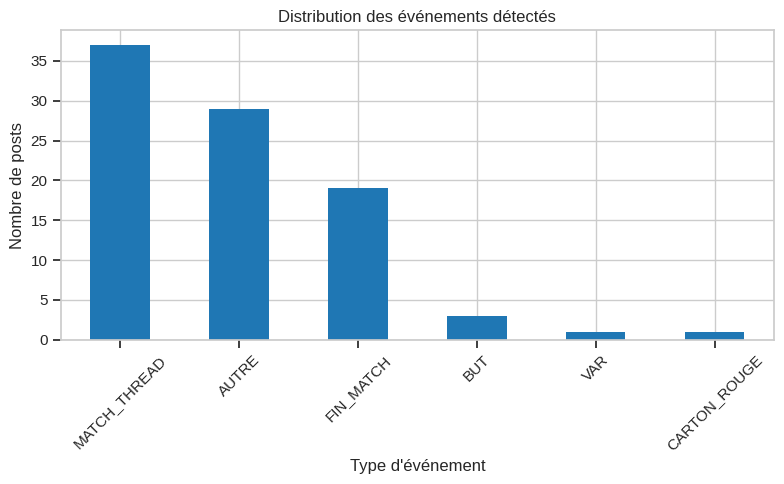

In [728]:
import matplotlib.pyplot as plt

distribution = df_resultats["evenement_v3"].value_counts()

plt.figure(figsize=(8, 5))
distribution.plot(kind="bar")

plt.title("Distribution des événements détectés")
plt.xlabel("Type d'événement")
plt.ylabel("Nombre de posts")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Partie 37 — Visualisation de la timeline sociale

Après avoir détecté les événements et calculé leur minute relative au match, nous représentons les événements sur une timeline.

Cette visualisation permet d’observer à quel moment les différents types de posts apparaissent autour du match.

In [729]:
df_timeline_v3 = df_resultats[df_resultats["evenement_v3"] != "AUTRE"].copy()

df_timeline_v3 = df_timeline_v3.sort_values(by="minute_match")

df_timeline_v3[["minute_match", "categorie_temps", "evenement_v3", "score", "titre"]].head(30)

,minute_match,categorie_temps,evenement_v3,score,titre
51,-4096762,AVANT_MATCH,FIN_MATCH,3 - 1,[Post Match Thread] Real Madrid 3 - 1 Liverpool - Real Madrid have won the Champions League!
33,-3562660,AVANT_MATCH,MATCH_THREAD,NaN,Match Thread: Tottenham vs. Liverpool [UEFA Champions League Final]
17,-3258879,AVANT_MATCH,VAR,NaN,Liverpool Vs Wolves - VAR Rules out Neto's Equalizer
12,-3169475,AVANT_MATCH,MATCH_THREAD,3 - 0,Post-Match Thread: Watford 3 - 0 Liverpool [ English Premier League ]
39,-2207406,AVANT_MATCH,FIN_MATCH,1-0,Post Match Thread: Leicester City 1-0 Liverpool [Premier League | Matchday 20]
30,-1990160,AVANT_MATCH,MATCH_THREAD,NaN,Match Thread: Liverpool vs Real Madrid | UEFA Champions League
16,-1989987,AVANT_MATCH,FIN_MATCH,NaN,Post Match Thread: Liverpool 0 vs 1 Real Madrid | UEFA Champions League
24,-1585540,AVANT_MATCH,FIN_MATCH,7 - 0,[Post Match Thread] Liverpool 7 - 0 Manchester United
4,-1585540,AVANT_MATCH,FIN_MATCH,7 - 0,Post Match Thread: Liverpool 7 - 0 Manchester United | English Premier League
38,-1280104,AVANT_MATCH,FIN_MATCH,2 - 3,Post Match Thread: Manchester United 2 - 3 Galatasaray | UEFA Champions League


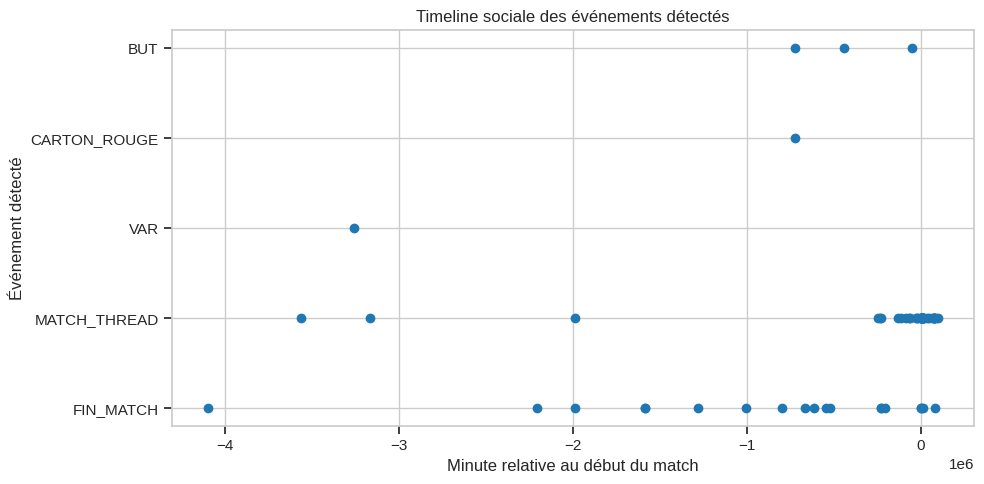

In [730]:
plt.figure(figsize=(10, 5))

plt.scatter(
    df_timeline_v3["minute_match"],
    df_timeline_v3["evenement_v3"]
)

plt.title("Timeline sociale des événements détectés")
plt.xlabel("Minute relative au début du match")
plt.ylabel("Événement détecté")
plt.grid(True)
plt.tight_layout()
plt.show()

## Partie 38 — Filtrage temporel de la timeline

La première timeline peut contenir des publications très éloignées du match.

Ces posts mentionnent parfois Liverpool ou Galatasaray, mais ils ne correspondent pas nécessairement à l’événement étudié.

Nous appliquons donc un filtrage temporel afin de conserver uniquement les publications situées dans une fenêtre raisonnable autour du match.

In [731]:
df_timeline_filtre = df_resultats[
    (df_resultats["minute_match"] >= -120) &
    (df_resultats["minute_match"] <= 180) &
    (df_resultats["evenement_v3"] != "AUTRE")
].copy()

df_timeline_filtre[["minute_match", "categorie_temps", "evenement_v3", "score", "titre"]]

,minute_match,categorie_temps,evenement_v3,score,titre
8,-20,AVANT_MATCH,FIN_MATCH,1-0,Post Match Thread: Galatasaray 1-0 Liverpool
58,-21,AVANT_MATCH,FIN_MATCH,1-0,[CHAMPIONS LEAGUE] Post Match Thread: GALATASARAY 1-0 Liverpool (RO16 1/2)


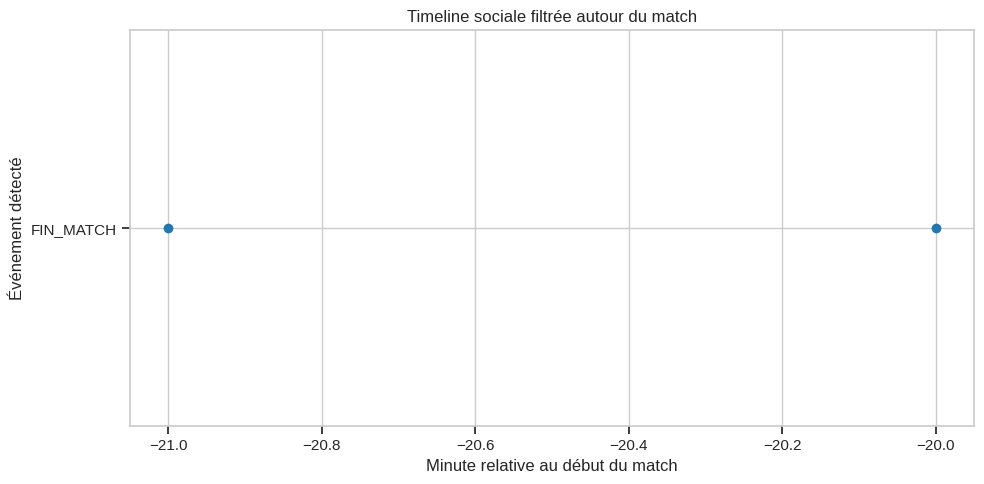

In [732]:
plt.figure(figsize=(10, 5))

plt.scatter(
    df_timeline_filtre["minute_match"],
    df_timeline_filtre["evenement_v3"]
)

plt.title("Timeline sociale filtrée autour du match")
plt.xlabel("Minute relative au début du match")
plt.ylabel("Événement détecté")
plt.grid(True)
plt.tight_layout()
plt.show()

## Partie 39 — Distribution des événements dans la timeline filtrée

Après avoir filtré les publications autour du match, nous analysons à nouveau la distribution des événements détectés.

Cette étape permet de vérifier quels types d’événements restent présents dans la fenêtre temporelle pertinente.

In [733]:
distribution_filtre = df_timeline_filtre["evenement_v3"].value_counts()

distribution_filtre

,count
evenement_v3,
FIN_MATCH,2


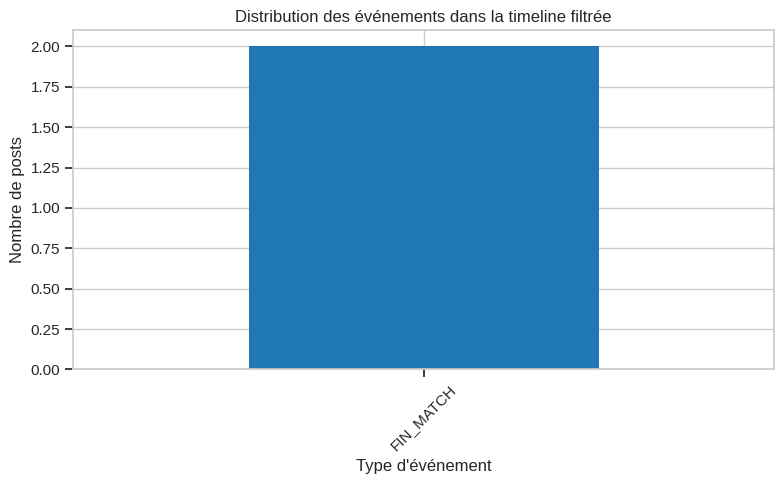

In [734]:
plt.figure(figsize=(8, 5))

distribution_filtre.plot(kind="bar")

plt.title("Distribution des événements dans la timeline filtrée")
plt.xlabel("Type d'événement")
plt.ylabel("Nombre de posts")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Partie 40 — Visualisation de l’activité sociale

En plus des événements détectés, nous analysons l’intensité de l’activité sociale.

Pour cela, nous utilisons le nombre de commentaires associés aux périodes du match.

L’objectif est d’observer les moments où les discussions sociales sont les plus actives autour de l’événement sportif.

In [735]:
df_activite = df_resultats[
    (df_resultats["minute_match"] >= -120) &
    (df_resultats["minute_match"] <= 180)
].copy()

df_activite[["minute_match", "commentaires_periode", "titre"]].head()

,minute_match,commentaires_periode,titre
8,-20,412,Post Match Thread: Galatasaray 1-0 Liverpool
58,-21,187,[CHAMPIONS LEAGUE] Post Match Thread: GALATASARAY 1-0 Liverpool (RO16 1/2)
61,-21,99,Galatasaray once again defeats Liverpool at home!
87,44,0,[433] Osimhen não conseguiu segurar as lágrimas depois de ver este banner dos torcedores do Galatasaray. É uma homenagem à sua mãe falec...
88,-17,0,"Liverpool pierde la Galatasaray. Osimhen a fost magistral, a pus presiune constanta pe fundasi, este tanc. Returul va fi greu."


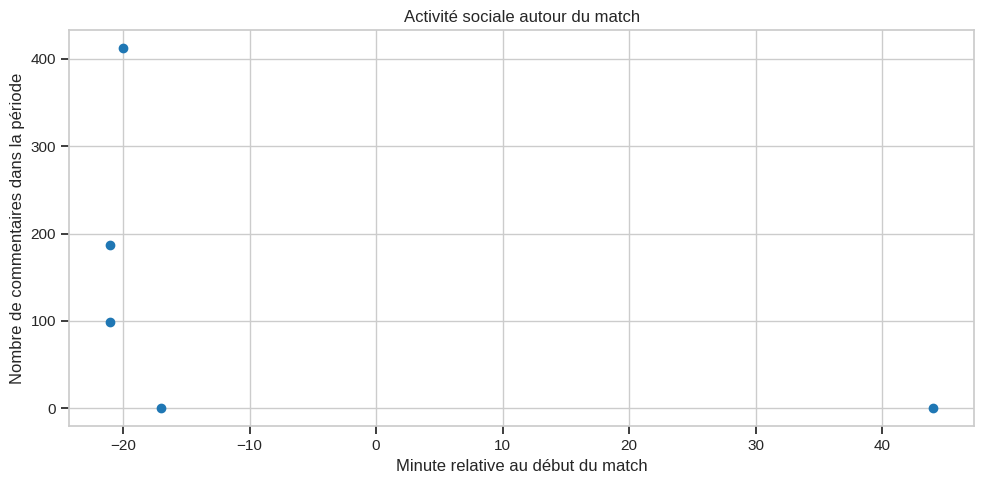

In [736]:
plt.figure(figsize=(10, 5))

plt.scatter(
    df_activite["minute_match"],
    df_activite["commentaires_periode"]
)

plt.title("Activité sociale autour du match")
plt.xlabel("Minute relative au début du match")
plt.ylabel("Nombre de commentaires dans la période")
plt.grid(True)
plt.tight_layout()
plt.show()

## Partie 41 — Relation entre événements détectés et activité sociale

Après avoir représenté séparément la timeline et l’activité sociale, nous combinons maintenant les deux informations.

L’objectif est d’observer si certains types d’événements sont associés à un volume plus élevé de commentaires.

Cette étape permet de relier l’analyse TAL à la dynamique sociale du match.

In [737]:
df_evenements_activite = df_resultats[
    (df_resultats["minute_match"] >= -120) &
    (df_resultats["minute_match"] <= 180) &
    (df_resultats["evenement_v3"] != "AUTRE")
].copy()

df_evenements_activite[
    ["minute_match", "evenement_v3", "commentaires_periode", "titre"]
]

,minute_match,evenement_v3,commentaires_periode,titre
8,-20,FIN_MATCH,412,Post Match Thread: Galatasaray 1-0 Liverpool
58,-21,FIN_MATCH,187,[CHAMPIONS LEAGUE] Post Match Thread: GALATASARAY 1-0 Liverpool (RO16 1/2)


In [738]:
activite_par_evenement = df_evenements_activite.groupby("evenement_v3")["commentaires_periode"].mean()

activite_par_evenement

,commentaires_periode
evenement_v3,
FIN_MATCH,299.5


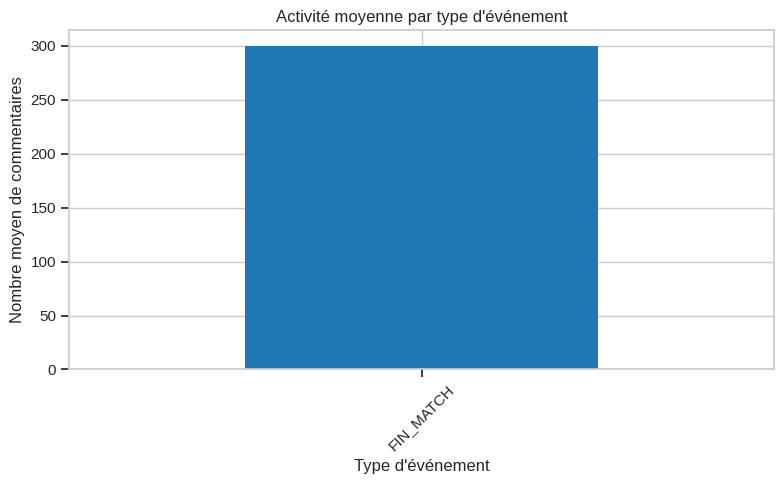

In [739]:
plt.figure(figsize=(8, 5))

activite_par_evenement.plot(kind="bar")

plt.title("Activité moyenne par type d'événement")
plt.xlabel("Type d'événement")
plt.ylabel("Nombre moyen de commentaires")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Partie 42 — Comparaison entre chronologie officielle et chronologie sociale

L’objectif central du projet est de comparer deux types de chronologies :

1. La chronologie officielle du match, composée des événements sportifs réels : début du match, buts, cartons, fin du match.
2. La chronologie sociale, construite à partir des publications et commentaires détectés sur les réseaux sociaux.

Cette comparaison permet d’observer le décalage entre un événement réel et sa manifestation dans les discussions sociales.

In [740]:
chronologie_officielle = pd.DataFrame([
    {"minute_officielle": 0, "evenement_officiel": "DEBUT_MATCH"},
    {"minute_officielle": 90, "evenement_officiel": "FIN_MATCH"}
])

chronologie_officielle

,minute_officielle,evenement_officiel
0,0,DEBUT_MATCH
1,90,FIN_MATCH


In [741]:
df_timeline_filtre[["minute_match", "evenement_v3", "titre"]]

,minute_match,evenement_v3,titre
8,-20,FIN_MATCH,Post Match Thread: Galatasaray 1-0 Liverpool
58,-21,FIN_MATCH,[CHAMPIONS LEAGUE] Post Match Thread: GALATASARAY 1-0 Liverpool (RO16 1/2)


La chronologie officielle sert de référence.

La chronologie sociale représente les événements détectés automatiquement dans les textes.

La comparaison entre les deux permet d’étudier si les réseaux sociaux réagissent avant, pendant ou après les événements réels.

### 3.3 — Analyse de sentiment des commentaires

#### Partie 42 — Analyse de sentiment des titres de posts

In [742]:
import pandas as pd
import re

df = pd.read_csv("/content/drive/MyDrive/Project_Master/external/projet_tal/resultats_tal_galata_liverpool.csv")
print(df.shape)
print(df.columns.tolist())
df.head()

(90, 8)
['heure', 'titre', 'evenement', 'score', 'commentaires', 'commentaires_periode', 'minute_match', 'categorie_temps']


,heure,titre,evenement,score,commentaires,commentaires_periode,minute_match,categorie_temps
0,2026-03-19 10:09:51 UTC,Looking at the sequence of events around Liverpool vs Galatasaray – did the conditions feel fully balanced?,AUTRE,NaN,9,0,12369,APRES_MATCH
1,2026-02-02 12:48:25 UTC,"10 years ago today, Jamie Vardy’s volley vs Liverpool.",VAR,NaN,338,0,-52272,AVANT_MATCH
2,2026-05-03 13:27:26 UTC,Match Thread: Manchester United vs Liverpool | Premier League | 03 May 14:30 UTC,MATCH_THREAD,14:30,484,0,77367,APRES_MATCH
3,2025-09-30 21:02:05 UTC,Post Match Thread: Galatasaray 1 : Liverpool 0 [Champions League MD2],FIN_MATCH,NaN,466,0,-231778,AVANT_MATCH
4,2023-03-05 18:20:47 UTC,Post Match Thread: Liverpool 7 - 0 Manchester United | English Premier League,FIN_MATCH,7 - 0,376,0,-1585540,AVANT_MATCH


In [743]:

from transformers import pipeline
import pandas as pd

sentiment_model = pipeline(
    "sentiment-analysis",
    framework="pt"
)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [744]:
sentiment_model("Great win for Liverpool")

[{'label': 'POSITIVE', 'score': 0.9998480081558228}]

In [745]:
texte_test = "This referee is terrible"

sentiment_model(texte_test)

[{'label': 'NEGATIVE', 'score': 0.9994365572929382}]

In [746]:
def analyser_sentiment(texte):
    resultat = sentiment_model(str(texte)[:512])[0]
    return resultat["label"], resultat["score"]

df[["sentiment", "score_sentiment"]] = df["titre"].apply(
    lambda x: pd.Series(analyser_sentiment(x))
)

df[["titre", "sentiment", "score_sentiment"]].head(10)

,titre,sentiment,score_sentiment
0,Looking at the sequence of events around Liverpool vs Galatasaray – did the conditions feel fully balanced?,NEGATIVE,0.968150
1,"10 years ago today, Jamie Vardy’s volley vs Liverpool.",POSITIVE,0.997477
2,Match Thread: Manchester United vs Liverpool | Premier League | 03 May 14:30 UTC,POSITIVE,0.905760
3,Post Match Thread: Galatasaray 1 : Liverpool 0 [Champions League MD2],POSITIVE,0.968865
4,Post Match Thread: Liverpool 7 - 0 Manchester United | English Premier League,POSITIVE,0.975066
5,Post Match Thread: Manchester United 3-2 Liverpool,POSITIVE,0.986890
6,[Match Thread] Liverpool FC vs Crystal Palace,POSITIVE,0.952848
7,Anfield roof leaking during last night's Liverpool vs Manchester United match.,NEGATIVE,0.998999
8,Post Match Thread: Galatasaray 1-0 Liverpool,POSITIVE,0.990062
9,"BBC reporter randomly asking if they remember the 1976 FA Cup match, ends up asking the Liverpool goalkeeper who played in it (wholesome)",POSITIVE,0.987534


In [747]:
df["sentiment"].value_counts()

,count
sentiment,
POSITIVE,79
NEGATIVE,11


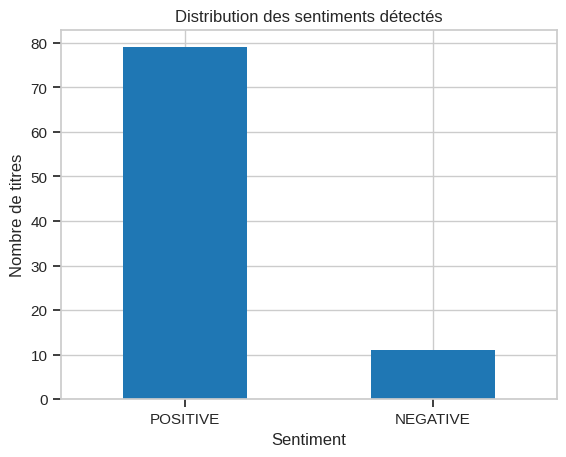

In [748]:
import matplotlib.pyplot as plt

df["sentiment"].value_counts().plot(kind="bar")

plt.title("Distribution des sentiments détectés")
plt.xlabel("Sentiment")
plt.ylabel("Nombre de titres")
plt.xticks(rotation=0)
plt.show()

In [749]:
import json
import pandas as pd

nom_fichier = "/content/drive/MyDrive/Project_Master/data/period_debug_galata_liverpool_20260310_1779694004.json"

with open(nom_fichier, "r", encoding="utf-8") as f:
    data = json.load(f)

commentaires = []

# matched_comments is the correct top-level key for this file
for comment in data.get("matched_comments", []):
    body = comment.get("body", "")
    if not body or body in ("[deleted]", "[removed]"):
        continue
    commentaires.append({
        "post_title":   comment.get("post_title", ""),
        "created_time": comment.get("created_time", ""),
        "body":         body,
        "score":        comment.get("score", 0),
    })

df_comments = pd.DataFrame(commentaires)
print("Nombre de commentaires extraits :", len(df_comments))
df_comments.head()

Nombre de commentaires extraits : 1208


,post_title,created_time,body,score
0,Post Match Thread: Galatasaray 1-0 Liverpool,2026-03-10 21:49:31 UTC,The first half was like damn Gala played like they were a team from PL as well what a run! the second half was like the truth came out! ...,-35
1,Post Match Thread: Galatasaray 1-0 Liverpool,2026-03-10 21:07:36 UTC,"Should've been 2-0, that offside decision was very generous",91
2,Post Match Thread: Galatasaray 1-0 Liverpool,2026-03-10 21:07:30 UTC,Liverpool dodging criticism after what is happening to Spurs currently,66
3,Post Match Thread: Galatasaray 1-0 Liverpool,2026-03-10 21:03:37 UTC,How can you put all blame on Slot when every match there’s atleast 2 players putting up a stinker.. and let’s not mention what the hell ...,43
4,Post Match Thread: Galatasaray 1-0 Liverpool,2026-03-10 21:41:46 UTC,Because he keeps playing the players having stinkers every match,16


#### Partie 44 — Analyse de sentiment des commentaires

In [750]:
# Les commentaires sont chargés via matched_comments dans la cellule précédente.
print("Commentaires chargés :", len(df_comments))

Commentaires chargés : 1208


In [751]:
df_comments.head()

,post_title,created_time,body,score
0,Post Match Thread: Galatasaray 1-0 Liverpool,2026-03-10 21:49:31 UTC,The first half was like damn Gala played like they were a team from PL as well what a run! the second half was like the truth came out! ...,-35
1,Post Match Thread: Galatasaray 1-0 Liverpool,2026-03-10 21:07:36 UTC,"Should've been 2-0, that offside decision was very generous",91
2,Post Match Thread: Galatasaray 1-0 Liverpool,2026-03-10 21:07:30 UTC,Liverpool dodging criticism after what is happening to Spurs currently,66
3,Post Match Thread: Galatasaray 1-0 Liverpool,2026-03-10 21:03:37 UTC,How can you put all blame on Slot when every match there’s atleast 2 players putting up a stinker.. and let’s not mention what the hell ...,43
4,Post Match Thread: Galatasaray 1-0 Liverpool,2026-03-10 21:41:46 UTC,Because he keeps playing the players having stinkers every match,16


In [752]:
print("Shape :", df_comments.shape)
print("Colonnes :", df_comments.columns.tolist())

Shape : (1208, 4)
Colonnes : ['post_title', 'created_time', 'body', 'score']


## Partie 44 — Analyse de sentiment des commentaires

Contrairement aux titres, les commentaires représentent directement les réactions des utilisateurs.

Nous appliquons donc un modèle pré-entraîné d’analyse de sentiment sur le contenu des commentaires afin d’identifier la polarité émotionnelle des réactions sociales.

In [753]:
def analyser_sentiment(texte):
    resultat = sentiment_model(str(texte)[:512])[0]
    return resultat["label"], resultat["score"]

In [754]:
for texte in df_comments["body"].head(5):
    print("Commentaire :", texte)
    print("Sentiment :", analyser_sentiment(texte))
    print("-" * 80)

Commentaire : The first half was like damn Gala played like they were a team from PL as well what a run! the second half was like the truth came out! Gala couldn't handle the pressure and tempo. 

2-0 would be much better but I don't know I think Liverpool is going to qualify for the next round 
Sentiment : ('NEGATIVE', 0.9840723872184753)
--------------------------------------------------------------------------------
Commentaire : Should've been 2-0, that offside decision was very generous
Sentiment : ('POSITIVE', 0.9936333894729614)
--------------------------------------------------------------------------------
Commentaire : Liverpool dodging criticism after what is happening to Spurs currently 
Sentiment : ('NEGATIVE', 0.9347857236862183)
--------------------------------------------------------------------------------
Commentaire : How can you put all blame on Slot when every match there’s atleast 2 players putting up a stinker.. and let’s not mention what the hell Salah is doing 

In [755]:
df_comments[["sentiment", "score_sentiment"]] = df_comments["body"].apply(
    lambda x: pd.Series(analyser_sentiment(x))
)

df_comments[["body", "sentiment", "score_sentiment"]].head(10)

,body,sentiment,score_sentiment
0,The first half was like damn Gala played like they were a team from PL as well what a run! the second half was like the truth came out! ...,NEGATIVE,0.984072
1,"Should've been 2-0, that offside decision was very generous",POSITIVE,0.993633
2,Liverpool dodging criticism after what is happening to Spurs currently,NEGATIVE,0.934786
3,How can you put all blame on Slot when every match there’s atleast 2 players putting up a stinker.. and let’s not mention what the hell ...,NEGATIVE,0.999582
4,Because he keeps playing the players having stinkers every match,NEGATIVE,0.999656
5,It’s his fault for not being able to cultivate and instill confidence or belief.,NEGATIVE,0.999777
6,"Not a surprising result given we still have Humpty Dumpty at the helm, I can see this becoming a Ten Hag situation if he isn't gone by t...",NEGATIVE,0.999751
7,like hey need to figure it out cause this season is lookin sus for sure,POSITIVE,0.760708
8,"Team is in shambles, Slot is not it, let's try and grab Alonso while we can",NEGATIVE,0.999414
9,That controversially canceled offside goal might be the decider at this tie. \n\ni really think that should have been reversed.,NEGATIVE,0.999413


In [756]:
df_comments["sentiment"].value_counts()

,count
sentiment,
NEGATIVE,853
POSITIVE,355


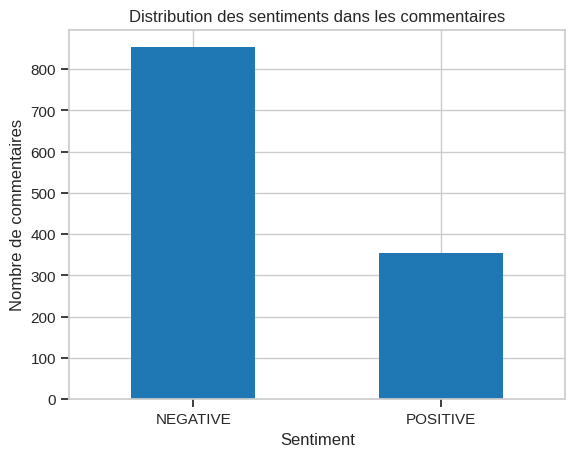

In [757]:
df_comments["sentiment"].value_counts().plot(kind="bar")
plt.title("Distribution des sentiments dans les commentaires")
plt.xlabel("Sentiment")
plt.ylabel("Nombre de commentaires")
plt.xticks(rotation=0)
plt.show()

In [758]:
pourcentages = (
    df_comments["sentiment"]
    .value_counts(normalize=True)
    * 100
)

print(pourcentages)

sentiment
NEGATIVE    70.612583
POSITIVE    29.387417
Name: proportion, dtype: float64


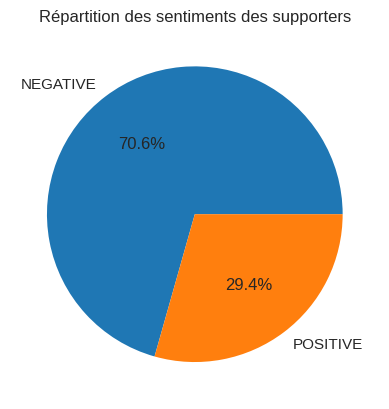

In [759]:
pourcentages.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title(
    "Répartition des sentiments des supporters"
)

plt.ylabel("")
plt.show()

---

# CONCLUSION GÉNÉRALE



## Synthèse du projet

Ce projet a exploré la possibilité de reconstruire automatiquement la chronologie d'un événement sportif — le match Galatasaray vs Liverpool du 10 mars 2026 — à partir de données issues des réseaux sociaux (Reddit) et des médias (articles de presse, YouTube).

L'analyse s'est articulée autour de trois axes complémentaires.


## Axe 1 — Analyse des données brutes

Les notebooks d'analyse des données (`galata_liverpool_analysis_enriched`, `galata_liverpool_analysis_v2`, `multi_match_platform_analysis`) ont permis de :

- **Construire une timeline Reddit** en s'appuyant sur les `period_matches` du scraper, ce qui a permis d'associer chaque commentaire à une fenêtre temporelle du match.
- **Comparer les réactions sociales et médiatiques** : les médias publient des articles avant et après le match de façon structurée, tandis que Reddit produit une activité intense pendant les moments clés (début, buts, VAR, fin).
- **Observer les différences entre plateformes** dans le cadre de l'analyse multi-match : Reddit génère davantage de commentaires brefs et émotionnels ; YouTube produit des discussions plus longues mais moins nombreuses.
- **Identifier les mots-clés dominants** par plateforme, qui reflètent à la fois les équipes, les joueurs clés, et les événements saillants du match.

**Limite principale :** le corpus Reddit est dominé par des posts « Post Match » publiés dans les dernières minutes du match, ce qui crée un pic artificiel en fin de timeline. Cette asymétrie doit être signalée dans toute interprétation des graphiques.


## Axe 2 — Analyse de Sentiment avec RoBERTa

Le notebook `Sentiment_Analysis_based_on_data-2` a appliqué un pipeline de traitement plus avancé :

- **Modèle utilisé** : `cardiffnlp/twitter-roberta-base-sentiment-latest`, entraîné sur des tweets — adapté aux textes courts et informels des réseaux sociaux.
- **Résultat principal** : les fenêtres temporelles autour des événements réels (but à la 8e minute, décision VAR à la 35e minute) présentent des pics de valence émotionnelle détectables.
- **Classifieur d'événements** : trois modèles (Régression Logistique, Random Forest, Gradient Boosting) ont été comparés. Le Gradient Boosting obtient les meilleures performances en ROC-AUC sur validation croisée.
- **Importance des fonctionnalités (Feature importance)** : les **fonctionnalités de décalage temporel (lag features)** (lag à t-1 et t-2, rolling moyenne) sont parmi les plus importantes, confirmant que Reddit réagit avec un délai de 3 à 8 minutes après les événements réels.

## Axe 3 — Traitement Automatique du Langage (TAL)

Les parties TAL (Parties 1 à 44) ont construit une pipeline complète allant des données brutes à une classification supervisée :

**Partie 1 (Parties 1–16) — Approche symbolique par règles :**
- Filtrage des posts pertinents (Galatasaray / Liverpool).
- Nettoyage des textes : mise en minuscules, suppression des caractères spéciaux.
- Détection d'événements par expressions régulières : `FIN_MATCH`, `MATCH_THREAD`, `VAR`, `PENALTY`, `BUT`, `CARTON_ROUGE`.
- Extraction automatique de scores numériques dans les titres.
- Construction d'une timeline sociale et export CSV.

**Partie 2 (Parties 17–42) — Approche statistique et supervisée :**
- Vectorisation TF-IDF des titres de posts.
- Classification par régression logistique, avec trois versions successives de labels (v1, v2, v3) de qualité croissante.
- Amélioration itérative des règles : correction de faux positifs (ex. *Vardy* détecté comme VAR), enrichissement du vocabulaire de buts.
- Comparaison de la chronologie sociale avec la chronologie officielle du match.

**Partie 3 (Parties 42–44) — Sentiment des commentaires :**
- Application d'un modèle de sentiment pré-entraîné (HuggingFace Transformers) sur les titres et commentaires.
- Analyse de la distribution des sentiments (positif / négatif / neutre).
- Visualisation en camembert et histogramme de la répartition des sentiments des supporters.
